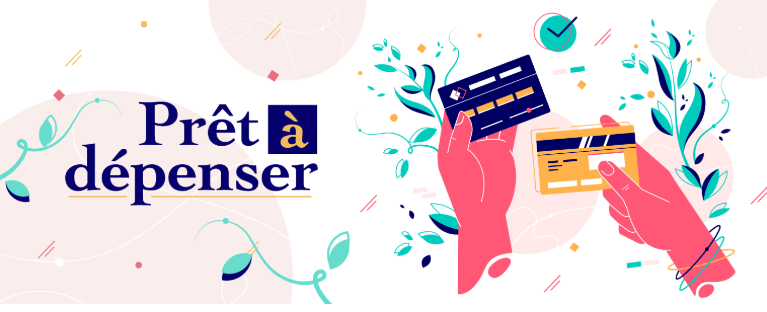

In [2]:
# %load_ext pycodestyle_magic
# %pycodestyle_on
# %pycodestyle_off

In [2]:
# utilities
import sys
import datetime

# data processing & cleaning
import pandas as pd
import numpy as np
import missingno as msno

# data viz
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from matplotlib.ticker import StrMethodFormatter
from matplotlib.ticker import FormatStrFormatter
# from jupyter_datatables import init_datatables_mode

# maths & stats
import random
import scipy.stats as st
from scipy.stats import chi2_contingency, pointbiserialr
from sklearn.feature_selection import mutual_info_classif

# custom user functions
from functions import *

# serialization
import pickle

# set dataframe display options
pd.set_option('max_colwidth', None)
pd.set_option('display.max_columns', None)

# silence warnings after checking
import warnings
pd.set_option('future.no_silent_downcasting', False)
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

# data pre-processing
from sklearn.model_selection import train_test_split
from sklearn.experimental import enable_iterative_imputer 
from sklearn.impute import IterativeImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer, OneHotEncoder

# configure transformers to output pandas DataFrames
from sklearn import set_config
set_config(transform_output="pandas")

# extract colors from logo for ppt slideshow
light_pink = findColor('light_pink.png')
bright_pink = findColor('bright_pink.png')
# navy = findColor('navy.png')
sand = findColor('sand.png')
leaf = findColor('leaf.png')
print("light_pink hex :", light_pink)
print("bright_pink hex :", bright_pink)
print("navy hex : #242164")
print("sand hex :", sand)
print("leaf hex :", leaf)

light_pink hex : #fbf0ef
bright_pink hex : #f05876
navy hex : #242164
sand hex : #f1bd5f
leaf hex : #2fbeb5


In [4]:
# initialise random state for all models and transformers
rs_list = [8, 13, 42]
rs = rs_list[random.randrange(len(rs_list))]
print("Random state =", rs)

Random state = 8


# 1 - Data prep

## 1.1 - Training set

### 1.1.1 - Import data & check for NaNs

In [4]:
train_data = pd.read_csv('train_data_raw.csv',  sep=',', encoding='utf-8')
print(train_data.shape)
train_data.sample(5)

(307511, 69)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,FLAG_OWN_CAR,FLAG_OWN_REALTY,AMT_CREDIT,REGION_POPULATION_RELATIVE,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_EMAIL,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,DISPOSABLE_INCOME,DISPOSABLE_INCOME_per_capita,INCOME_TYPE,YEAR_BIRTH,YEARS_EMPLOYED_AS_ADULT_%,PHONE_PROVIDED,PHONE_REACHABLE,ADDRESS_MISMATCH,CREDIT_RATING,NB_APPLICATION_DOCUMENTS_%,REQUESTS_ABOUT_CLIENT_1Y,EMPLOYMENT_SECTOR,b_AMT_CREDIT_MAX_OVERDUE_max,b_AMT_CREDIT_SUM_OVERDUE_mean,pcb_CNT_INSTALMENT_FUTURE_max,ccb_AMT_BALANCE_mean,ccb_AMT_CREDIT_LIMIT_ACTUAL_mean,ccb_AMT_DRAWINGS_TOTAL_mean,ccb_AMT_TOTAL_RECEIVABLE_mean,ccb_TOTAL_INSTALMENTS_max,ccb_CNT_DRAWINGS_TOTAL_mean,ccb_CARD_OVERDRAWN_sum,ccb_CARD_OVERDRAWN_%_mean,ip_PMT_DELAY_mean,ip_EARLY_PMT_mean,ip_AMT_OVERPAID_%_mean,ip_AMT_UNDERPAID_%_mean,pa_AMT_APPLICATION_mean,pa_RATE_DOWN_PAYMENT_mean,pa_NFLAG_INSURED_ON_APPROVAL_sum,pa_BANK_DECLINED_sum,pa_REMAINING_CREDIT_DURATION_Y_mean,pa_CREDIT_SECURITY_sum,TOTAL_APPROVED_CREDITS,TOTAL_PAYMENT_DELAYS_DAYS,TOTAL_ACTIVE_CAR_LOANS,TOTAL_ACTIVE_OTHER_LOANS,TOTAL_ACTIVE_CONSUMER_LOANS,TOTAL_ACTIVE_MICRO_LOANS,TOTAL_ACTIVE_MORTGAGES,TOTAL_ACTIVE_CREDIT_CARDS,DEBT_RENEGOCIATIONS,CLIENT_BAD_CREDIT_HISTORY,CLIENT_FRAUD_FLAG,CLIENT_WITHDRAWN_APPLICATIONS,DOWN_PAYMENT_CURR_%,DEBT_RATE_INC_CURR_%,IS_MALE,WHITE_COLLAR,UPPER_EDUCATION,IS_MARRIED,LIVES_INDEPENDENTLY
60188,169791,0,Cash loans,1,1,225000.0,0.018209,-2019.0,-3337,0,3,3,4.0,2.0,4.0,1.0,-1592.0,141367.5,141367.50,commission,29.241096,-0.488364,1.0,1.0,NaN,0.315797,0.05,7.0,secondary,6174.450,0.0,48.0,47846.091522,135000.0,39723.795,46967.204348,12.0,3.347826,4.0,0.449206,0.171875,8.109375,0.0,0.031250,71551.35,0.139711,0.0,0.0,16.054685,2.0,21.0,NaN,0.0,8.0,2.0,0.0,0.0,2.0,8.0,0.0,10.0,5.0,0.0000,132.854720,1.0,NaN,1.0,0.0,1.0
240212,378203,0,Revolving loans,0,1,202500.0,0.006233,-11039.0,-3766,0,2,2,2.0,0.0,2.0,0.0,-411.0,102375.0,51187.50,benefits,56.438356,28.236799,1.0,1.0,NaN,NaN,0.00,0.0,other,NaN,0.0,24.0,0.000000,0.0,0.000,0.000000,0.0,0.000000,0.0,0.000000,0.642857,12.642857,0.0,0.071429,134491.50,0.000000,0.0,0.0,18.996860,1.0,3.0,NaN,0.0,0.0,1.0,0.0,0.0,NaN,NaN,0.0,1.0,0.0,0.0000,10.886970,0.0,NaN,0.0,1.0,1.0
118099,236945,0,Cash loans,1,1,592560.0,0.004849,-2147.0,-2652,0,2,2,0.0,0.0,0.0,0.0,0.0,729063.0,364531.50,commission,52.328767,-0.226672,1.0,1.0,1.0,NaN,0.05,2.0,tertiary,0.000,0.0,18.0,0.000000,0.0,0.000,0.000000,0.0,0.000000,0.0,0.000000,0.500000,6.562500,0.0,0.093750,990000.00,NaN,2.0,0.0,10.905027,0.0,10.0,NaN,0.0,2.0,3.0,0.0,0.0,NaN,NaN,0.0,2.0,0.0,-0.3168,51.849191,1.0,1.0,1.0,1.0,1.0
62264,172213,0,Cash loans,0,1,450000.0,0.026392,-12833.0,-997,0,2,2,2.0,2.0,2.0,1.0,-625.0,41890.5,41890.50,fixed_salary,47.895890,-0.238769,1.0,1.0,NaN,NaN,0.05,2.0,tertiary,11384.955,0.0,12.0,0.000000,0.0,0.000,0.000000,0.0,0.000000,0.0,0.000000,0.384615,9.615385,0.0,0.076923,419557.50,0.000000,0.0,2.0,26.371001,0.0,9.0,NaN,0.0,2.0,2.0,0.0,0.0,NaN,NaN,3.0,1.0,0.0,0.0000,49.614674,0.0,0.0,0.0,0.0,1.0
53408,161855,0,Cash loans,1,1,728460.0,0.009175,-761.0,-4891,0,2,2,2.0,0.0,2.0,0.0,0.0,144814.5,72407.25,commission,42.912329,-0.066017,1.0,1.0,NaN,NaN,0.05,1.0,secondary,0.000,0.0,12.0,0.000000,0.0,0.000,0.000000,0.0,0.000000,0.0,0.000000,43.413793,4.620690,0.0,0.310345,156096.00,0.000000,0.0,0.0,11.098775,1.0,4.0,NaN,0.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,1.0,0.0,-0.0792,16.000323,1.0,0.0,0.0,1.0,1.0


<Axes: >

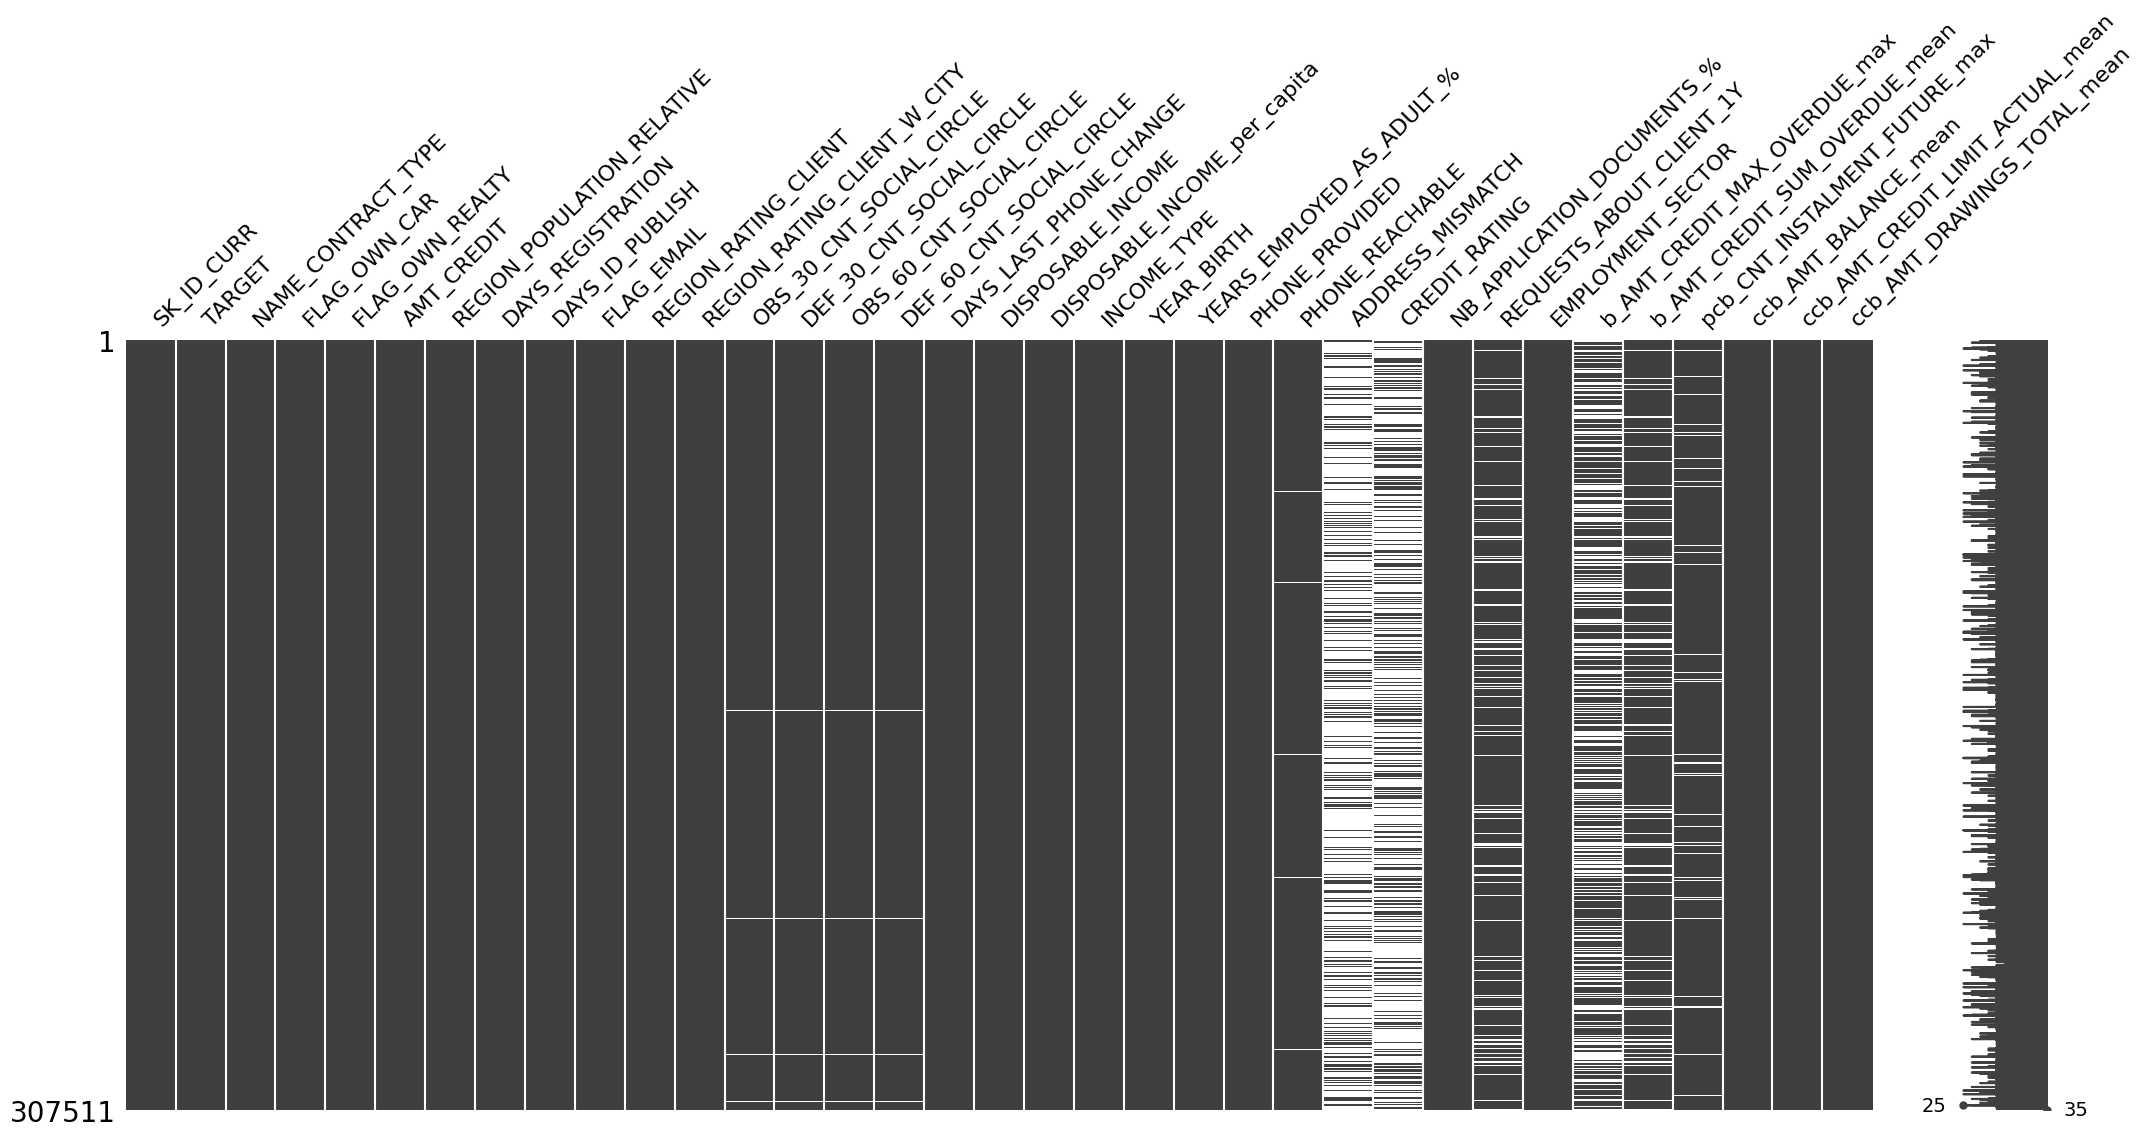

In [5]:
msno.matrix(train_data.iloc[:,:35])

<Axes: >

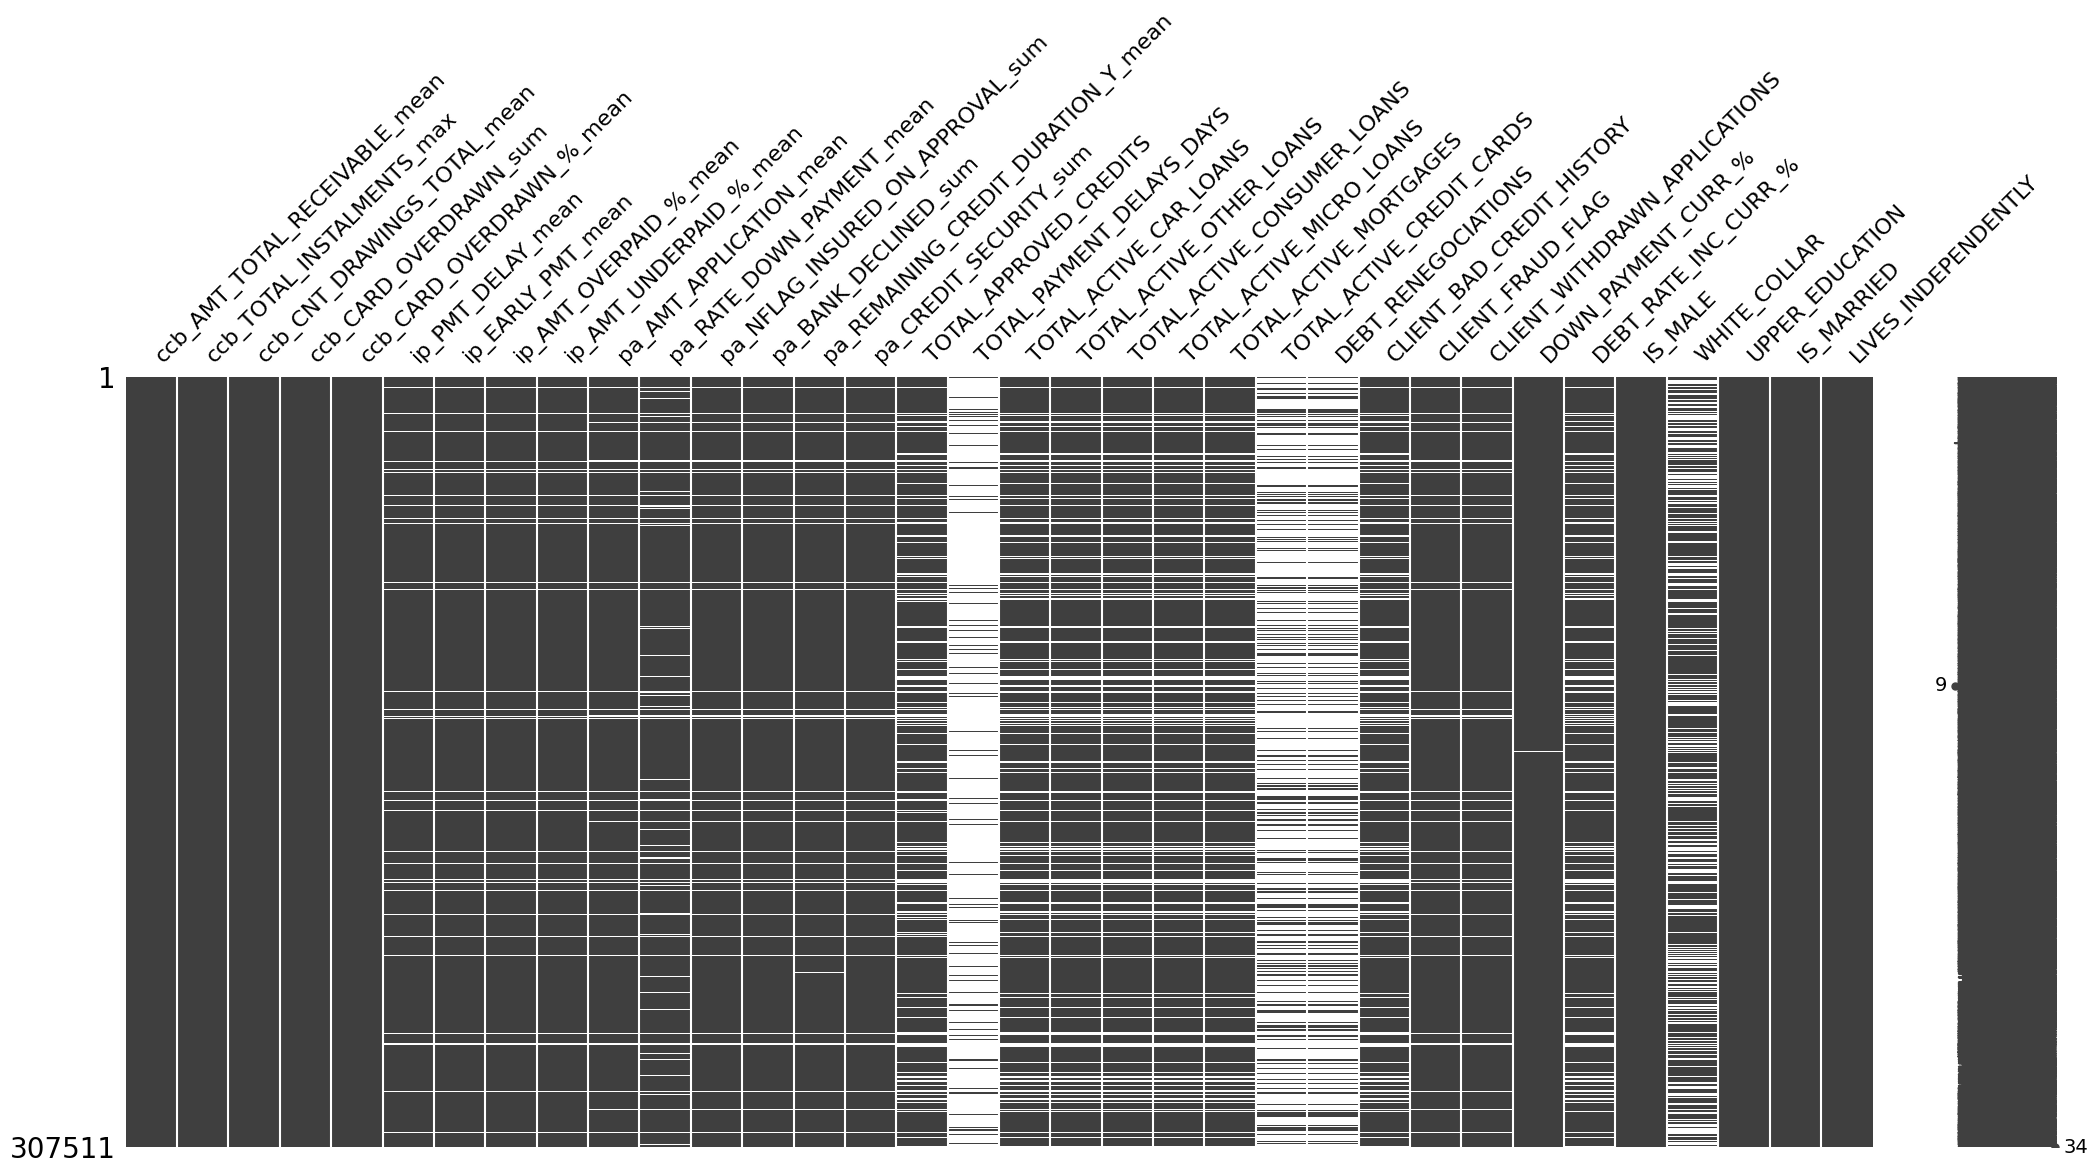

In [6]:
msno.matrix(train_data.iloc[:,35:70])

In [7]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 69 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   SK_ID_CURR                           307511 non-null  int64  
 1   TARGET                               307511 non-null  int64  
 2   NAME_CONTRACT_TYPE                   307511 non-null  object 
 3   FLAG_OWN_CAR                         307511 non-null  int64  
 4   FLAG_OWN_REALTY                      307511 non-null  int64  
 5   AMT_CREDIT                           307511 non-null  float64
 6   REGION_POPULATION_RELATIVE           307511 non-null  float64
 7   DAYS_REGISTRATION                    307511 non-null  float64
 8   DAYS_ID_PUBLISH                      307511 non-null  int64  
 9   FLAG_EMAIL                           307511 non-null  int64  
 10  REGION_RATING_CLIENT                 307511 non-null  int64  
 11  REGION_RATING

In [8]:
cat_cols = ['NAME_CONTRACT_TYPE',  'INCOME_TYPE', 'EMPLOYMENT_SECTOR']
train_data['SK_ID_CURR'] = train_data['SK_ID_CURR'].astype('string')
train_data[cat_cols] = train_data[cat_cols].astype('category')

### 1.1.2 - Outliers

In [9]:
# Replace inf and -inf with NaN
train_data.replace([np.inf, -np.inf], np.nan, inplace=True)

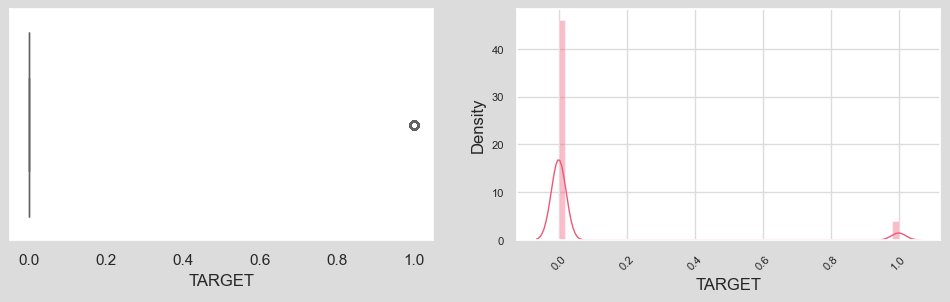

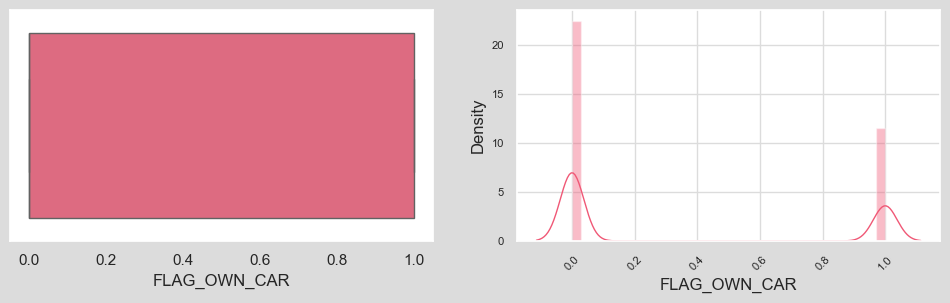

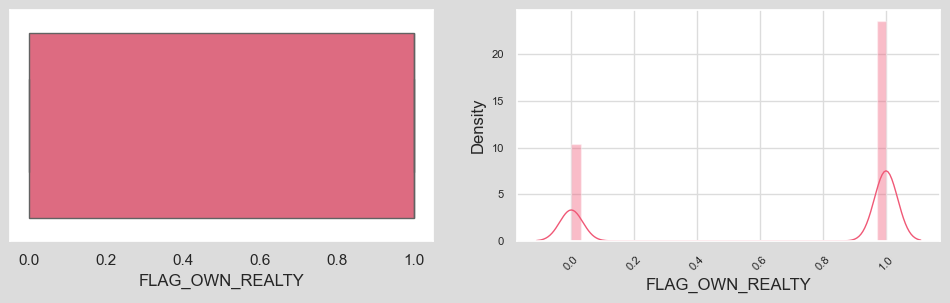

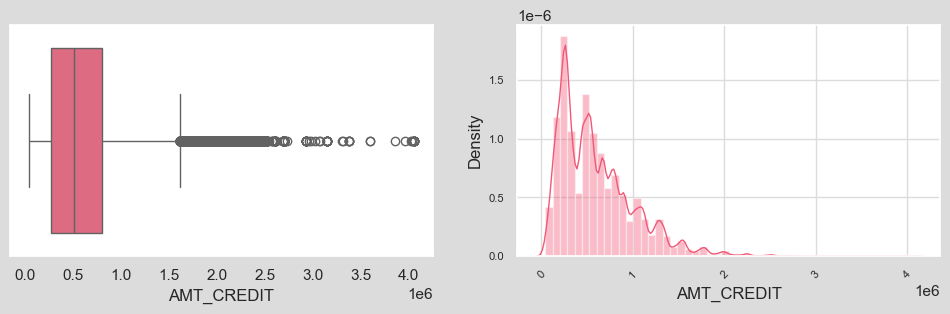

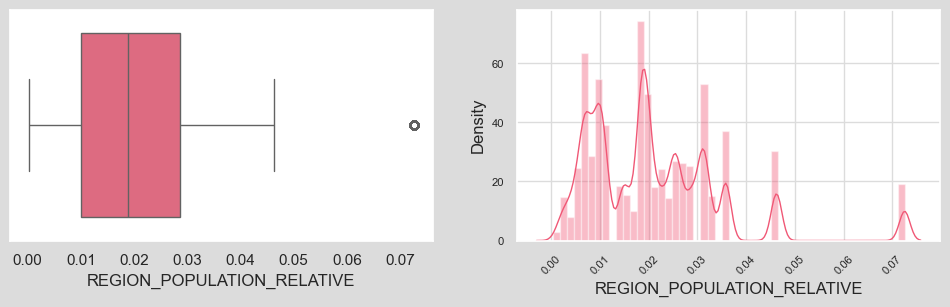

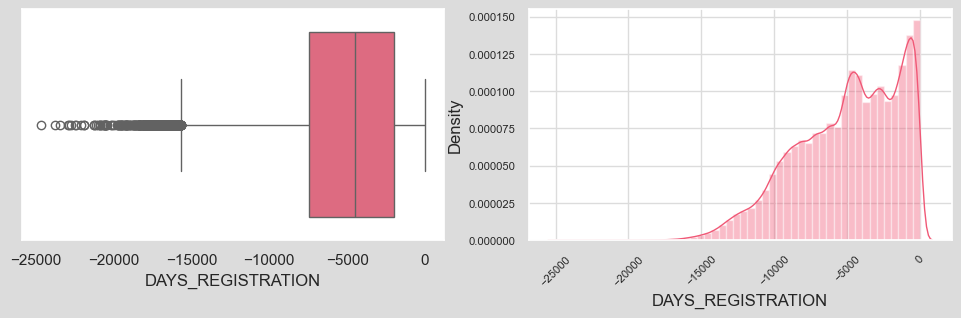

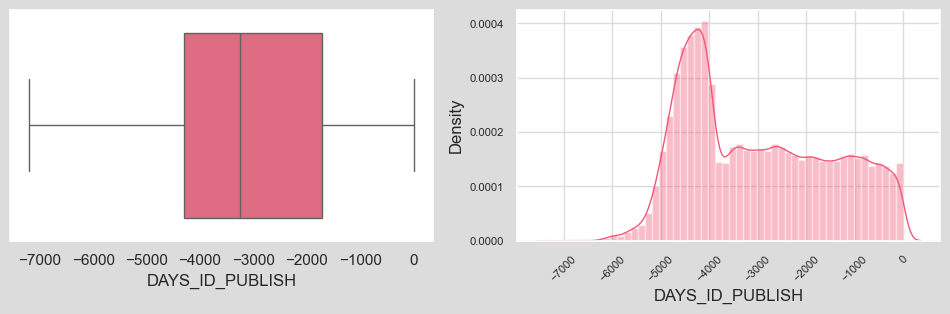

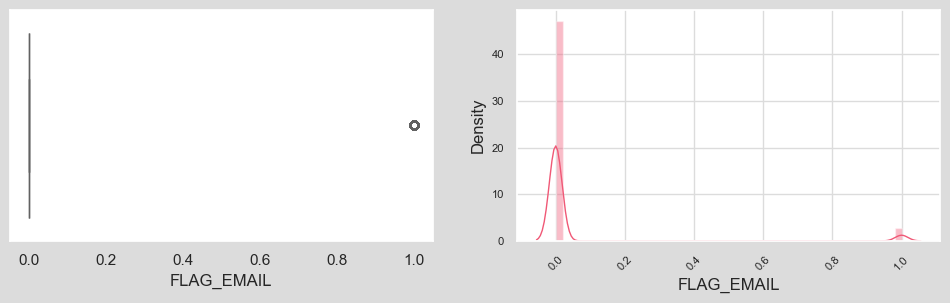

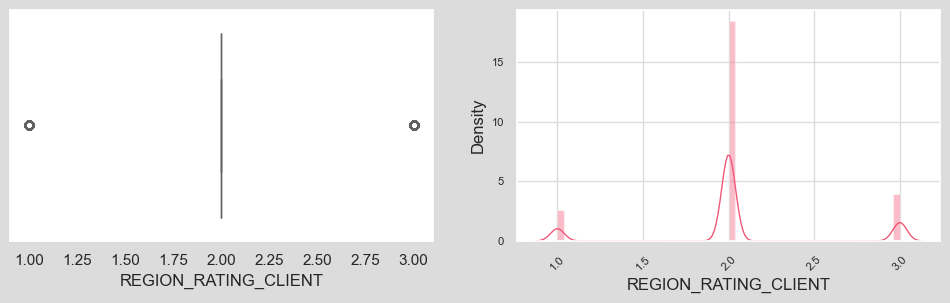

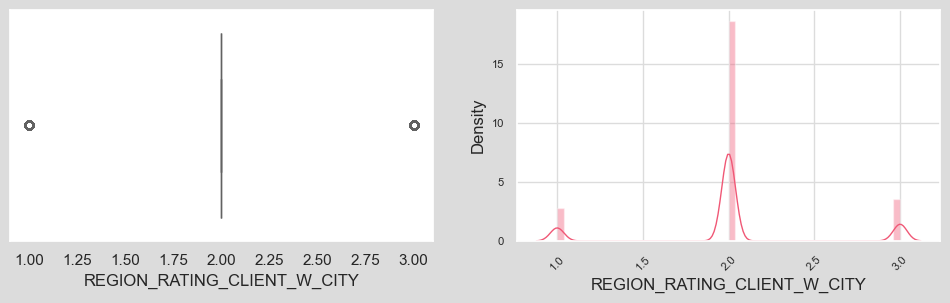

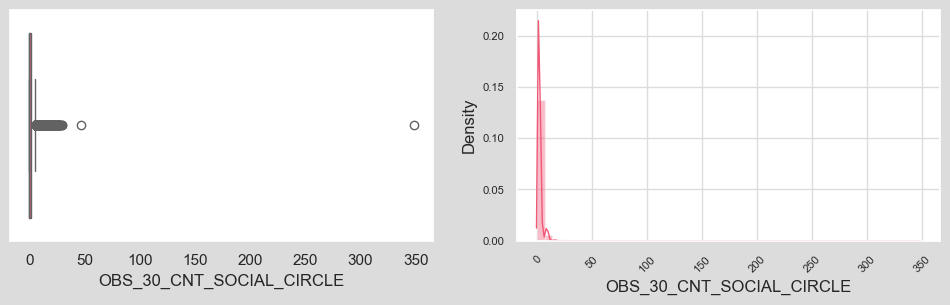

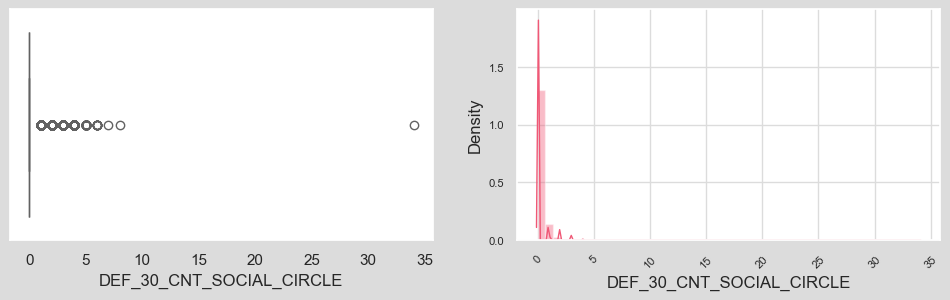

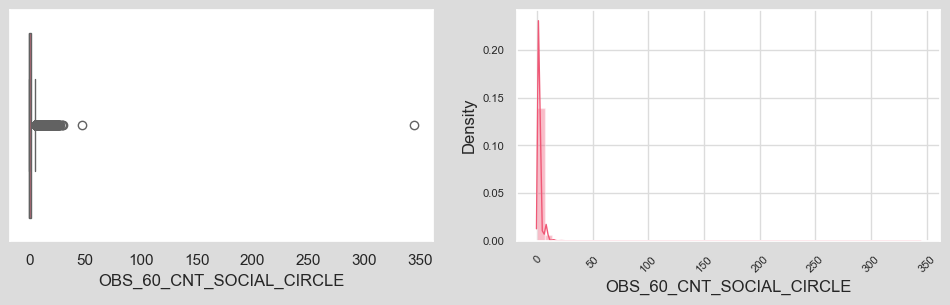

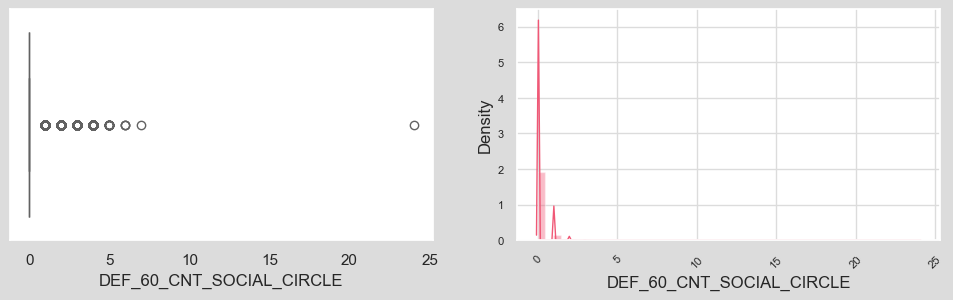

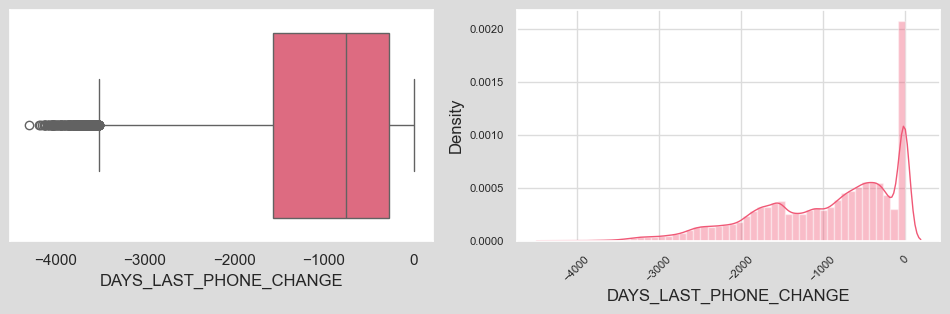

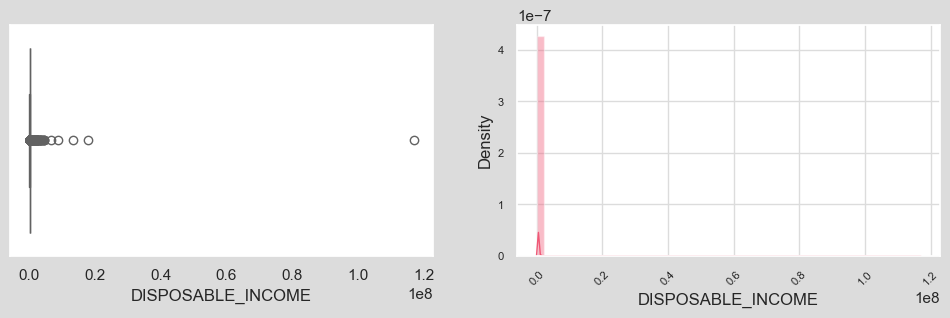

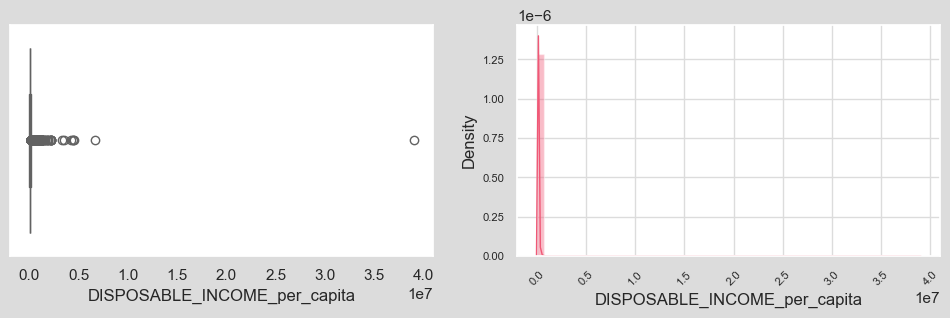

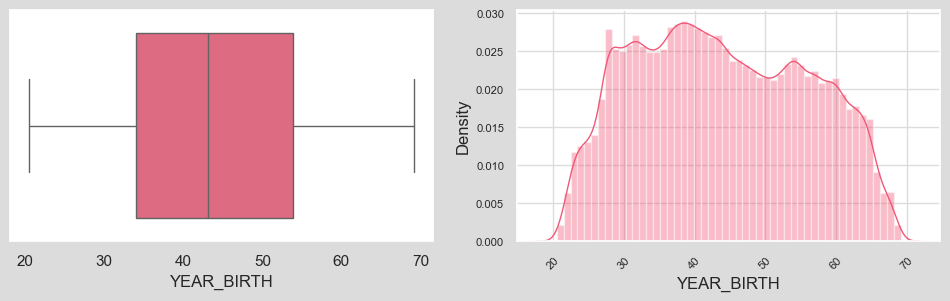

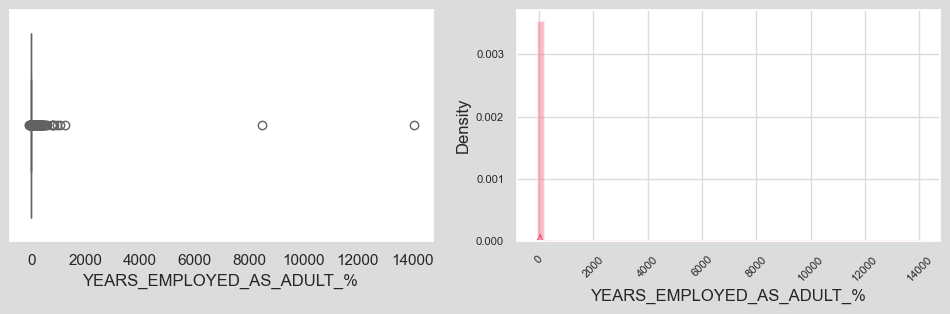

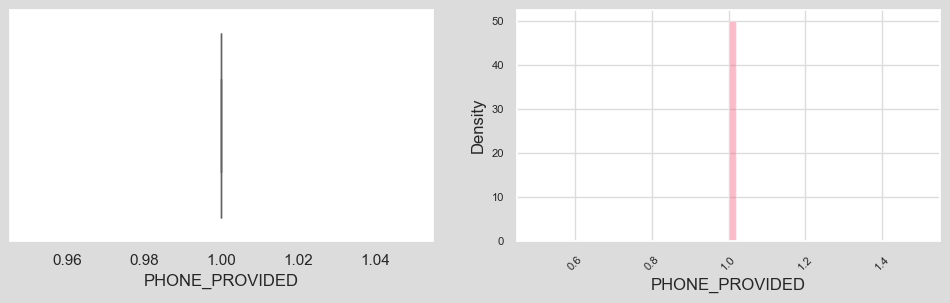

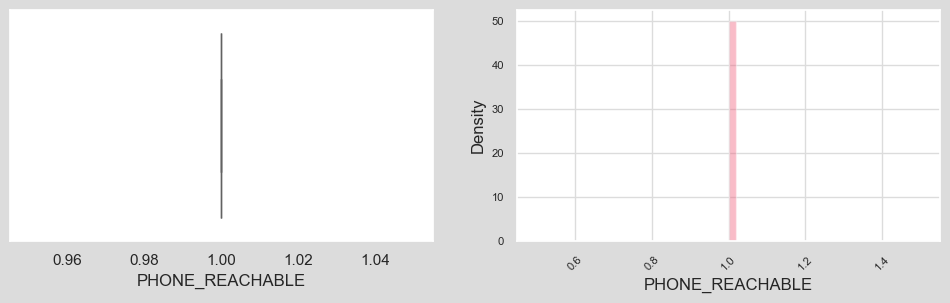

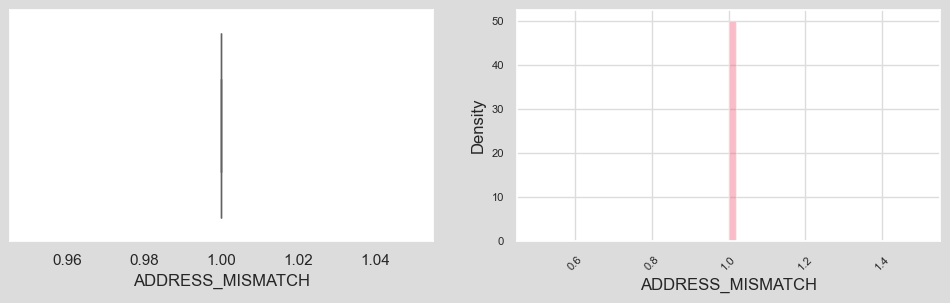

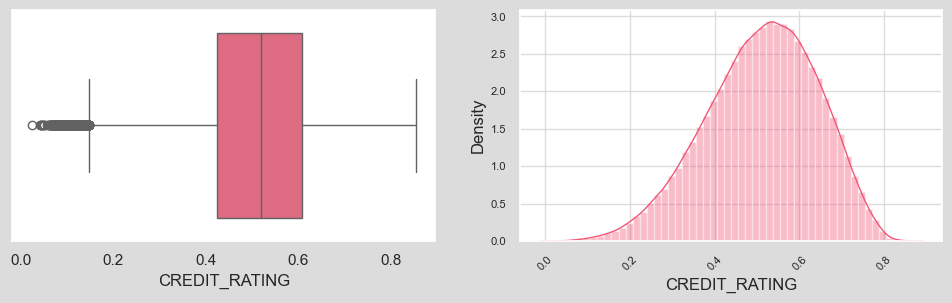

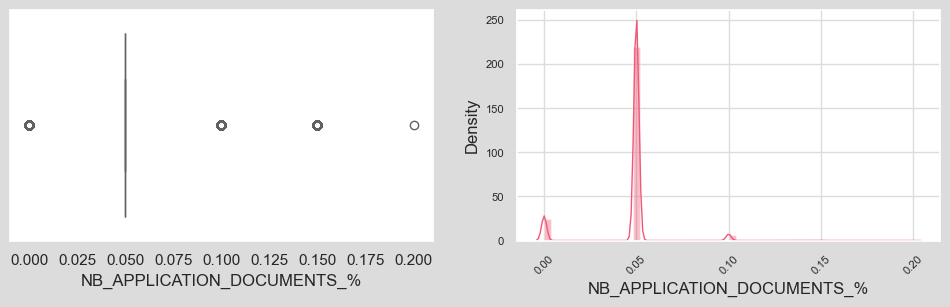

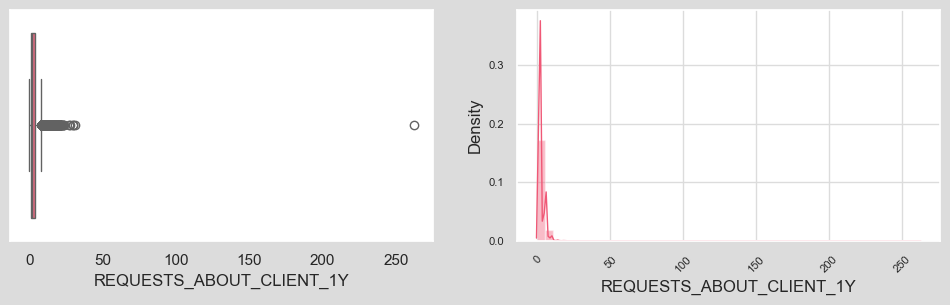

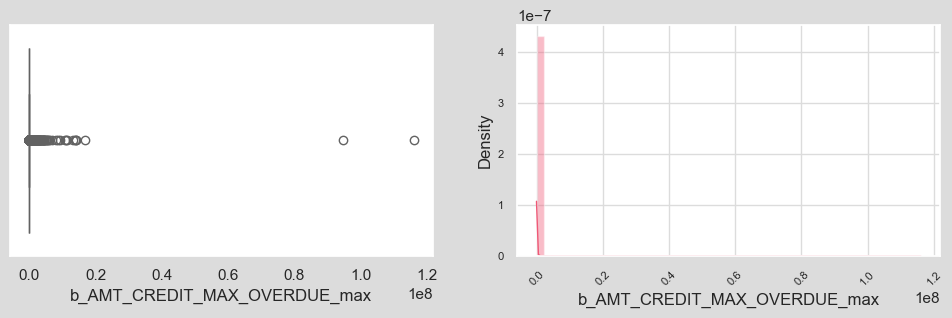

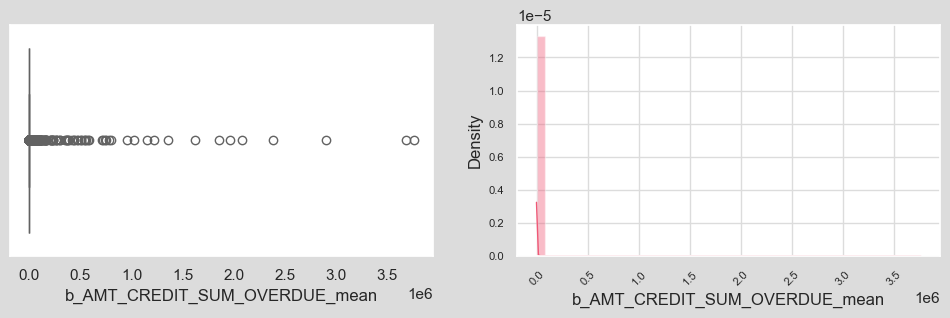

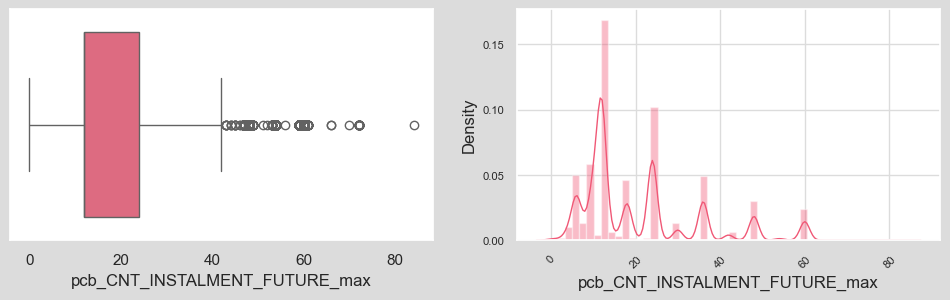

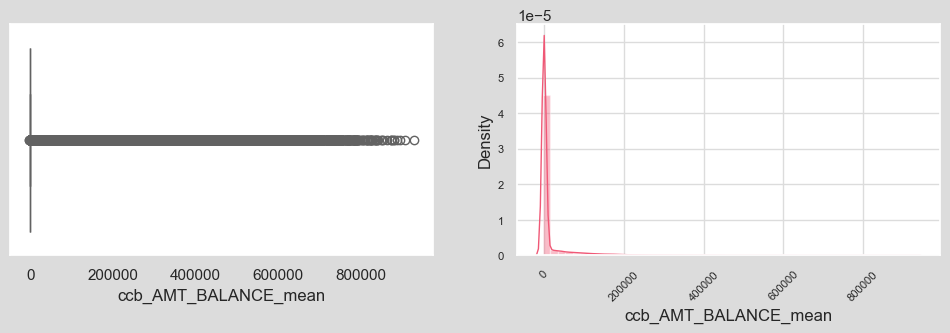

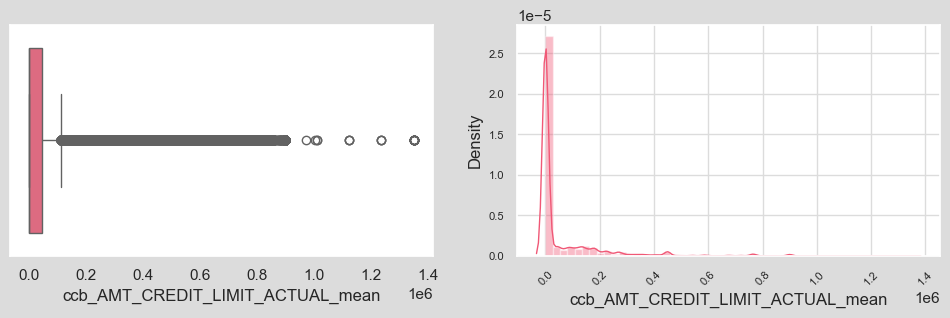

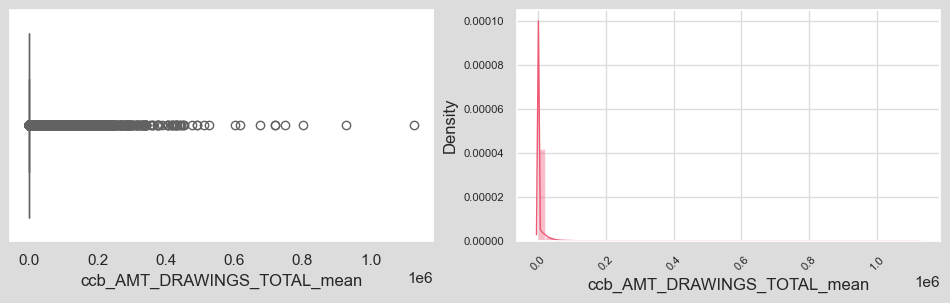

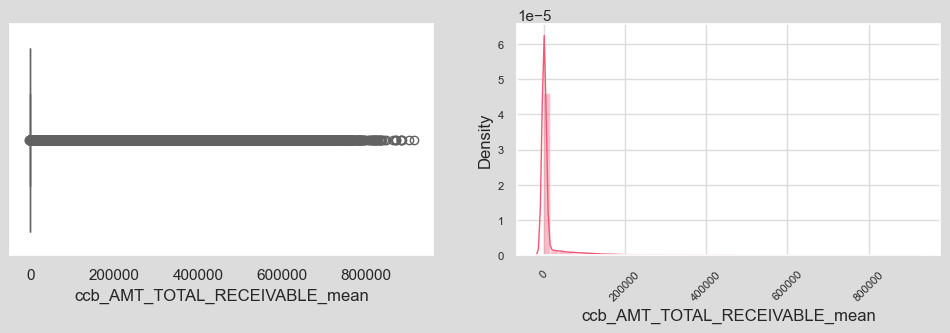

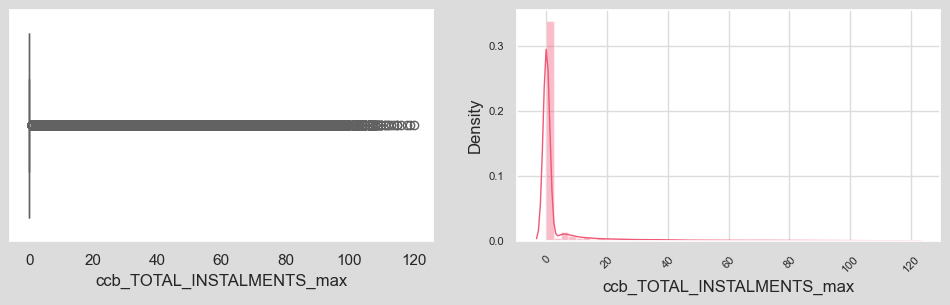

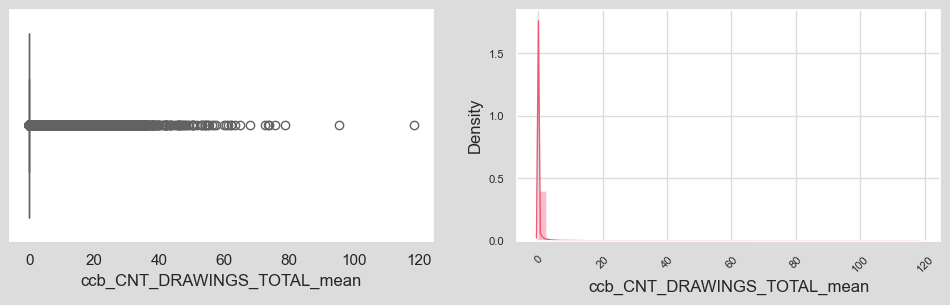

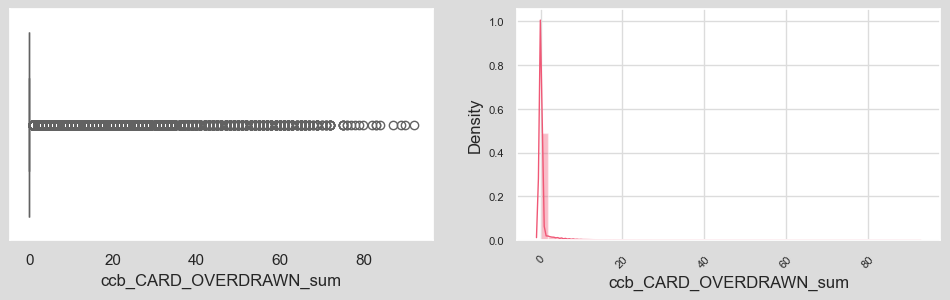

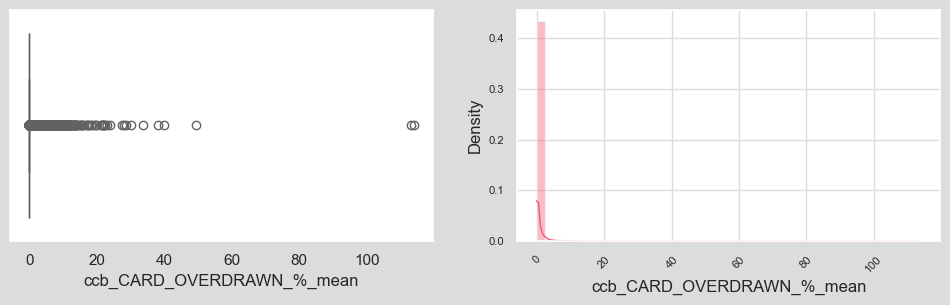

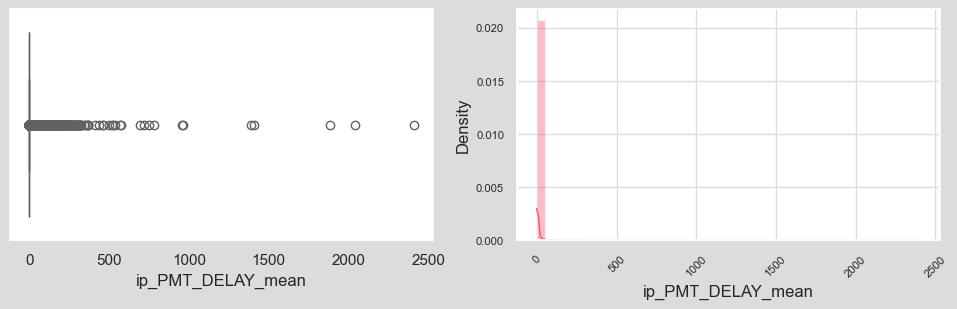

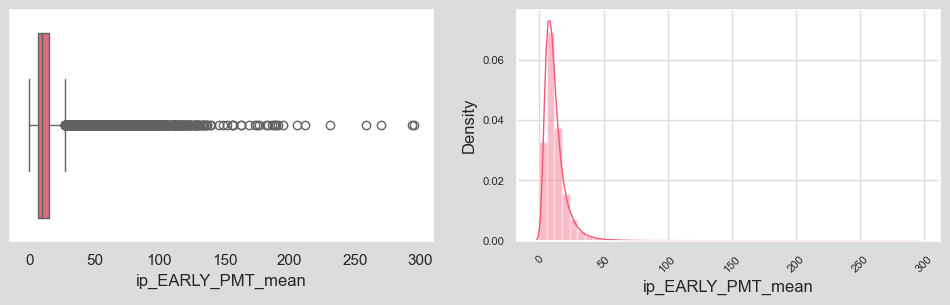

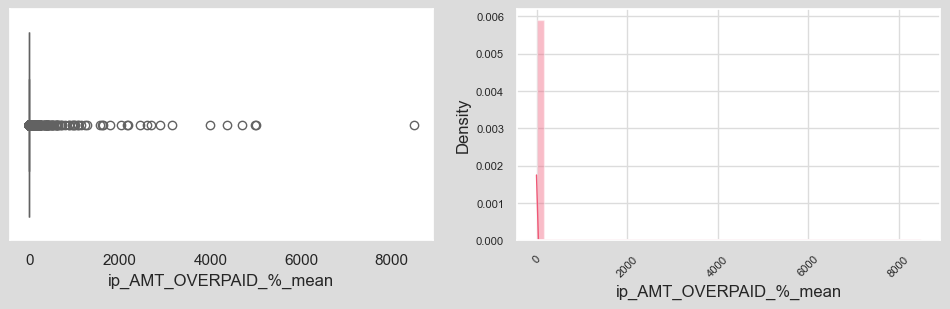

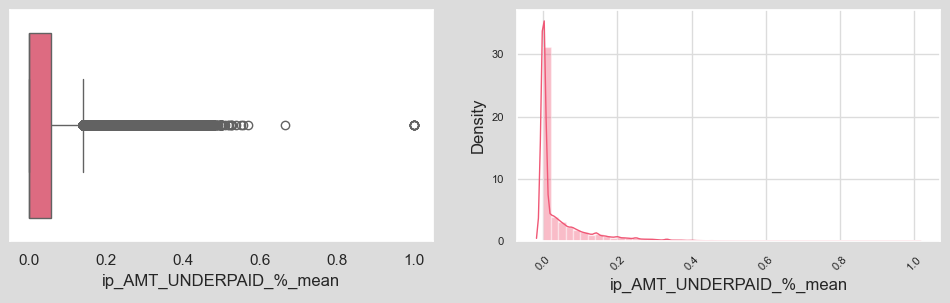

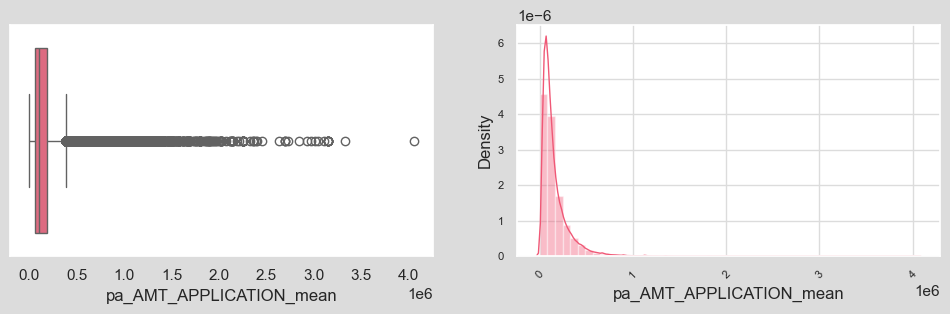

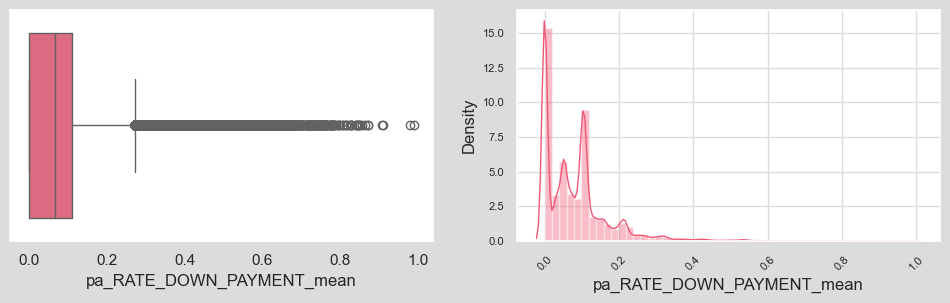

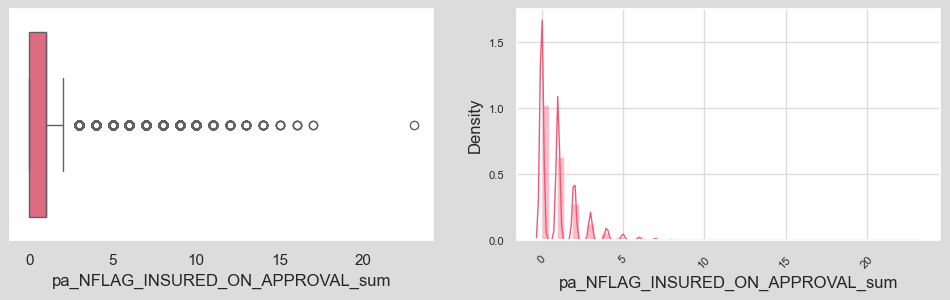

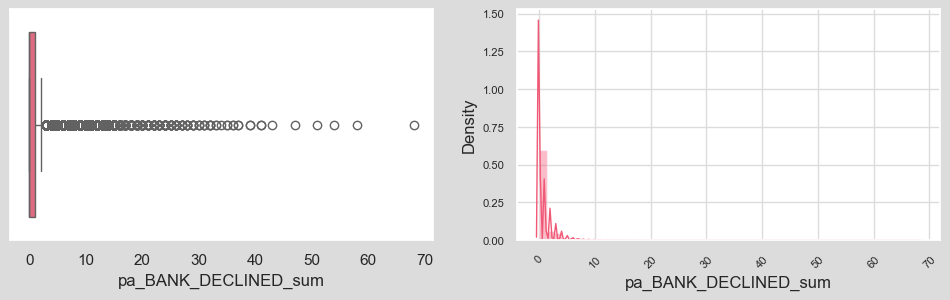

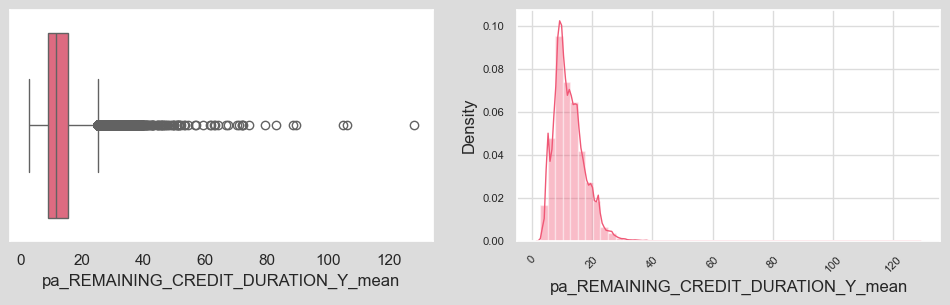

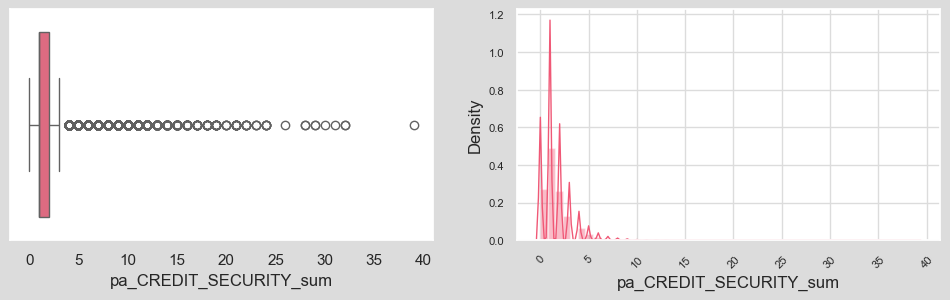

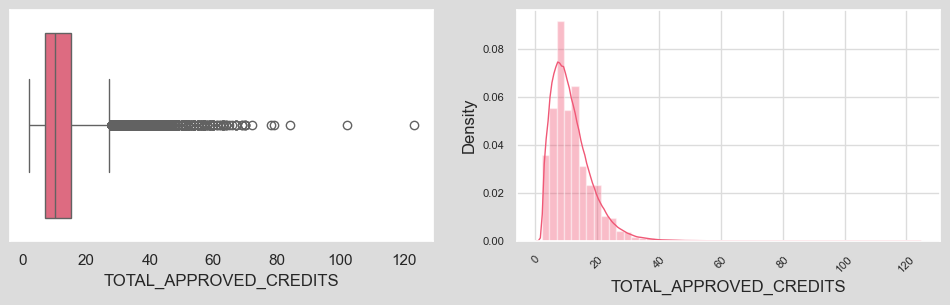

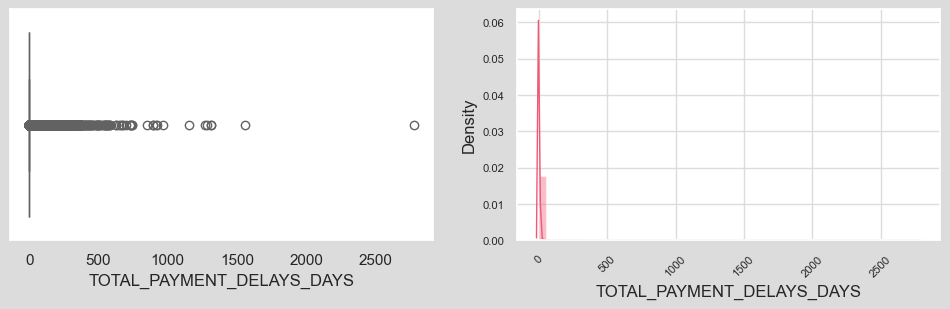

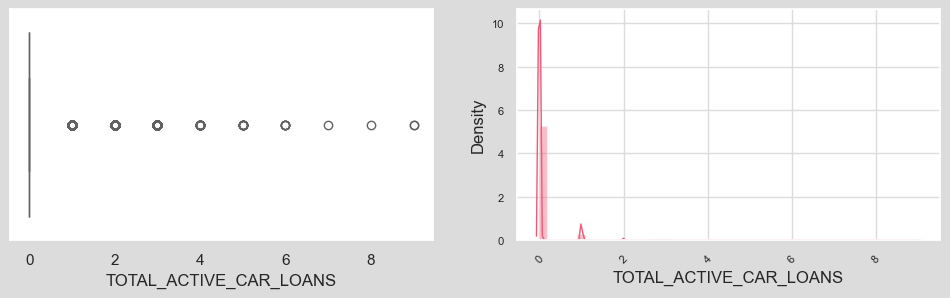

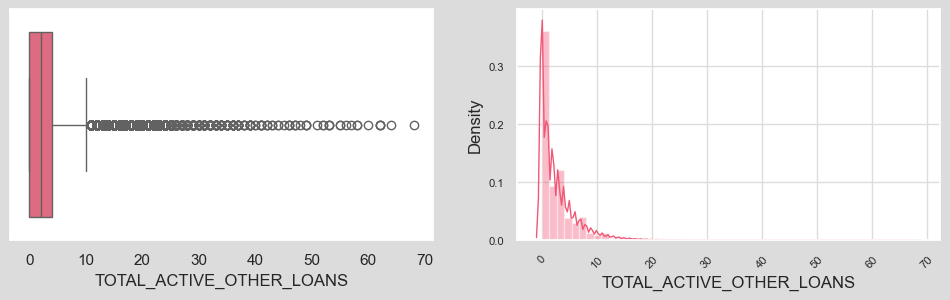

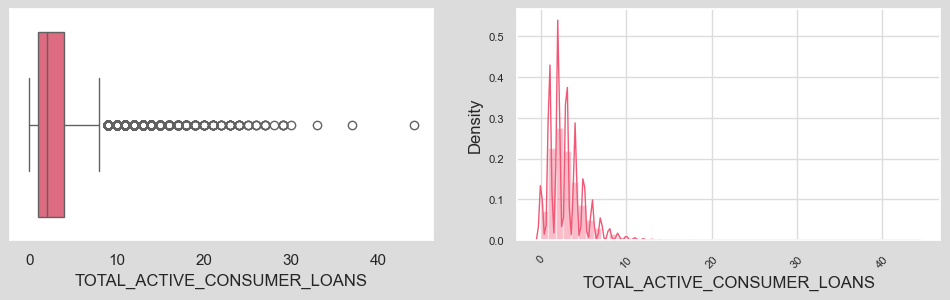

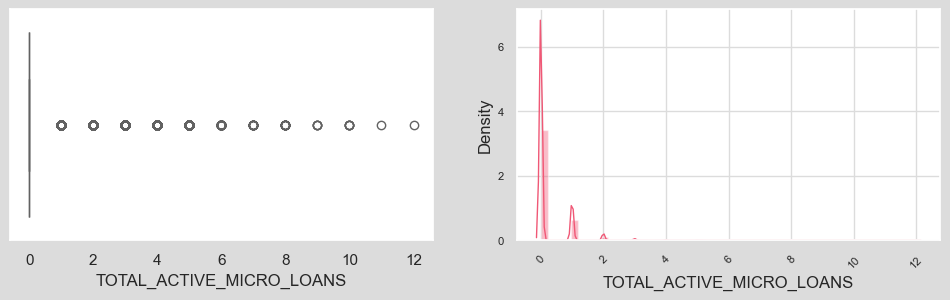

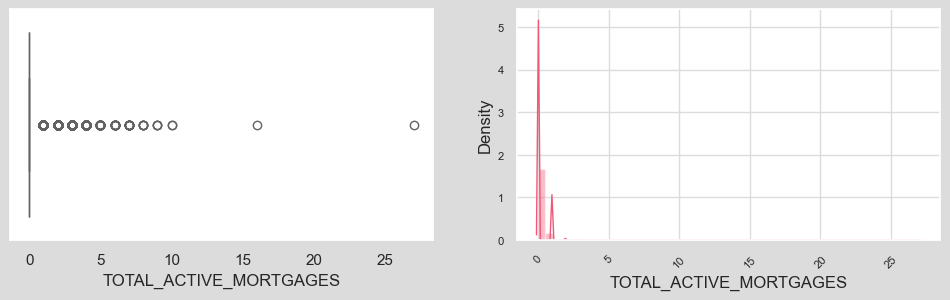

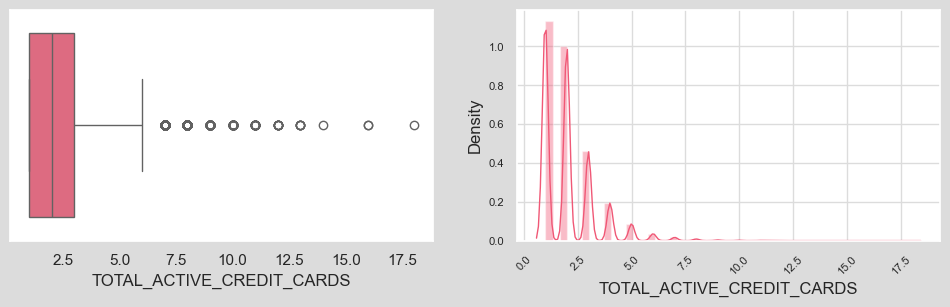

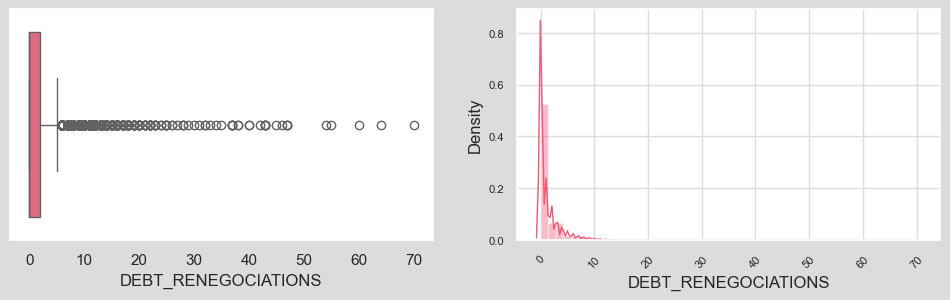

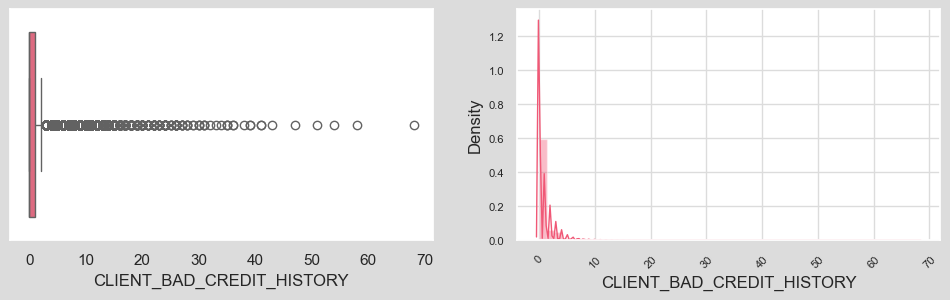

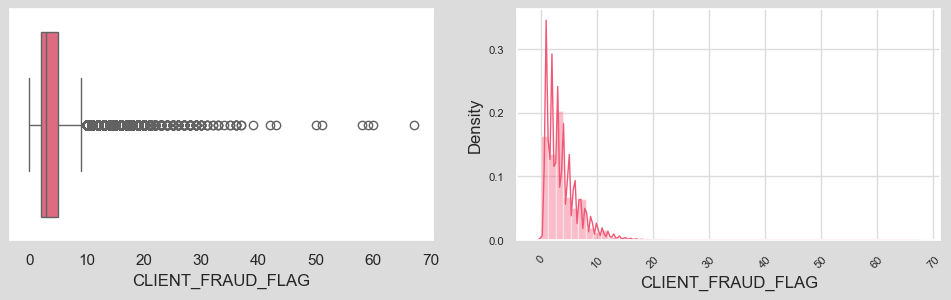

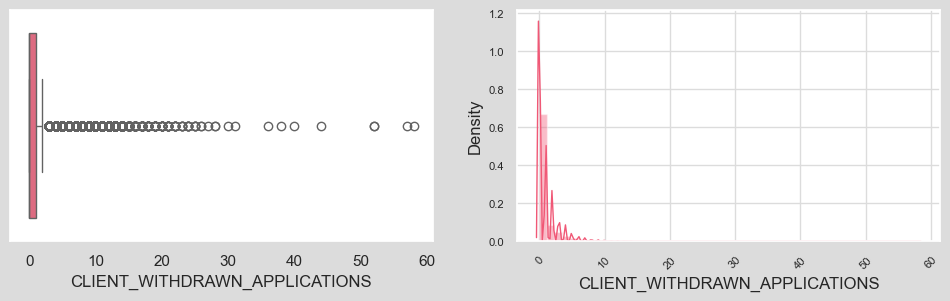

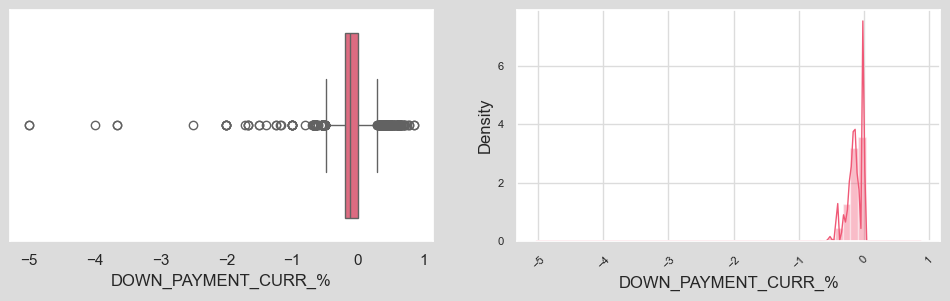

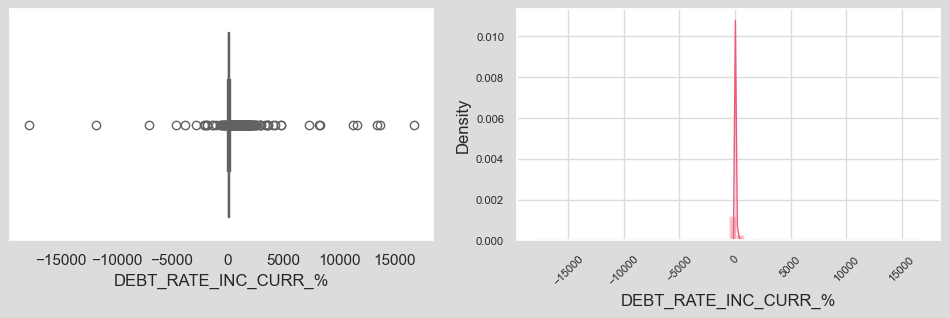

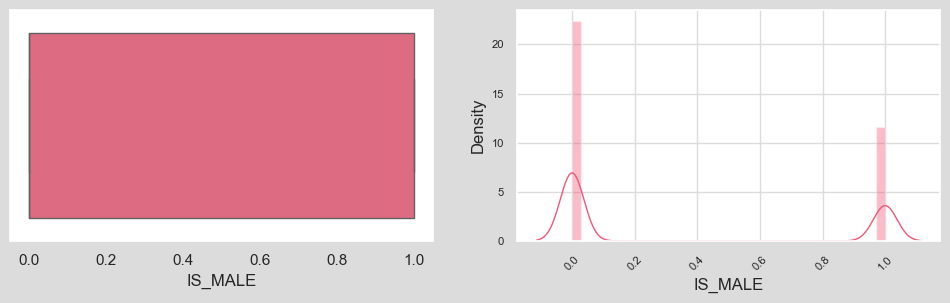

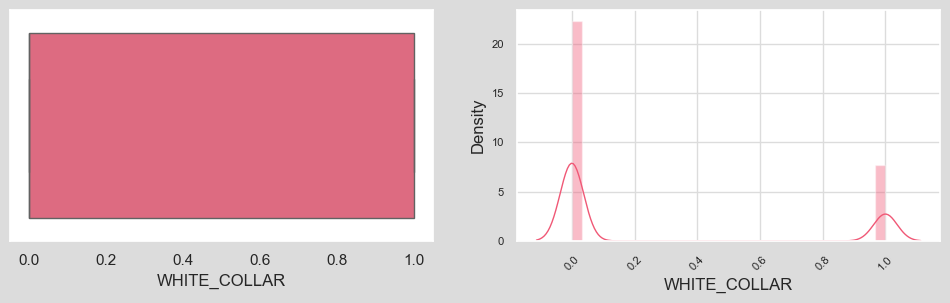

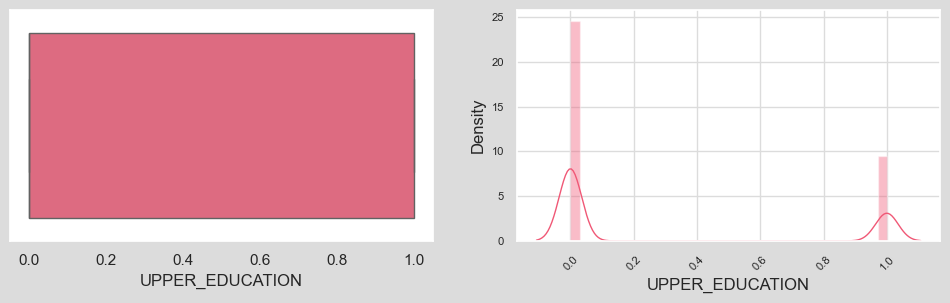

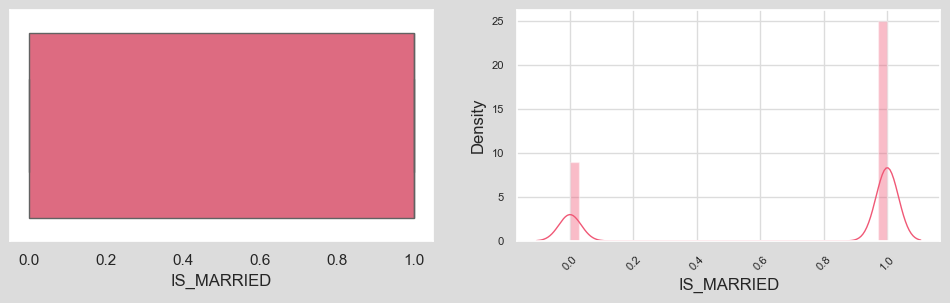

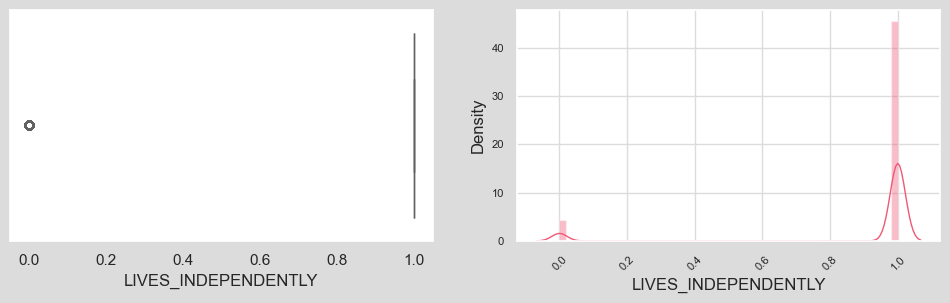

In [10]:
# box_and_hist_plots function is defined in functions.py
fig_num = 1        
for col in train_data.select_dtypes(include=[np.number]).columns:
    box_and_hist_plots(train_data, col, fig_num, bright_pink)
    fig_num = fig_num + 1

In [11]:
# replace outliers with NaNs where values are obviously aberrations not just atypical
train_data.loc[(train_data['YEARS_EMPLOYED_AS_ADULT_%'] > 1), 'YEARS_EMPLOYED_AS_ADULT_%'] = np.nan
train_data.loc[(train_data['pa_REMAINING_CREDIT_DURATION_Y_mean'] > (70 - train_data['YEAR_BIRTH'])), 'pa_REMAINING_CREDIT_DURATION_Y_mean'] = np.nan 
train_data.loc[(train_data['DEBT_RATE_INC_CURR_%'] < 0), 'DEBT_RATE_INC_CURR_%'] = np.nan
train_data.loc[((-train_data['DAYS_REGISTRATION'] / 365) > (train_data['YEAR_BIRTH'] - 21)), 'DAYS_REGISTRATION'] = np.nan

### 1.1.3 - Train / Validation / Test split

- **check distribution of target:**

In [12]:
train_data['TARGET'].value_counts(dropna=False)

TARGET
0    282686
1     24825
Name: count, dtype: int64

**About 8% of individuals in the training set are predicted to default on their debt. Given the class imbalance, stratification will be used to prepare train / validation / test data.**

In [13]:
X_init = train_data.drop(labels='SK_ID_CURR', axis=1)
X_init.shape

(307511, 68)

In [14]:
y_init = X_init['TARGET']

In [15]:
# split into train (70%) and temp (30%) sets
X_train, X_temp, y_train, y_temp = train_test_split(X_init, y_init, test_size=0.3, random_state=rs, shuffle=True, stratify=X_init['TARGET'])

In [16]:
# further split temp set into testing and validation sets
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.5, random_state=rs, shuffle=True, stratify=X_temp['TARGET'])

In [17]:
print(X_train.shape)
print(X_test.shape)
print(X_val.shape)

(215257, 68)
(46127, 68)
(46127, 68)


In [18]:
print(y_train.shape)
print(y_test.shape)
print(y_val.shape)

(215257,)
(46127,)
(46127,)


In [19]:
# check stratified split result
print(y_train.value_counts(dropna=False))
print(y_test.value_counts(dropna=False))
print(y_val.value_counts(dropna=False))

TARGET
0    197880
1     17377
Name: count, dtype: int64
TARGET
0    42403
1     3724
Name: count, dtype: int64
TARGET
0    42403
1     3724
Name: count, dtype: int64


### 1.1.4 - Imputations

In [20]:
# drop target columns from training, testing and validation sets before using Iterative Imputer to prevent data leakage
X_train = X_train.drop(labels=['TARGET'], axis=1)
X_test = X_test.drop(labels=['TARGET'], axis=1)
X_val = X_val.drop(labels=['TARGET'], axis=1)

- **On training set:**

In [21]:
# use iterative imputer to fill NaNs
imputer_train = IterativeImputer(missing_values=np.nan, initial_strategy='median', imputation_order='ascending', skip_complete=True,  verbose=1, random_state=rs)

In [22]:
X_1 = X_train.select_dtypes(include='number')
imputed_1 = imputer_train.fit_transform(X_1)
X_train_ii = pd.DataFrame(imputed_1, columns=X_1.columns).reset_index(drop=True)
X_2 = X_train.select_dtypes(exclude='number').reset_index(drop=True)
X_train_imputed = X_2.join(X_train_ii)
print(X_train_imputed.shape)
print(X_train_imputed.isna().sum().sum(), 'nulls in result dataframe.')
X_train_imputed.sample(5)

[IterativeImputer] Completing matrix with shape (215257, 64)
[IterativeImputer] Change: 2849394.5417600144, scaled tolerance: 116973.8055 
[IterativeImputer] Change: 179235.9577599763, scaled tolerance: 116973.8055 
[IterativeImputer] Change: 56071.80399156191, scaled tolerance: 116973.8055 
[IterativeImputer] Early stopping criterion reached.
(215257, 67)
0 nulls in result dataframe.


,NAME_CONTRACT_TYPE,INCOME_TYPE,EMPLOYMENT_SECTOR,FLAG_OWN_CAR,FLAG_OWN_REALTY,AMT_CREDIT,REGION_POPULATION_RELATIVE,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_EMAIL,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,DISPOSABLE_INCOME,DISPOSABLE_INCOME_per_capita,YEAR_BIRTH,YEARS_EMPLOYED_AS_ADULT_%,PHONE_PROVIDED,PHONE_REACHABLE,ADDRESS_MISMATCH,CREDIT_RATING,NB_APPLICATION_DOCUMENTS_%,REQUESTS_ABOUT_CLIENT_1Y,b_AMT_CREDIT_MAX_OVERDUE_max,b_AMT_CREDIT_SUM_OVERDUE_mean,pcb_CNT_INSTALMENT_FUTURE_max,ccb_AMT_BALANCE_mean,ccb_AMT_CREDIT_LIMIT_ACTUAL_mean,ccb_AMT_DRAWINGS_TOTAL_mean,ccb_AMT_TOTAL_RECEIVABLE_mean,ccb_TOTAL_INSTALMENTS_max,ccb_CNT_DRAWINGS_TOTAL_mean,ccb_CARD_OVERDRAWN_sum,ccb_CARD_OVERDRAWN_%_mean,ip_PMT_DELAY_mean,ip_EARLY_PMT_mean,ip_AMT_OVERPAID_%_mean,ip_AMT_UNDERPAID_%_mean,pa_AMT_APPLICATION_mean,pa_RATE_DOWN_PAYMENT_mean,pa_NFLAG_INSURED_ON_APPROVAL_sum,pa_BANK_DECLINED_sum,pa_REMAINING_CREDIT_DURATION_Y_mean,pa_CREDIT_SECURITY_sum,TOTAL_APPROVED_CREDITS,TOTAL_PAYMENT_DELAYS_DAYS,TOTAL_ACTIVE_CAR_LOANS,TOTAL_ACTIVE_OTHER_LOANS,TOTAL_ACTIVE_CONSUMER_LOANS,TOTAL_ACTIVE_MICRO_LOANS,TOTAL_ACTIVE_MORTGAGES,TOTAL_ACTIVE_CREDIT_CARDS,DEBT_RENEGOCIATIONS,CLIENT_BAD_CREDIT_HISTORY,CLIENT_FRAUD_FLAG,CLIENT_WITHDRAWN_APPLICATIONS,DOWN_PAYMENT_CURR_%,DEBT_RATE_INC_CURR_%,IS_MALE,WHITE_COLLAR,UPPER_EDUCATION,IS_MARRIED,LIVES_INDEPENDENTLY
59851,Cash loans,fixed_salary,tertiary,0.0,0.0,491211.0,0.006671,-1394.693711,-1282.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,-834.0,24016.5,12008.250,31.695890,-0.461834,1.0,1.0,1.0,0.393280,0.05,4.0,0.000,0.0,48.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.185185,9.814815,0.000000,0.074074,495000.000,0.062417,2.0,0.0,17.732383,0.0,6.0,1.654911,0.0,2.0,1.0,0.0,0.0,2.157052,0.662095,0.0,2.0,0.0,-0.0396,836.576848,0.0,1.000000,0.0,1.0,1.0
13528,Cash loans,fixed_salary,government,1.0,1.0,56034.0,0.031329,-4623.000000,-4623.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,-1481.0,106425.0,26606.250,36.827397,-0.412498,1.0,1.0,1.0,0.429806,0.05,3.0,5648.895,0.0,20.0,114997.757143,182142.857143,11603.389286,115151.421429,15.0,3.666667,2.0,0.203814,1.155556,5.877778,0.000000,0.111111,136408.500,0.054100,3.0,1.0,14.580614,2.0,16.0,7.378653,0.0,5.0,2.0,1.0,0.0,3.000000,0.000000,1.0,5.0,0.0,-0.1320,117.451413,0.0,0.000000,0.0,1.0,1.0
203197,Cash loans,commission,tertiary,0.0,1.0,814041.0,0.007120,-3438.000000,-4121.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,-262.0,61029.0,30514.500,40.572603,-0.220885,1.0,1.0,1.0,0.545301,0.05,7.0,0.000,0.0,36.0,0.000000,91451.612903,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,24.727273,0.000000,0.000000,79911.000,0.050688,4.0,0.0,16.282013,1.0,17.0,0.000000,0.0,8.0,6.0,0.0,0.0,1.000000,0.000000,0.0,10.0,5.0,-0.1980,163.148167,0.0,1.000000,0.0,1.0,1.0
212302,Cash loans,commission,tertiary,0.0,1.0,254700.0,0.005313,-478.535557,-2424.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,-747.0,121558.5,60779.250,26.739726,-0.458234,1.0,1.0,1.0,0.476517,0.10,2.0,0.000,0.0,24.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.346154,3.615385,0.000000,0.076923,160920.000,0.000000,0.0,0.0,19.054521,1.0,6.0,-0.538198,0.0,0.0,1.0,0.0,0.0,2.260588,0.601770,0.0,1.0,0.0,-0.1320,24.717432,1.0,1.000000,1.0,1.0,1.0
180267,Cash loans,fixed_salary,other,1.0,0.0,450000.0,0.026392,-1198.000000,-2453.0,0.0,2.0,2.0,5.0,0.0,5.0,0.0,-1108.0,148009.5,37002.375,27.309589,-0.505428,1.0,1.0,1.0,0.466647,0.05,1.0,0.000,0.0,12.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,18.607143,0.072767,0.000000,74665.125,0.000000,0.0,0.0,9.463199,2.0,10.0,4.566408,0.0,0.0,4.0,0.0,1.0,1.198551,0.119181,0.0,4.0,0.0,0.0000,45.602938,1.0,0.265823,1.0,1.0,1.0


- **On testing set:**

In [23]:
X_3 = X_test.select_dtypes(include='number')
imputed_3 = imputer_train.transform(X_3)
X_test_ii = pd.DataFrame(imputed_3, columns=X_3.columns).reset_index(drop=True)
X_4 = X_test.select_dtypes(exclude='number').reset_index(drop=True)
X_test_imputed = X_4.join(X_test_ii)
print(X_test_imputed.shape)
print(X_test_imputed.isna().sum().sum(), 'nulls in result dataframe.')
X_test_imputed.sample(5)

[IterativeImputer] Completing matrix with shape (46127, 64)
(46127, 67)
0 nulls in result dataframe.


,NAME_CONTRACT_TYPE,INCOME_TYPE,EMPLOYMENT_SECTOR,FLAG_OWN_CAR,FLAG_OWN_REALTY,AMT_CREDIT,REGION_POPULATION_RELATIVE,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_EMAIL,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,DISPOSABLE_INCOME,DISPOSABLE_INCOME_per_capita,YEAR_BIRTH,YEARS_EMPLOYED_AS_ADULT_%,PHONE_PROVIDED,PHONE_REACHABLE,ADDRESS_MISMATCH,CREDIT_RATING,NB_APPLICATION_DOCUMENTS_%,REQUESTS_ABOUT_CLIENT_1Y,b_AMT_CREDIT_MAX_OVERDUE_max,b_AMT_CREDIT_SUM_OVERDUE_mean,pcb_CNT_INSTALMENT_FUTURE_max,ccb_AMT_BALANCE_mean,ccb_AMT_CREDIT_LIMIT_ACTUAL_mean,ccb_AMT_DRAWINGS_TOTAL_mean,ccb_AMT_TOTAL_RECEIVABLE_mean,ccb_TOTAL_INSTALMENTS_max,ccb_CNT_DRAWINGS_TOTAL_mean,ccb_CARD_OVERDRAWN_sum,ccb_CARD_OVERDRAWN_%_mean,ip_PMT_DELAY_mean,ip_EARLY_PMT_mean,ip_AMT_OVERPAID_%_mean,ip_AMT_UNDERPAID_%_mean,pa_AMT_APPLICATION_mean,pa_RATE_DOWN_PAYMENT_mean,pa_NFLAG_INSURED_ON_APPROVAL_sum,pa_BANK_DECLINED_sum,pa_REMAINING_CREDIT_DURATION_Y_mean,pa_CREDIT_SECURITY_sum,TOTAL_APPROVED_CREDITS,TOTAL_PAYMENT_DELAYS_DAYS,TOTAL_ACTIVE_CAR_LOANS,TOTAL_ACTIVE_OTHER_LOANS,TOTAL_ACTIVE_CONSUMER_LOANS,TOTAL_ACTIVE_MICRO_LOANS,TOTAL_ACTIVE_MORTGAGES,TOTAL_ACTIVE_CREDIT_CARDS,DEBT_RENEGOCIATIONS,CLIENT_BAD_CREDIT_HISTORY,CLIENT_FRAUD_FLAG,CLIENT_WITHDRAWN_APPLICATIONS,DOWN_PAYMENT_CURR_%,DEBT_RATE_INC_CURR_%,IS_MALE,WHITE_COLLAR,UPPER_EDUCATION,IS_MARRIED,LIVES_INDEPENDENTLY
500,Cash loans,fixed_salary,other,1.0,1.0,337500.0,0.028663,-12008.000000,-3486.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,-2582.0,87084.0,43542.00,54.608219,-0.532975,1.0,1.0,1.0,0.559085,0.05,2.000000,7132.313300,0.000000,36.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,21.294118,16.882353,0.029614,0.132353,209466.0,0.104199,2.0,1.0,10.428333,2.0,10.000000,50.166728,0.000000,4.000000,2.000000,0.000000,0.000000,1.500650,1.133429,1.000000,5.0,1.0,0.0000,178.668330,1.0,0.0,0.0,1.0,1.0
38664,Revolving loans,fixed_salary,tertiary,1.0,0.0,180000.0,0.010500,-1749.294748,-375.0,0.0,3.0,3.0,0.0,0.0,0.0,0.0,-176.0,58500.0,29250.00,21.769863,-1.007117,1.0,1.0,1.0,0.342193,0.00,1.200175,4866.065273,-145.377674,14.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,13.315789,0.000000,0.000000,48942.0,0.000000,0.0,0.0,9.335094,1.0,8.807317,7.967321,0.103862,-0.282312,3.252026,0.202548,0.100119,1.481505,0.256390,0.023062,2.0,0.0,0.0000,37.796646,0.0,0.0,0.0,1.0,1.0
37904,Revolving loans,fixed_salary,tertiary,0.0,0.0,135000.0,0.031329,-2271.000000,-4688.0,0.0,2.0,2.0,1.0,0.0,1.0,0.0,-1101.0,38250.0,9562.50,41.128767,-0.400027,1.0,1.0,1.0,0.543731,0.00,1.000000,52717.500000,0.000000,8.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,13.769231,0.000000,0.000000,71850.0,0.145212,0.0,0.0,5.321139,3.0,11.000000,13.640388,0.000000,0.000000,2.000000,1.000000,0.000000,1.561836,0.161612,0.000000,3.0,0.0,0.0000,69.205976,0.0,0.0,0.0,1.0,0.0
2605,Cash loans,fixed_salary,tertiary,0.0,0.0,948816.0,0.008230,-2569.288192,-4492.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,-1369.0,129627.0,43209.00,36.421918,-0.280867,1.0,1.0,1.0,0.510249,0.05,4.273988,11929.103861,-572.190409,48.0,142605.949551,180000.000000,6932.022472,142569.478820,78.0,0.662921,37.0,1.454466,2.137097,9.919355,0.000000,0.000141,263250.0,0.064009,4.0,0.0,18.552689,0.0,14.543530,5.969612,-0.029757,5.957780,0.982790,-0.090635,-0.040099,2.375655,4.545715,-0.031353,6.0,1.0,-0.1980,295.765674,0.0,0.0,0.0,1.0,1.0
26480,Cash loans,fixed_salary,other,1.0,1.0,640080.0,0.010556,-2779.000000,-101.0,0.0,3.0,3.0,0.0,0.0,0.0,0.0,-599.0,60160.5,30080.25,38.819178,-0.177891,1.0,1.0,1.0,0.292974,0.05,2.000000,14195.025000,0.000000,6.0,187552.440000,355263.157895,30441.796579,186647.437895,14.0,2.631579,0.0,0.000000,0.673077,3.692308,0.000000,0.076923,45292.5,0.026010,0.0,0.0,10.140779,1.0,11.000000,6.460923,0.000000,1.000000,2.000000,0.000000,0.000000,3.000000,2.000000,0.000000,3.0,0.0,-0.4224,180.143972,0.0,0.0,0.0

- **On validation set:**

In [24]:
X_5 = X_val.select_dtypes(include='number')
imputed_5 = imputer_train.transform(X_5)
X_val_ii = pd.DataFrame(imputed_5, columns=X_5.columns).reset_index(drop=True)
X_6 = X_val.select_dtypes(exclude='number').reset_index(drop=True)
X_val_imputed = X_6.join(X_val_ii)
print(X_val_imputed.shape)
print(X_val_imputed.isna().sum().sum(), 'nulls in result dataframe.')
X_val_imputed.sample(5)

[IterativeImputer] Completing matrix with shape (46127, 64)
(46127, 67)
0 nulls in result dataframe.


,NAME_CONTRACT_TYPE,INCOME_TYPE,EMPLOYMENT_SECTOR,FLAG_OWN_CAR,FLAG_OWN_REALTY,AMT_CREDIT,REGION_POPULATION_RELATIVE,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_EMAIL,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,DISPOSABLE_INCOME,DISPOSABLE_INCOME_per_capita,YEAR_BIRTH,YEARS_EMPLOYED_AS_ADULT_%,PHONE_PROVIDED,PHONE_REACHABLE,ADDRESS_MISMATCH,CREDIT_RATING,NB_APPLICATION_DOCUMENTS_%,REQUESTS_ABOUT_CLIENT_1Y,b_AMT_CREDIT_MAX_OVERDUE_max,b_AMT_CREDIT_SUM_OVERDUE_mean,pcb_CNT_INSTALMENT_FUTURE_max,ccb_AMT_BALANCE_mean,ccb_AMT_CREDIT_LIMIT_ACTUAL_mean,ccb_AMT_DRAWINGS_TOTAL_mean,ccb_AMT_TOTAL_RECEIVABLE_mean,ccb_TOTAL_INSTALMENTS_max,ccb_CNT_DRAWINGS_TOTAL_mean,ccb_CARD_OVERDRAWN_sum,ccb_CARD_OVERDRAWN_%_mean,ip_PMT_DELAY_mean,ip_EARLY_PMT_mean,ip_AMT_OVERPAID_%_mean,ip_AMT_UNDERPAID_%_mean,pa_AMT_APPLICATION_mean,pa_RATE_DOWN_PAYMENT_mean,pa_NFLAG_INSURED_ON_APPROVAL_sum,pa_BANK_DECLINED_sum,pa_REMAINING_CREDIT_DURATION_Y_mean,pa_CREDIT_SECURITY_sum,TOTAL_APPROVED_CREDITS,TOTAL_PAYMENT_DELAYS_DAYS,TOTAL_ACTIVE_CAR_LOANS,TOTAL_ACTIVE_OTHER_LOANS,TOTAL_ACTIVE_CONSUMER_LOANS,TOTAL_ACTIVE_MICRO_LOANS,TOTAL_ACTIVE_MORTGAGES,TOTAL_ACTIVE_CREDIT_CARDS,DEBT_RENEGOCIATIONS,CLIENT_BAD_CREDIT_HISTORY,CLIENT_FRAUD_FLAG,CLIENT_WITHDRAWN_APPLICATIONS,DOWN_PAYMENT_CURR_%,DEBT_RATE_INC_CURR_%,IS_MALE,WHITE_COLLAR,UPPER_EDUCATION,IS_MARRIED,LIVES_INDEPENDENTLY
27297,Cash loans,benefits,other,0.0,1.0,454455.0,0.018850,-1216.000000,-4212.0,0.0,2.0,2.0,3.0,0.0,3.0,0.0,-2198.0,171738.0,85869.0,63.542466,0.864273,1.0,1.0,1.0,0.710989,0.05,4.0,0.000000,0.0,48.0,7046.030625,29062.500000,1873.312500,7025.954062,14.0,0.020833,1.0,0.023812,0.040698,8.273256,0.074596,0.005814,564176.2500,0.041608,5.0,1.0,17.065341,2.0,14.0,4.124210,0.0,6.0,2.0,0.0,0.0,1.000000,0.000000,1.0,7.0,1.0,-0.422394,376.280698,0.0,0.249817,0.0,1.0,1.0
1921,Cash loans,benefits,other,0.0,1.0,270000.0,0.014520,-9783.000000,-2922.0,0.0,2.0,2.0,8.0,0.0,8.0,0.0,-1101.0,108598.5,108598.5,53.093151,-0.871641,1.0,1.0,1.0,0.595190,0.05,2.0,0.000000,0.0,36.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.433333,15.633333,0.000000,0.066667,140710.5000,0.000000,0.0,0.0,14.663519,1.0,5.0,6.929879,0.0,0.0,0.0,1.0,0.0,1.451654,0.108014,0.0,1.0,0.0,0.000000,20.940037,0.0,0.172805,0.0,0.0,1.0
20291,Cash loans,fixed_salary,other,0.0,0.0,835380.0,0.020246,-8728.000000,-2175.0,0.0,3.0,3.0,0.0,0.0,0.0,0.0,-1650.0,101871.0,50935.5,51.035616,-0.192557,1.0,1.0,1.0,0.315579,0.05,0.0,20750.310000,0.0,8.0,48911.720824,74647.058824,2119.098176,49492.978412,59.0,0.035294,11.0,0.593523,10.278351,3.783505,0.000000,0.072165,59391.0000,0.107941,0.0,14.0,11.690989,4.0,21.0,6.508978,0.0,11.0,10.0,0.0,0.0,4.000000,14.000000,14.0,2.0,0.0,-0.237600,56.505705,0.0,0.551247,1.0,1.0,1.0
21491,Cash loans,fixed_salary,other,1.0,0.0,247275.0,0.026392,1275.846938,-2627.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,-416.0,226350.0,113175.0,27.284932,-0.066260,1.0,1.0,1.0,0.261064,0.05,1.0,0.000000,0.0,10.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.857143,12.428571,0.000000,0.071429,137487.9375,0.150407,2.0,1.0,13.172914,4.0,16.0,2.879125,1.0,5.0,4.0,0.0,0.0,3.906589,1.276088,1.0,7.0,3.0,-0.099000,25.070310,0.0,1.000000,1.0,1.0,1.0
11384,Cash loans,commission,tertiary,1.0,0.0,675000.0,0.024610,-1741.808026,-1138.0,0.0,2.0,2.0,1.0,0.0,1.0,0.0,-743.0,86346.0,43173.0,24.052055,-0.861759,1.0,1.0,1.0,0.418574,0.05,0.0,9002.076922,0.0,6.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.285714,68.285714,0.000000,0.142857,16560.0000,0.108909,0.0,0.0,5.142697,1.0,5.0,15.230136,0.0,0.0,2.0,0.0,0.0,1.231593,0.047735,0.0,1.0,0.0,0.000000,7.750846,0.0,0.000000,1.0,1.0,1.0


In [25]:
# typecasting

y_train = y_train.astype('int32')
y_test = y_test.astype('int32')
y_val = y_val.astype('int32')

X_train_imputed[['IS_MALE','FLAG_OWN_CAR','FLAG_OWN_REALTY','DAYS_REGISTRATION','DAYS_ID_PUBLISH','FLAG_EMAIL','REGION_RATING_CLIENT','REGION_RATING_CLIENT_W_CITY',
'OBS_30_CNT_SOCIAL_CIRCLE','DEF_30_CNT_SOCIAL_CIRCLE','OBS_60_CNT_SOCIAL_CIRCLE','DEF_60_CNT_SOCIAL_CIRCLE','DAYS_LAST_PHONE_CHANGE', 'YEAR_BIRTH',
                 'WHITE_COLLAR','UPPER_EDUCATION',
'IS_MARRIED','LIVES_INDEPENDENTLY','PHONE_PROVIDED','PHONE_REACHABLE','ADDRESS_MISMATCH','REQUESTS_ABOUT_CLIENT_1Y','pcb_CNT_INSTALMENT_FUTURE_max',
'ccb_TOTAL_INSTALMENTS_max','pa_NFLAG_INSURED_ON_APPROVAL_sum','pa_BANK_DECLINED_sum','pa_CREDIT_SECURITY_sum','TOTAL_APPROVED_CREDITS','TOTAL_ACTIVE_CAR_LOANS',
'TOTAL_ACTIVE_OTHER_LOANS','TOTAL_ACTIVE_CONSUMER_LOANS','TOTAL_ACTIVE_MICRO_LOANS','TOTAL_ACTIVE_MORTGAGES','TOTAL_ACTIVE_CREDIT_CARDS','DEBT_RENEGOCIATIONS',
'CLIENT_BAD_CREDIT_HISTORY','CLIENT_FRAUD_FLAG','CLIENT_WITHDRAWN_APPLICATIONS']] = X_train_imputed[['IS_MALE','FLAG_OWN_CAR','FLAG_OWN_REALTY','DAYS_REGISTRATION',
'DAYS_ID_PUBLISH','FLAG_EMAIL','REGION_RATING_CLIENT','REGION_RATING_CLIENT_W_CITY','OBS_30_CNT_SOCIAL_CIRCLE','DEF_30_CNT_SOCIAL_CIRCLE','OBS_60_CNT_SOCIAL_CIRCLE',
'DEF_60_CNT_SOCIAL_CIRCLE','DAYS_LAST_PHONE_CHANGE', 'YEAR_BIRTH', 'WHITE_COLLAR','UPPER_EDUCATION','IS_MARRIED','LIVES_INDEPENDENTLY','PHONE_PROVIDED','PHONE_REACHABLE',
'ADDRESS_MISMATCH','REQUESTS_ABOUT_CLIENT_1Y','pcb_CNT_INSTALMENT_FUTURE_max','ccb_TOTAL_INSTALMENTS_max','pa_NFLAG_INSURED_ON_APPROVAL_sum',
'pa_BANK_DECLINED_sum','pa_CREDIT_SECURITY_sum','TOTAL_APPROVED_CREDITS','TOTAL_ACTIVE_CAR_LOANS','TOTAL_ACTIVE_OTHER_LOANS','TOTAL_ACTIVE_CONSUMER_LOANS',
'TOTAL_ACTIVE_MICRO_LOANS','TOTAL_ACTIVE_MORTGAGES','TOTAL_ACTIVE_CREDIT_CARDS','DEBT_RENEGOCIATIONS','CLIENT_BAD_CREDIT_HISTORY','CLIENT_FRAUD_FLAG',
'CLIENT_WITHDRAWN_APPLICATIONS']].astype('int32')

X_test_imputed[['IS_MALE','FLAG_OWN_CAR','FLAG_OWN_REALTY','DAYS_REGISTRATION','DAYS_ID_PUBLISH','FLAG_EMAIL','REGION_RATING_CLIENT','REGION_RATING_CLIENT_W_CITY',
'OBS_30_CNT_SOCIAL_CIRCLE','DEF_30_CNT_SOCIAL_CIRCLE','OBS_60_CNT_SOCIAL_CIRCLE','DEF_60_CNT_SOCIAL_CIRCLE','DAYS_LAST_PHONE_CHANGE','YEAR_BIRTH',
                'WHITE_COLLAR','UPPER_EDUCATION',
'IS_MARRIED','LIVES_INDEPENDENTLY','PHONE_PROVIDED','PHONE_REACHABLE','ADDRESS_MISMATCH','REQUESTS_ABOUT_CLIENT_1Y','pcb_CNT_INSTALMENT_FUTURE_max',
'ccb_TOTAL_INSTALMENTS_max','pa_NFLAG_INSURED_ON_APPROVAL_sum','pa_BANK_DECLINED_sum','pa_CREDIT_SECURITY_sum','TOTAL_APPROVED_CREDITS','TOTAL_ACTIVE_CAR_LOANS',
'TOTAL_ACTIVE_OTHER_LOANS','TOTAL_ACTIVE_CONSUMER_LOANS','TOTAL_ACTIVE_MICRO_LOANS','TOTAL_ACTIVE_MORTGAGES','TOTAL_ACTIVE_CREDIT_CARDS','DEBT_RENEGOCIATIONS',
'CLIENT_BAD_CREDIT_HISTORY','CLIENT_FRAUD_FLAG','CLIENT_WITHDRAWN_APPLICATIONS']] = X_test_imputed[['IS_MALE','FLAG_OWN_CAR','FLAG_OWN_REALTY','DAYS_REGISTRATION',
'DAYS_ID_PUBLISH','FLAG_EMAIL','REGION_RATING_CLIENT','REGION_RATING_CLIENT_W_CITY','OBS_30_CNT_SOCIAL_CIRCLE','DEF_30_CNT_SOCIAL_CIRCLE','OBS_60_CNT_SOCIAL_CIRCLE',
'DEF_60_CNT_SOCIAL_CIRCLE','DAYS_LAST_PHONE_CHANGE','YEAR_BIRTH', 'WHITE_COLLAR','UPPER_EDUCATION','IS_MARRIED','LIVES_INDEPENDENTLY','PHONE_PROVIDED','PHONE_REACHABLE',
'ADDRESS_MISMATCH','REQUESTS_ABOUT_CLIENT_1Y','pcb_CNT_INSTALMENT_FUTURE_max','ccb_TOTAL_INSTALMENTS_max','pa_NFLAG_INSURED_ON_APPROVAL_sum',
'pa_BANK_DECLINED_sum','pa_CREDIT_SECURITY_sum','TOTAL_APPROVED_CREDITS','TOTAL_ACTIVE_CAR_LOANS','TOTAL_ACTIVE_OTHER_LOANS','TOTAL_ACTIVE_CONSUMER_LOANS',
'TOTAL_ACTIVE_MICRO_LOANS','TOTAL_ACTIVE_MORTGAGES','TOTAL_ACTIVE_CREDIT_CARDS','DEBT_RENEGOCIATIONS','CLIENT_BAD_CREDIT_HISTORY','CLIENT_FRAUD_FLAG',
'CLIENT_WITHDRAWN_APPLICATIONS']].astype('int32')

X_val_imputed[['IS_MALE','FLAG_OWN_CAR','FLAG_OWN_REALTY','DAYS_REGISTRATION','DAYS_ID_PUBLISH','FLAG_EMAIL','REGION_RATING_CLIENT','REGION_RATING_CLIENT_W_CITY',
'OBS_30_CNT_SOCIAL_CIRCLE','DEF_30_CNT_SOCIAL_CIRCLE','OBS_60_CNT_SOCIAL_CIRCLE','DEF_60_CNT_SOCIAL_CIRCLE','DAYS_LAST_PHONE_CHANGE','YEAR_BIRTH',
               'WHITE_COLLAR','UPPER_EDUCATION',
'IS_MARRIED','LIVES_INDEPENDENTLY','PHONE_PROVIDED','PHONE_REACHABLE','ADDRESS_MISMATCH','REQUESTS_ABOUT_CLIENT_1Y','pcb_CNT_INSTALMENT_FUTURE_max',
'ccb_TOTAL_INSTALMENTS_max','pa_NFLAG_INSURED_ON_APPROVAL_sum','pa_BANK_DECLINED_sum','pa_CREDIT_SECURITY_sum','TOTAL_APPROVED_CREDITS','TOTAL_ACTIVE_CAR_LOANS',
'TOTAL_ACTIVE_OTHER_LOANS','TOTAL_ACTIVE_CONSUMER_LOANS','TOTAL_ACTIVE_MICRO_LOANS','TOTAL_ACTIVE_MORTGAGES','TOTAL_ACTIVE_CREDIT_CARDS','DEBT_RENEGOCIATIONS',
'CLIENT_BAD_CREDIT_HISTORY','CLIENT_FRAUD_FLAG','CLIENT_WITHDRAWN_APPLICATIONS']] = X_val_imputed[['IS_MALE','FLAG_OWN_CAR','FLAG_OWN_REALTY','DAYS_REGISTRATION',
'DAYS_ID_PUBLISH','FLAG_EMAIL','REGION_RATING_CLIENT','REGION_RATING_CLIENT_W_CITY','OBS_30_CNT_SOCIAL_CIRCLE','DEF_30_CNT_SOCIAL_CIRCLE','OBS_60_CNT_SOCIAL_CIRCLE',
'DEF_60_CNT_SOCIAL_CIRCLE','DAYS_LAST_PHONE_CHANGE','YEAR_BIRTH','WHITE_COLLAR','UPPER_EDUCATION','IS_MARRIED','LIVES_INDEPENDENTLY','PHONE_PROVIDED','PHONE_REACHABLE',
'ADDRESS_MISMATCH','REQUESTS_ABOUT_CLIENT_1Y','pcb_CNT_INSTALMENT_FUTURE_max','ccb_TOTAL_INSTALMENTS_max','pa_NFLAG_INSURED_ON_APPROVAL_sum',
'pa_BANK_DECLINED_sum','pa_CREDIT_SECURITY_sum','TOTAL_APPROVED_CREDITS','TOTAL_ACTIVE_CAR_LOANS','TOTAL_ACTIVE_OTHER_LOANS','TOTAL_ACTIVE_CONSUMER_LOANS',
'TOTAL_ACTIVE_MICRO_LOANS','TOTAL_ACTIVE_MORTGAGES','TOTAL_ACTIVE_CREDIT_CARDS','DEBT_RENEGOCIATIONS','CLIENT_BAD_CREDIT_HISTORY','CLIENT_FRAUD_FLAG',
'CLIENT_WITHDRAWN_APPLICATIONS']].astype('int32')

### 1.1.5 - Distributions analysis

In [26]:
data_all = pd.concat([X_train_imputed, X_val_imputed, X_test_imputed], axis=0, ignore_index=True)
data_all.shape

(307511, 67)

In [27]:
data_pairs = data_all.select_dtypes(include='number')
data_pairs.shape

(307511, 64)

In [28]:
# perform Kolmogorov-Smirnov test to check in variables follow Gaussian distribution and skew test
# to check for significant skew requiring correction in pipeline pre-processing steps
for column in data_pairs:
    print('********\n{}'.format(column))
    mu = data_pairs[column].mean()
    sigma = data_pairs[column].std()
    normed_column = (data_pairs[column] - mu) / sigma
    stat_ks, p_ks = st.kstest(normed_column, 'norm')
    stat_st, p_st = st.skewtest(data_pairs[column])
    
    alpha = 0.05
    print("\n Kolmogorov-Smirnov test results : \n")
    print("Statistic = {:.4f}".format(stat_ks))
    print("p-value = {:.4f}".format(p_ks))
    if p_ks < alpha:  # null hypothesis: column follows a Normal distribution
        print("Reject H0 : {} does not follow a normal distribution".format(column))
    else:
        print("Not enough information to reject H0: {} follows a normal distribution. ".format(column))
        
    print("\n Skew test results : \n")
    print("Statistic = {:.4f}".format(stat_st))
    print("p-value = {:.4f}".format(p_st))
    if p_st < alpha:  # null hypothesis: column skew is the same as a Normal distribution (about zero)
        print("Reject H0 : {} skew is not zero".format(column))
    else:
        print("Not enough information to reject H0: {} skew is zero.".format(column))

********
FLAG_OWN_CAR

 Kolmogorov-Smirnov test results : 

Statistic = 0.4235
p-value = 0.0000
Reject H0 : FLAG_OWN_CAR does not follow a normal distribution

 Skew test results : 

Statistic = 139.2660
p-value = 0.0000
Reject H0 : FLAG_OWN_CAR skew is not zero
********
FLAG_OWN_REALTY

 Kolmogorov-Smirnov test results : 

Statistic = 0.4405
p-value = 0.0000
Reject H0 : FLAG_OWN_REALTY does not follow a normal distribution

 Skew test results : 

Statistic = -166.7043
p-value = 0.0000
Reject H0 : FLAG_OWN_REALTY skew is not zero
********
AMT_CREDIT

 Kolmogorov-Smirnov test results : 

Statistic = 0.1101
p-value = 0.0000
Reject H0 : AMT_CREDIT does not follow a normal distribution

 Skew test results : 

Statistic = 222.1103
p-value = 0.0000
Reject H0 : AMT_CREDIT skew is not zero
********
REGION_POPULATION_RELATIVE

 Kolmogorov-Smirnov test results : 

Statistic = 0.1135
p-value = 0.0000
Reject H0 : REGION_POPULATION_RELATIVE does not follow a normal distribution

 Skew test results 

C:\Users\celin\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_stats_py.py:1636: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  b2 = skew(a, axis, _no_deco=True)



 Kolmogorov-Smirnov test results : 

Statistic = 0.0240
p-value = 0.0000
Reject H0 : CREDIT_RATING does not follow a normal distribution

 Skew test results : 

Statistic = -85.9005
p-value = 0.0000
Reject H0 : CREDIT_RATING skew is not zero
********
NB_APPLICATION_DOCUMENTS_%

 Kolmogorov-Smirnov test results : 

Statistic = 0.4843
p-value = 0.0000
Reject H0 : NB_APPLICATION_DOCUMENTS_% does not follow a normal distribution

 Skew test results : 

Statistic = -192.7955
p-value = 0.0000
Reject H0 : NB_APPLICATION_DOCUMENTS_% skew is not zero
********
REQUESTS_ABOUT_CLIENT_1Y

 Kolmogorov-Smirnov test results : 

Statistic = 0.1836
p-value = 0.0000
Reject H0 : REQUESTS_ABOUT_CLIENT_1Y does not follow a normal distribution

 Skew test results : 

Statistic = 520.0185
p-value = 0.0000
Reject H0 : REQUESTS_ABOUT_CLIENT_1Y skew is not zero
********
b_AMT_CREDIT_MAX_OVERDUE_max

 Kolmogorov-Smirnov test results : 

Statistic = 0.4866
p-value = 0.0000
Reject H0 : b_AMT_CREDIT_MAX_OVERDUE_max

**None of the continuous variables being Gaussian, we will evaluate correlations using Spearman's Rho.**

### 1.1.6 - Correlations analysis

In [33]:
data_all.head(1)

,NAME_CONTRACT_TYPE,INCOME_TYPE,EMPLOYMENT_SECTOR,FLAG_OWN_CAR,FLAG_OWN_REALTY,AMT_CREDIT,REGION_POPULATION_RELATIVE,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_EMAIL,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,DISPOSABLE_INCOME,DISPOSABLE_INCOME_per_capita,YEAR_BIRTH,YEARS_EMPLOYED_AS_ADULT_%,PHONE_PROVIDED,PHONE_REACHABLE,ADDRESS_MISMATCH,CREDIT_RATING,NB_APPLICATION_DOCUMENTS_%,REQUESTS_ABOUT_CLIENT_1Y,b_AMT_CREDIT_MAX_OVERDUE_max,b_AMT_CREDIT_SUM_OVERDUE_mean,pcb_CNT_INSTALMENT_FUTURE_max,ccb_AMT_BALANCE_mean,ccb_AMT_CREDIT_LIMIT_ACTUAL_mean,ccb_AMT_DRAWINGS_TOTAL_mean,ccb_AMT_TOTAL_RECEIVABLE_mean,ccb_TOTAL_INSTALMENTS_max,ccb_CNT_DRAWINGS_TOTAL_mean,ccb_CARD_OVERDRAWN_sum,ccb_CARD_OVERDRAWN_%_mean,ip_PMT_DELAY_mean,ip_EARLY_PMT_mean,ip_AMT_OVERPAID_%_mean,ip_AMT_UNDERPAID_%_mean,pa_AMT_APPLICATION_mean,pa_RATE_DOWN_PAYMENT_mean,pa_NFLAG_INSURED_ON_APPROVAL_sum,pa_BANK_DECLINED_sum,pa_REMAINING_CREDIT_DURATION_Y_mean,pa_CREDIT_SECURITY_sum,TOTAL_APPROVED_CREDITS,TOTAL_PAYMENT_DELAYS_DAYS,TOTAL_ACTIVE_CAR_LOANS,TOTAL_ACTIVE_OTHER_LOANS,TOTAL_ACTIVE_CONSUMER_LOANS,TOTAL_ACTIVE_MICRO_LOANS,TOTAL_ACTIVE_MORTGAGES,TOTAL_ACTIVE_CREDIT_CARDS,DEBT_RENEGOCIATIONS,CLIENT_BAD_CREDIT_HISTORY,CLIENT_FRAUD_FLAG,CLIENT_WITHDRAWN_APPLICATIONS,DOWN_PAYMENT_CURR_%,DEBT_RATE_INC_CURR_%,IS_MALE,WHITE_COLLAR,UPPER_EDUCATION,IS_MARRIED,LIVES_INDEPENDENTLY
0,Cash loans,commission,other,1,1,1971072.0,0.006852,-949,-1823,0,3,3,4,0,4,0,-2169,336357.0,84089.25,37,-0.17359,1,1,1,0.548664,0.05,0,0.0,0.0,12,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,12.75,0.0,0.0,51610.5,0.100269,0,0,8.620663,1,6,9.365847,1,0,2,0,0,1,0,0,1,0,-0.09504,5.984466,0,1,1,1,1


In [34]:
data_all_thresholds = {'categorical': 0.5, 'binary_continuous': 0.5, 'discrete_continuous': 0.5, 'continuous': 0.8}

For interpretation of Spearman's rho see : https://www.researchgate.net/figure/Grading-table-of-Spearman-correlation-coefficient-r_tbl2_331096265

In [35]:
# Get correlation matrix
high_correlations = calculate_correlation_matrix(data_all, continuous_method='spearman', thresholds=data_all_thresholds)
print("Highly Correlated Pairs:")
for pair in high_correlations:
    print(f"{pair[0]} - {pair[1]}: {pair[2]:.2f} ({pair[3]})")

  File "C:\Users\celin\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\celin\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 556, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\celin\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 1038, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                

Highly Correlated Pairs:
REGION_POPULATION_RELATIVE - REGION_RATING_CLIENT: 0.75 (discrete_continuous)
REGION_POPULATION_RELATIVE - REGION_RATING_CLIENT_W_CITY: 0.70 (discrete_continuous)
REGION_RATING_CLIENT - REGION_RATING_CLIENT_W_CITY: 0.96 (categorical)
OBS_30_CNT_SOCIAL_CIRCLE - OBS_60_CNT_SOCIAL_CIRCLE: 1.00 (continuous)
DEF_30_CNT_SOCIAL_CIRCLE - DEF_60_CNT_SOCIAL_CIRCLE: 0.77 (categorical)
ccb_AMT_BALANCE_mean - ccb_AMT_DRAWINGS_TOTAL_mean: 0.97 (continuous)
ccb_AMT_BALANCE_mean - ccb_AMT_TOTAL_RECEIVABLE_mean: 0.99 (continuous)
ccb_AMT_BALANCE_mean - ccb_TOTAL_INSTALMENTS_max: 0.98 (continuous)
ccb_AMT_BALANCE_mean - ccb_CNT_DRAWINGS_TOTAL_mean: 0.97 (continuous)
ccb_AMT_DRAWINGS_TOTAL_mean - ccb_AMT_TOTAL_RECEIVABLE_mean: 0.97 (continuous)
ccb_AMT_DRAWINGS_TOTAL_mean - ccb_TOTAL_INSTALMENTS_max: 0.95 (continuous)
ccb_AMT_DRAWINGS_TOTAL_mean - ccb_CNT_DRAWINGS_TOTAL_mean: 0.99 (continuous)
ccb_AMT_TOTAL_RECEIVABLE_mean - ccb_TOTAL_INSTALMENTS_max: 0.96 (continuous)
ccb_AMT_TO

In [63]:
corr_matrix = pd.read_csv('correlation_matrix_Spearman.csv', index_col=0)
corr_matrix.head()

,NAME_CONTRACT_TYPE,INCOME_TYPE,EMPLOYMENT_SECTOR,FLAG_OWN_CAR,FLAG_OWN_REALTY,AMT_CREDIT,REGION_POPULATION_RELATIVE,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_EMAIL,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,DISPOSABLE_INCOME,DISPOSABLE_INCOME_per_capita,YEAR_BIRTH,YEARS_EMPLOYED_AS_ADULT_%,PHONE_PROVIDED,PHONE_REACHABLE,ADDRESS_MISMATCH,CREDIT_RATING,NB_APPLICATION_DOCUMENTS_%,REQUESTS_ABOUT_CLIENT_1Y,b_AMT_CREDIT_MAX_OVERDUE_max,b_AMT_CREDIT_SUM_OVERDUE_mean,pcb_CNT_INSTALMENT_FUTURE_max,ccb_AMT_BALANCE_mean,ccb_AMT_CREDIT_LIMIT_ACTUAL_mean,ccb_AMT_DRAWINGS_TOTAL_mean,ccb_AMT_TOTAL_RECEIVABLE_mean,ccb_TOTAL_INSTALMENTS_max,ccb_CNT_DRAWINGS_TOTAL_mean,ccb_CARD_OVERDRAWN_sum,ccb_CARD_OVERDRAWN_%_mean,ip_PMT_DELAY_mean,ip_EARLY_PMT_mean,ip_AMT_OVERPAID_%_mean,ip_AMT_UNDERPAID_%_mean,pa_AMT_APPLICATION_mean,pa_RATE_DOWN_PAYMENT_mean,pa_NFLAG_INSURED_ON_APPROVAL_sum,pa_BANK_DECLINED_sum,pa_REMAINING_CREDIT_DURATION_Y_mean,pa_CREDIT_SECURITY_sum,TOTAL_APPROVED_CREDITS,TOTAL_PAYMENT_DELAYS_DAYS,TOTAL_ACTIVE_CAR_LOANS,TOTAL_ACTIVE_OTHER_LOANS,TOTAL_ACTIVE_CONSUMER_LOANS,TOTAL_ACTIVE_MICRO_LOANS,TOTAL_ACTIVE_MORTGAGES,TOTAL_ACTIVE_CREDIT_CARDS,DEBT_RENEGOCIATIONS,CLIENT_BAD_CREDIT_HISTORY,CLIENT_FRAUD_FLAG,CLIENT_WITHDRAWN_APPLICATIONS,DOWN_PAYMENT_CURR_%,DEBT_RATE_INC_CURR_%,IS_MALE,WHITE_COLLAR,UPPER_EDUCATION,IS_MARRIED,LIVES_INDEPENDENTLY
NAME_CONTRACT_TYPE,1.000000,0.057038,0.040107,0.003595,0.067153,0.198281,0.004388,0.003420,0.002406,0.010660,0.026417,0.026258,0.002538,0.013111,0.002080,0.010666,0.007358,0.285527,0.275296,0.013128,0.005461,0.0,0.0,0.0,0.001094,0.290666,0.008699,0.004360,0.000289,0.008129,0.012657,0.019800,0.012123,0.012424,0.012341,0.011268,0.008210,0.007752,0.005584,0.007060,0.002570,0.005119,0.000837,0.001079,0.007983,0.003488,0.008295,0.011638,0.003178,0.009216,0.000000,0.008359,0.010250,0.001496,0.000722,0.029812,0.004803,0.002590,0.008510,0.004437,0.110794,0.004883,0.008596,0.035812,0.066370,0.025633,0.013488
INCOME_TYPE,0.057038,1.000000,0.450168,0.156161,0.070607,0.026285,0.044219,0.060334,0.050032,0.078552,0.128149,0.121033,0.000851,0.014633,0.001503,0.011949,0.002340,0.057517,0.037495,0.267971,0.178132,0.0,0.0,0.0,0.085271,0.033489,0.004324,0.010901,0.001224,0.012806,0.002501,0.006126,0.002642,0.003272,0.003190,0.004646,0.000896,0.002539,0.003199,0.007462,0.003676,0.004634,0.009293,0.009918,0.009577,0.001601,0.015969,0.008491,0.000816,0.007751,0.040261,0.006085,0.012923,0.000513,0.001646,0.017074,0.002769,0.000259,0.004968,0.001801,0.014578,0.007642,0.157196,0.159934,0.161311,0.090107,0.072189
EMPLOYMENT_SECTOR,0.040107,0.450168,1.000000,0.103310,0.051248,0.009350,0.012133,0.027153,0.018994,0.050914,0.059136,0.060320,0.000000,0.007244,0.002328,0.007682,0.001681,0.020756,0.013320,0.112851,0.097392,0.0,0.0,0.0,0.030732,0.025581,0.003399,0.003543,0.001448,0.007207,0.000690,0.001591,0.000215,0.000947,0.000771,0.000000,0.000000,0.001334,0.001872,0.003795,0.000078,0.003886,0.001076,0.007563,0.006839,0.000051,0.006211,0.006540,0.003416,0.002325,0.018692,0.002652,0.008168,0.000392,0.002449,0.014537,0.000985,0.000000,0.003537,0.002780,0.006393,0.003814,0.158248,0.101026,0.139314,0.056230,0.054930
FLAG_OWN_CAR,0.003595,0.156161,0.103310,1.000000,0.002164,0.116225,0.041314,0.096976,0.013661,0.032054,0.023422,0.022793,0.003221,0.015186,0.003132,0.016049,-0.039089,0.075475,0.040321,-0.129867,-0.014595,0.0,0.0,0.0,-0.059513,0.015428,-0.018943,0.004322,-0.002033,-0.034214,-0.005731,-0.000326,0.007013,-0.005611,-0.010021,-0.010004,-0.018163,-0.021388,0.000141,-0.008483,0.000986,-0.000183,0.069800,0.045123,-0.050309,0.006298,-0.009526,0.084944,0.037009,-0.002082,0.176990,-0.040823,0.070845,-0.013048,0.015689,0.007636,0.000245,0.006075,-0.015633,-0.023434,0.036490,-0.038423,0.345837,0.062844,0.094356,0.142488,0.017844
FLAG_OWN_REALTY,0.067153,0.070607,0.051248,0.002164,1.000000,-0.039270,0.01517

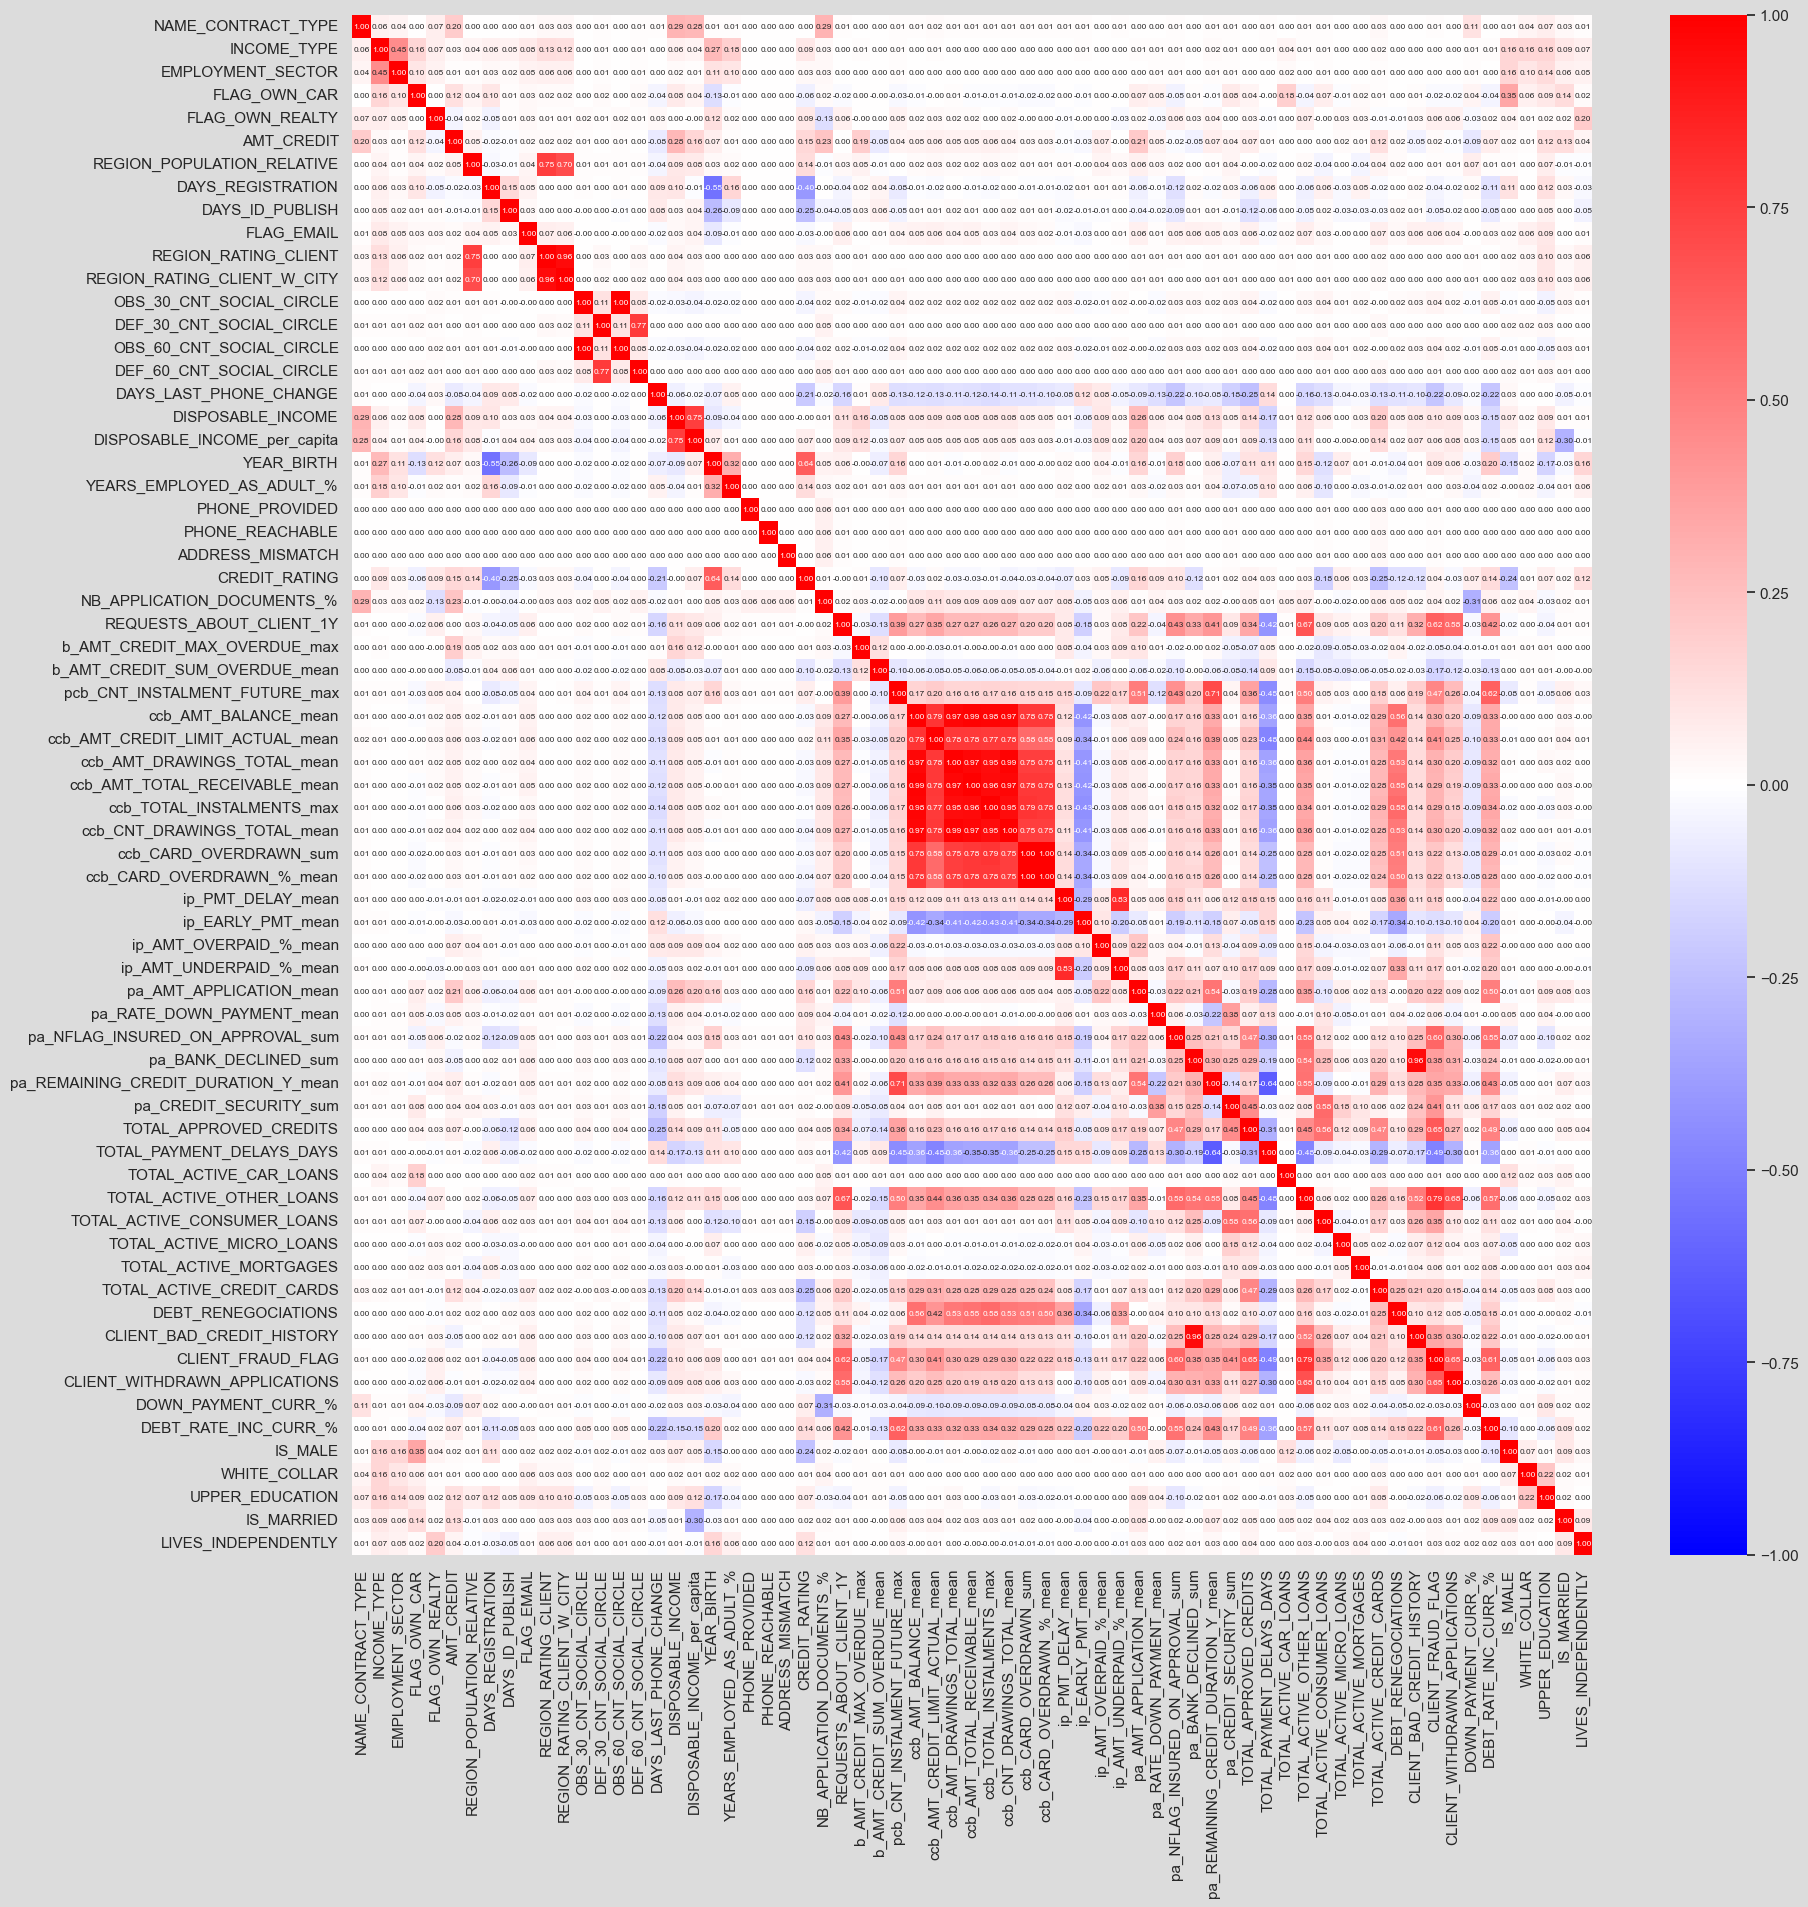

In [66]:
# Display correlations matrix heatmap will all variable types included
fig, ax = plt.subplots(figsize=(20,20))
all_corrs_heatmap = sns.heatmap(corr_matrix.round(2), vmin=-1, vmax=1, annot=True, cmap="bwr", fmt="0.2f", 
                                 annot_kws={"fontsize":6})
plt.savefig("spearman_heatmap_all.png", bbox_inches="tight")
plt.show()

In [45]:
high_corr_df = pd.DataFrame(high_correlations)
high_corr_df.to_csv('high_corr_df.csv', index=False, header=None)
high_corr_df

,0,1,2,3
0,REGION_POPULATION_RELATIVE,REGION_RATING_CLIENT,0.753287,discrete_continuous
1,REGION_POPULATION_RELATIVE,REGION_RATING_CLIENT_W_CITY,0.702174,discrete_continuous
2,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,0.956526,categorical
3,OBS_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,0.997338,continuous
4,DEF_30_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,0.768112,categorical
5,ccb_AMT_BALANCE_mean,ccb_AMT_DRAWINGS_TOTAL_mean,0.973520,continuous
6,ccb_AMT_BALANCE_mean,ccb_AMT_TOTAL_RECEIVABLE_mean,0.991042,continuous
7,ccb_AMT_BALANCE_mean,ccb_TOTAL_INSTALMENTS_max,0.976525,continuous
8,ccb_AMT_BALANCE_mean,ccb_CNT_DRAWINGS_TOTAL_mean,0.973529,continuous
9,ccb_AMT_DRAWINGS_TOTAL_mean,ccb_AMT_TOTAL_RECEIVABLE_mean,0.966065,continuous


In [39]:
cols_to_drop = high_corr_df.iloc[:,0].unique()
cols_to_drop

array(['REGION_POPULATION_RELATIVE', 'REGION_RATING_CLIENT',
       'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE',
       'ccb_AMT_BALANCE_mean', 'ccb_AMT_DRAWINGS_TOTAL_mean',
       'ccb_AMT_TOTAL_RECEIVABLE_mean', 'ccb_TOTAL_INSTALMENTS_max',
       'ccb_CARD_OVERDRAWN_sum', 'ip_PMT_DELAY_mean',
       'pa_BANK_DECLINED_sum'], dtype=object)

- **Remove colinear features:**

In [40]:
X_train_final = X_train_imputed.drop(labels=[*cols_to_drop], axis=1)
X_test_final = X_test_imputed.drop(labels=[*cols_to_drop], axis=1)
X_val_final = X_val_imputed.drop(labels=[*cols_to_drop], axis=1)
print(X_train_final.shape)
print(X_test_final.shape)
print(X_val_final.shape)

(215257, 56)
(46127, 56)
(46127, 56)


- **Save final files:**

In [46]:
X_train_final.to_csv('X_train_final.csv', index=False)
X_test_final.to_csv('X_test_final.csv', index=False)
X_val_final.to_csv('X_val_final.csv', index=False)

y_train.to_csv('y_train_final.csv', index=False)
y_test.to_csv('y_test_final.csv', index=False)
y_val.to_csv('y_val_final.csv', index=False)

## 1.2 - Testing set

### 1.2.1 - Import data & check for NaNs

In [47]:
test_data = pd.read_csv('test_data_raw.csv',  sep=',', encoding='utf-8')
print(test_data.shape)
test_data.sample(5)

(48744, 69)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,FLAG_OWN_CAR,FLAG_OWN_REALTY,AMT_CREDIT,REGION_POPULATION_RELATIVE,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_EMAIL,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,DISPOSABLE_INCOME,DISPOSABLE_INCOME_per_capita,INCOME_TYPE,YEAR_BIRTH,YEARS_EMPLOYED_AS_ADULT_%,PHONE_PROVIDED,PHONE_REACHABLE,ADDRESS_MISMATCH,CREDIT_RATING,NB_APPLICATION_DOCUMENTS_%,REQUESTS_ABOUT_CLIENT_1Y,EMPLOYMENT_SECTOR,b_AMT_CREDIT_MAX_OVERDUE_max,b_AMT_CREDIT_SUM_OVERDUE_mean,pcb_CNT_INSTALMENT_FUTURE_max,ccb_AMT_BALANCE_mean,ccb_AMT_CREDIT_LIMIT_ACTUAL_mean,ccb_AMT_DRAWINGS_TOTAL_mean,ccb_AMT_TOTAL_RECEIVABLE_mean,ccb_TOTAL_INSTALMENTS_max,ccb_CNT_DRAWINGS_TOTAL_mean,ccb_CARD_OVERDRAWN_sum,ccb_CARD_OVERDRAWN_%_mean,ip_PMT_DELAY_mean,ip_EARLY_PMT_mean,ip_AMT_OVERPAID_%_mean,ip_AMT_UNDERPAID_%_mean,pa_AMT_APPLICATION_mean,pa_RATE_DOWN_PAYMENT_mean,pa_NFLAG_INSURED_ON_APPROVAL_sum,pa_BANK_DECLINED_sum,pa_REMAINING_CREDIT_DURATION_Y_mean,pa_CREDIT_SECURITY_sum,TOTAL_APPROVED_CREDITS,TOTAL_PAYMENT_DELAYS_DAYS,TOTAL_ACTIVE_CAR_LOANS,TOTAL_ACTIVE_OTHER_LOANS,TOTAL_ACTIVE_CONSUMER_LOANS,TOTAL_ACTIVE_MICRO_LOANS,TOTAL_ACTIVE_MORTGAGES,TOTAL_ACTIVE_CREDIT_CARDS,DEBT_RENEGOCIATIONS,CLIENT_BAD_CREDIT_HISTORY,CLIENT_FRAUD_FLAG,CLIENT_WITHDRAWN_APPLICATIONS,DOWN_PAYMENT_CURR_%,DEBT_RATE_INC_CURR_%,IS_MALE,WHITE_COLLAR,UPPER_EDUCATION,IS_MARRIED,LIVES_INDEPENDENTLY
10480,176077,UNKNOWN,Cash loans,1,1,1085742.0,0.007120,-6864.0,-4143,0,2,2,0.0,0.0,0.0,0.0,-2590.0,234846.0,78282.00,commission,42.424658,-0.176982,1.0,1.0,NaN,0.741137,0.05,2.0,other,9544.500,0.0,36.0,34756.129588,111705.882353,1657.058824,34743.236824,27.0,0.058824,5.0,0.125988,1.119497,2.918239,0.024185,0.050314,630000.000000,0.000000,2.0,0.0,17.199519,1.0,18.0,0.374495,0.0,4.0,0.0,0.0,0.0,2.0,2.0,0.0,4.0,0.0,-0.231000,187.633868,0.0,1.0,1.0,0.0,1.0
44250,423651,UNKNOWN,Cash loans,0,1,450000.0,0.018801,-4411.0,-1398,0,2,2,0.0,0.0,0.0,0.0,-1903.0,155587.5,77793.75,fixed_salary,27.597260,-1.088455,1.0,1.0,NaN,NaN,0.05,NaN,tertiary,NaN,NaN,36.0,0.000000,112500.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.076923,5.871795,0.000000,0.000000,161025.000000,0.120702,1.0,0.0,15.247888,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,0.0,0.000000,NaN,0.0,0.0,1.0,1.0,1.0
18689,235792,UNKNOWN,Cash loans,0,1,500211.0,0.010006,-3580.0,-3955,0,2,2,0.0,0.0,0.0,0.0,-1533.0,186160.5,186160.50,benefits,56.926027,27.853504,1.0,1.0,NaN,NaN,0.05,4.0,other,21162.465,0.0,14.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.458333,22.041667,0.000000,0.083333,77929.778571,0.026191,1.0,0.0,8.085538,1.0,17.0,NaN,0.0,3.0,6.0,0.0,0.0,NaN,NaN,0.0,7.0,2.0,-0.079204,48.828753,1.0,NaN,0.0,0.0,1.0
34788,354320,UNKNOWN,Cash loans,0,0,280170.0,0.019101,-7225.0,-4593,0,2,2,0.0,0.0,0.0,0.0,-2092.0,61164.0,20388.00,fixed_salary,43.789041,-0.225174,1.0,1.0,1.0,0.621760,0.05,1.0,tertiary,NaN,0.0,10.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,1.354839,14.387097,0.000000,0.064516,86308.470000,0.135593,0.0,0.0,6.381199,3.0,9.0,NaN,0.0,0.0,4.0,0.0,0.0,NaN,NaN,0.0,3.0,0.0,-0.132000,75.004694,1.0,0.0,0.0,1.0,1.0
45216,431088,UNKNOWN,Cash loans,1,0,341280.0,0.014464,-3966.0,-944,0,2,2,0.0,0.0,0.0,0.0,-391.0,178438.5,89219.25,fixed_salary,47.693151,-0.061069,1.0,1.0,NaN,NaN,0.05,NaN,tertiary,NaN,NaN,12.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.812500,12.437500,0.298179,0.187500,263250.000000,0.102802,0.0,0.0,10.531856,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,-0.264000,NaN,1.0,NaN,0.0,1.0,1.0


In [48]:
test_data = test_data.drop(labels=['SK_ID_CURR', 'TARGET'], axis=1)

In [49]:
# cat_cols = ['NAME_CONTRACT_TYPE',  'INCOME_TYPE', 'EMPLOYMENT_SECTOR']
# test_data['SK_ID_CURR'] = test_data['SK_ID_CURR'].astype('string')
test_data[cat_cols] = test_data[cat_cols].astype('category')

<Axes: >

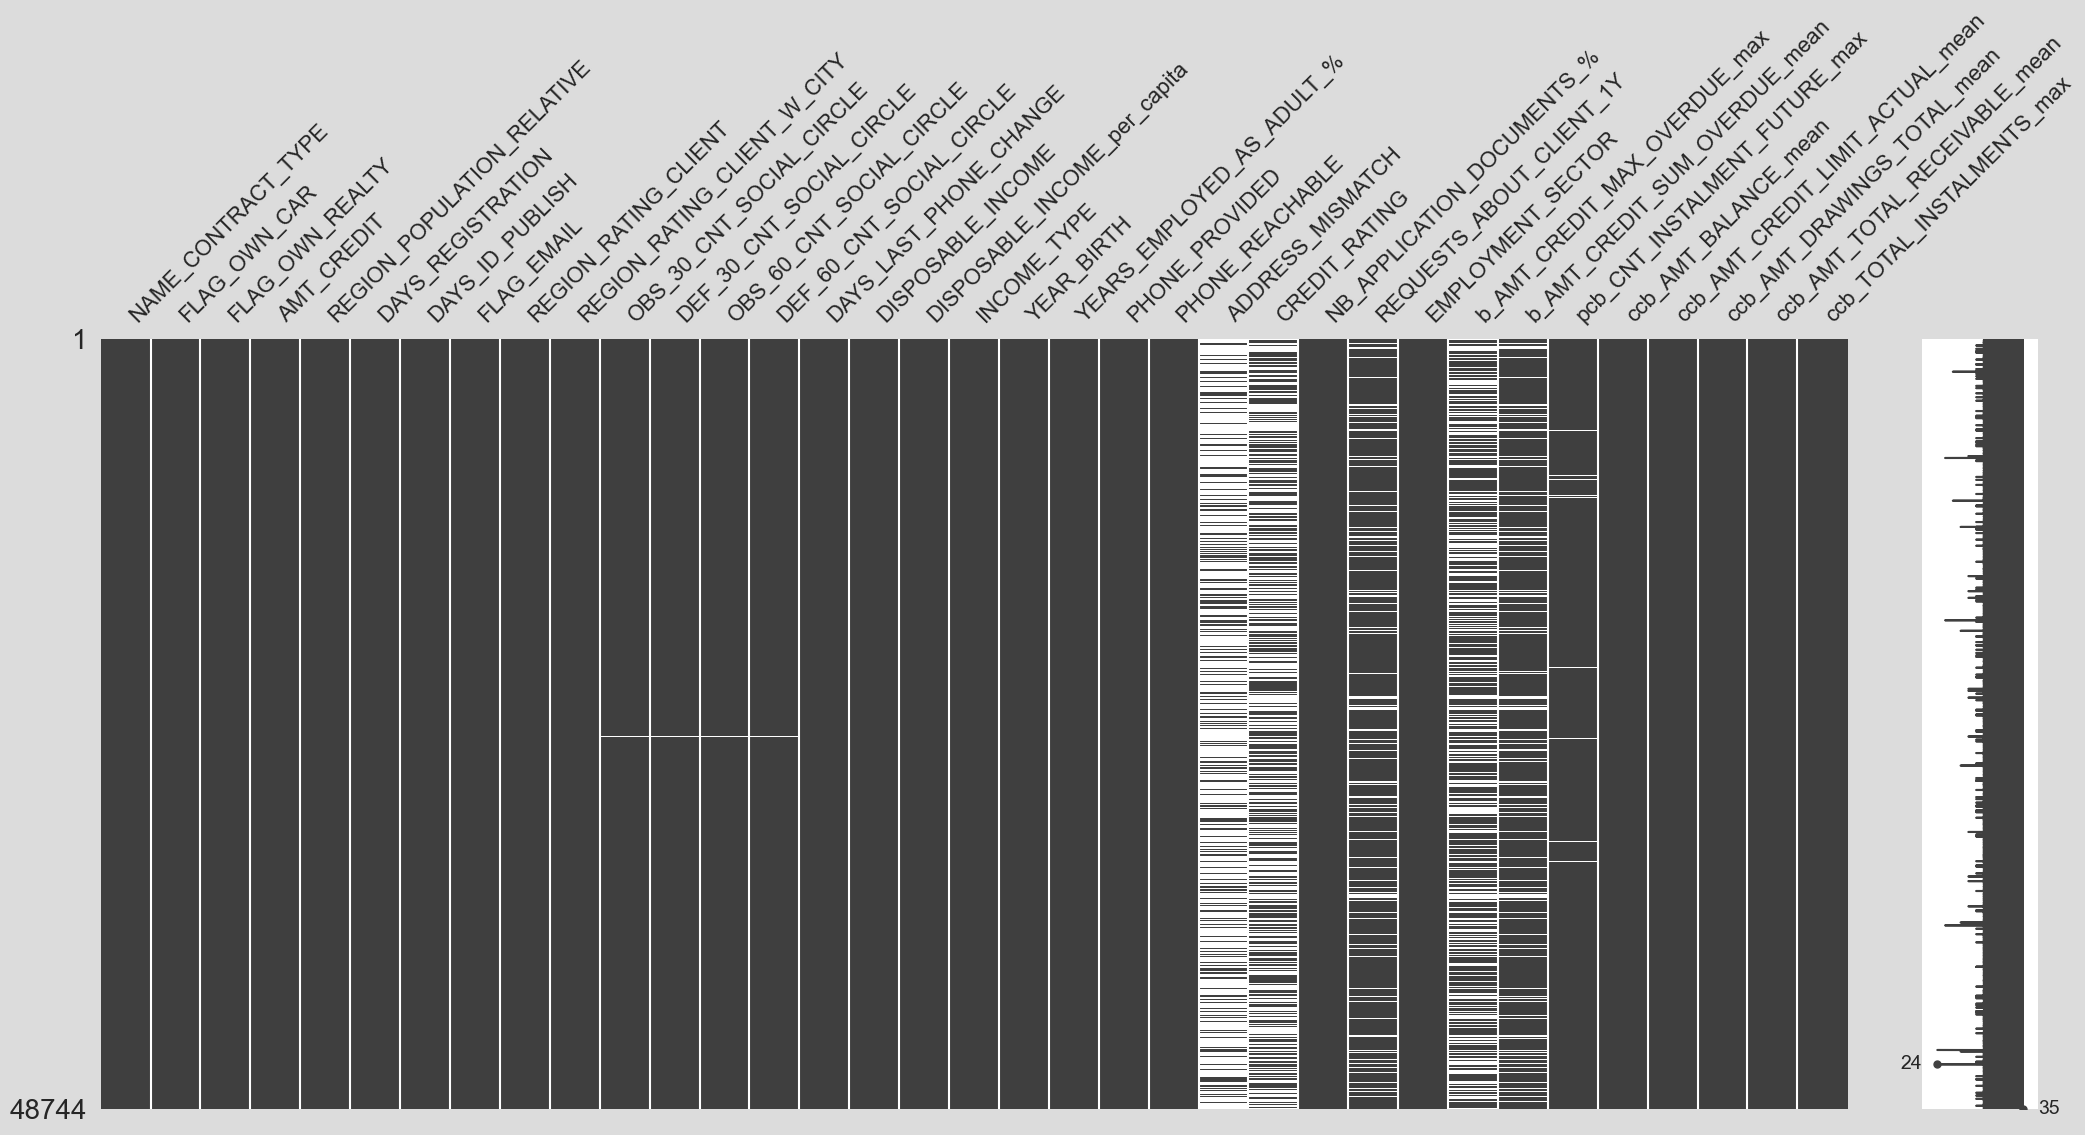

In [50]:
msno.matrix(test_data.iloc[:,:35])

<Axes: >

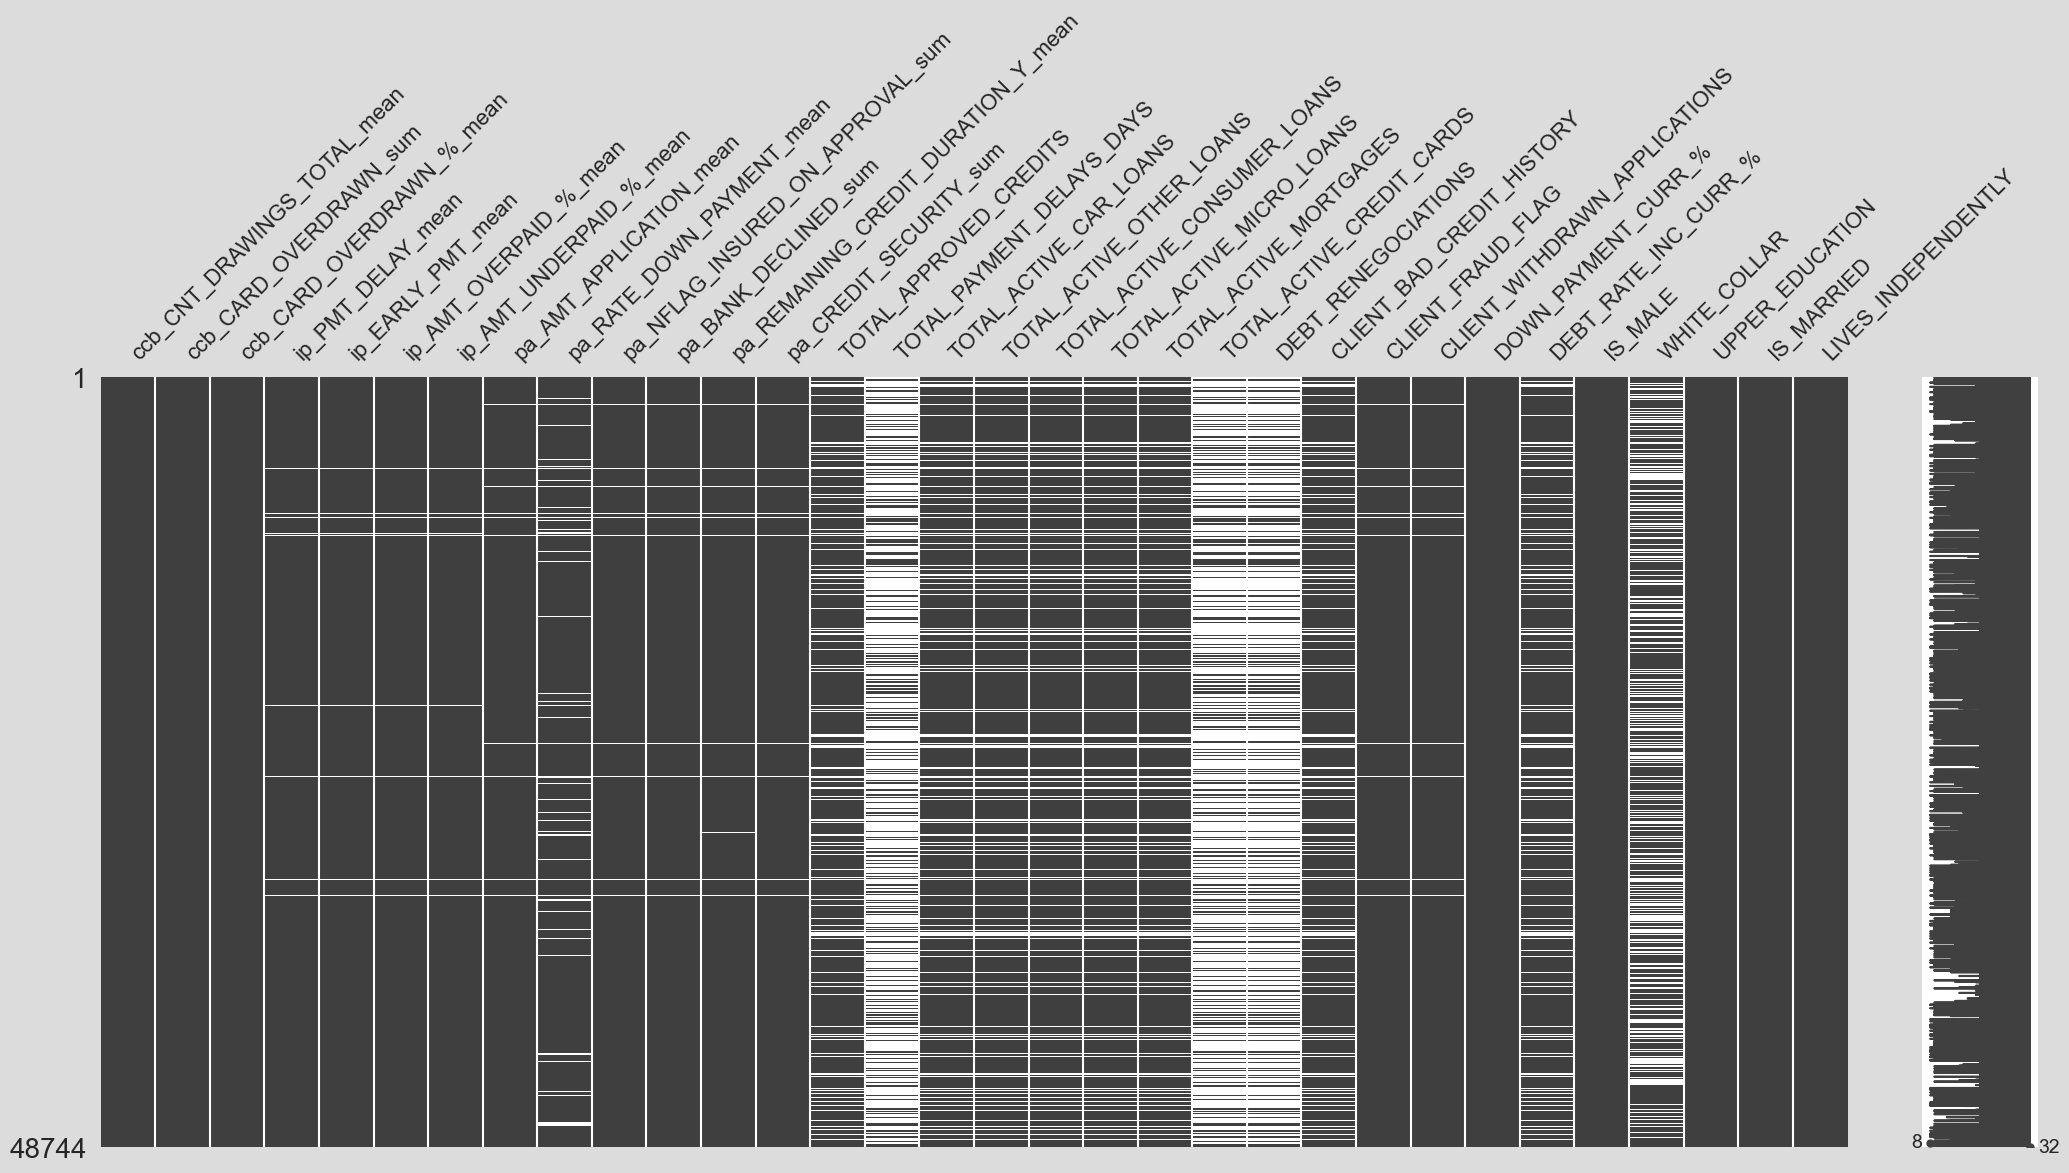

In [51]:
msno.matrix(test_data.iloc[:,35:70])

### 1.2.2 - Outliers

In [52]:
# Replace inf and -inf with NaN
test_data.replace([np.inf, -np.inf], np.nan, inplace=True)

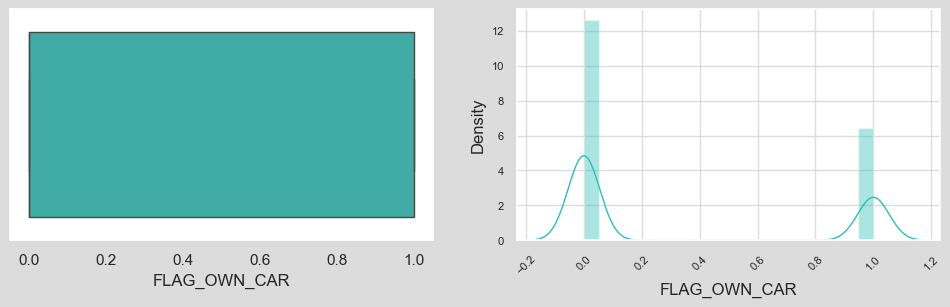

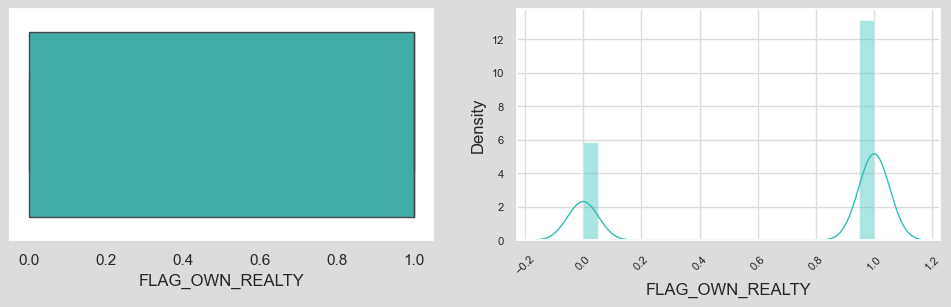

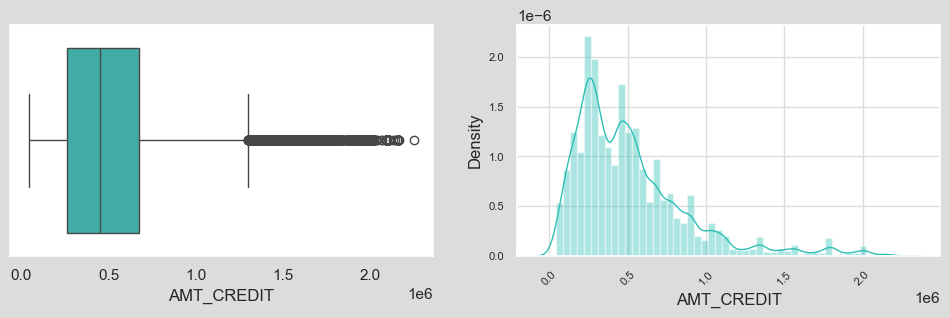

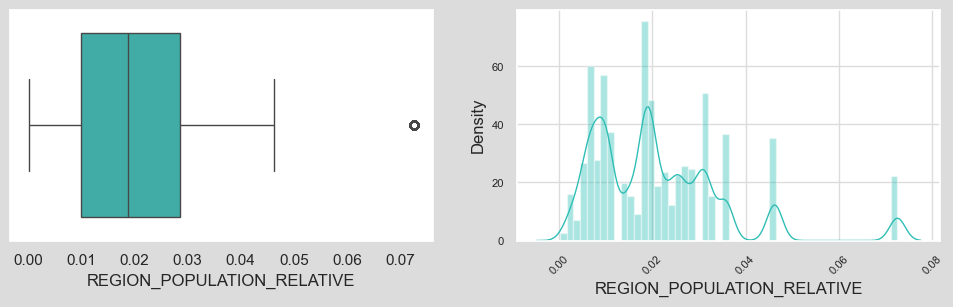

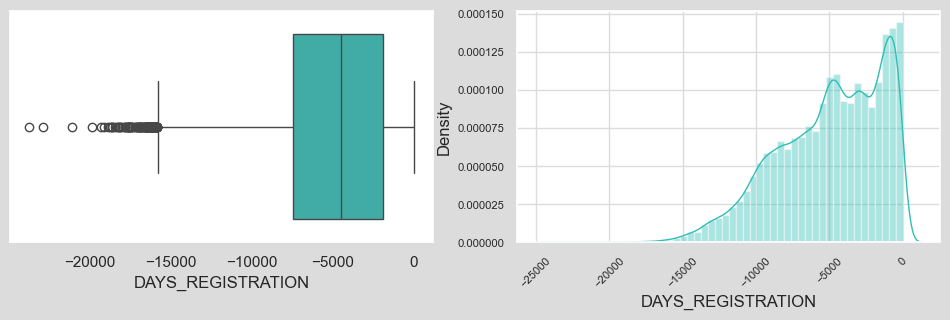

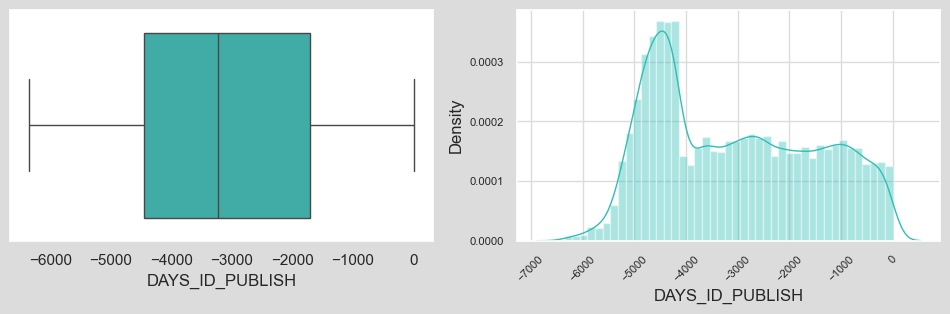

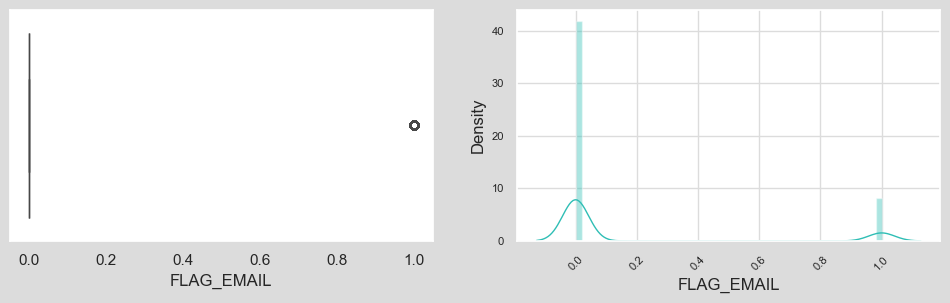

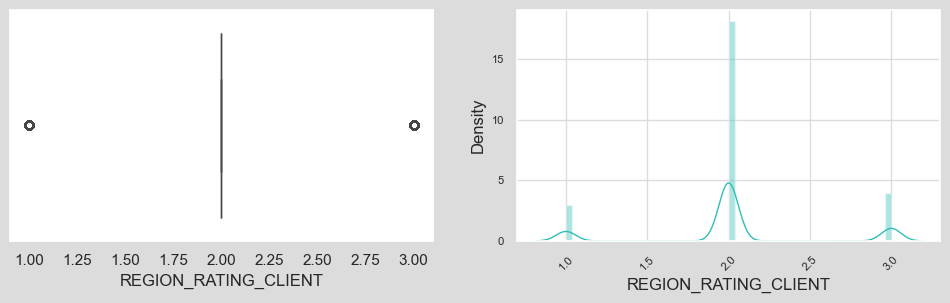

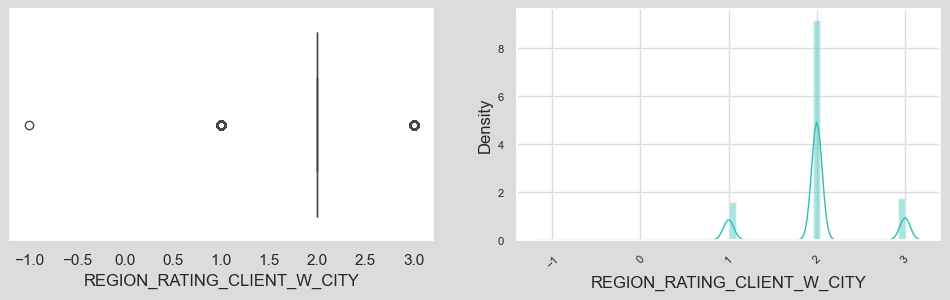

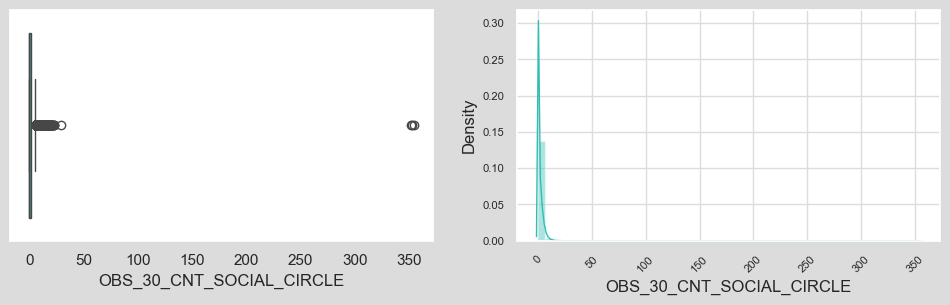

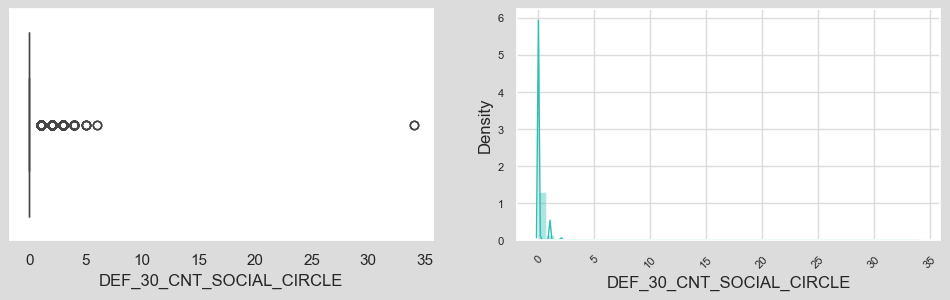

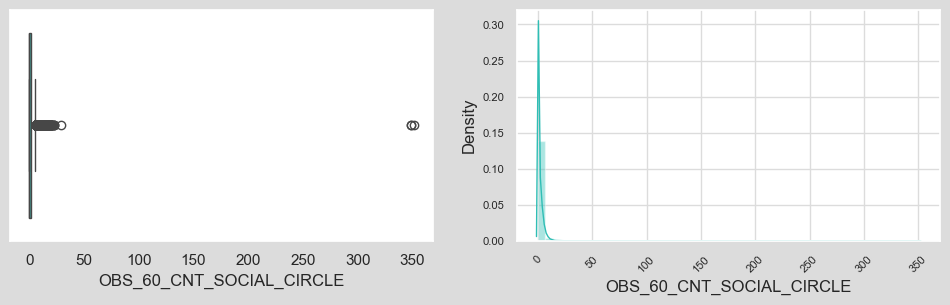

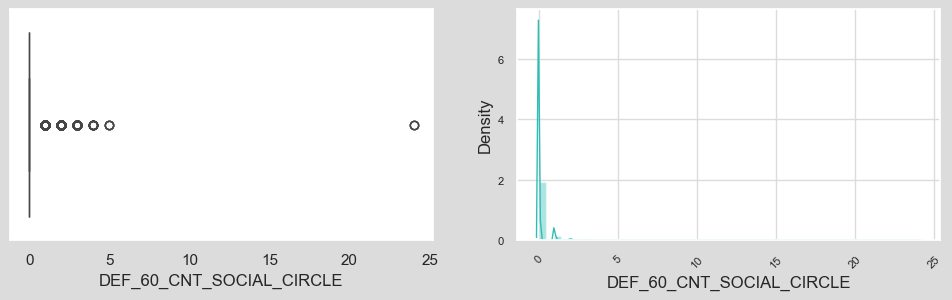

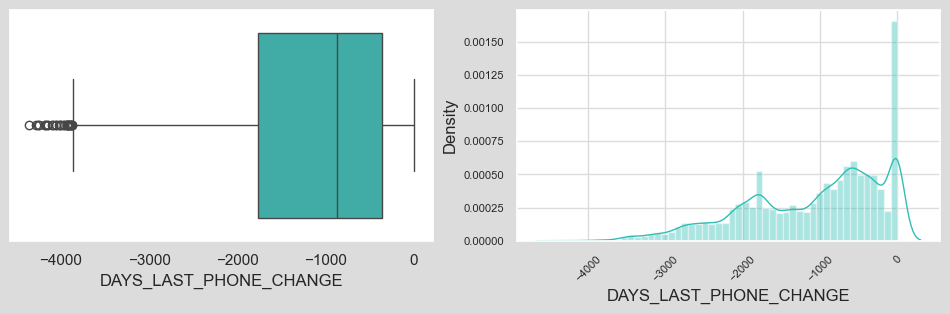

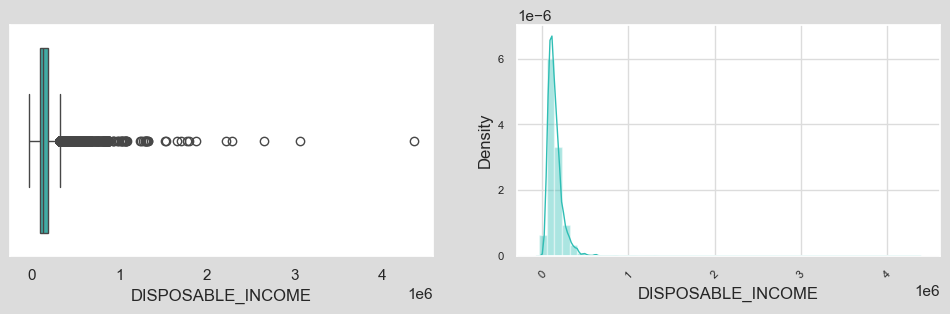

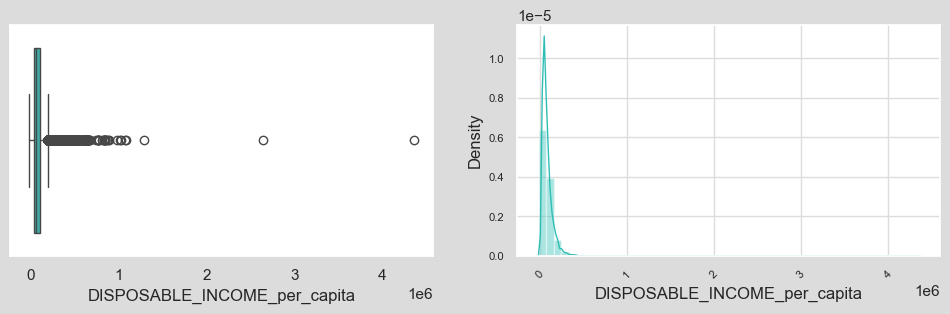

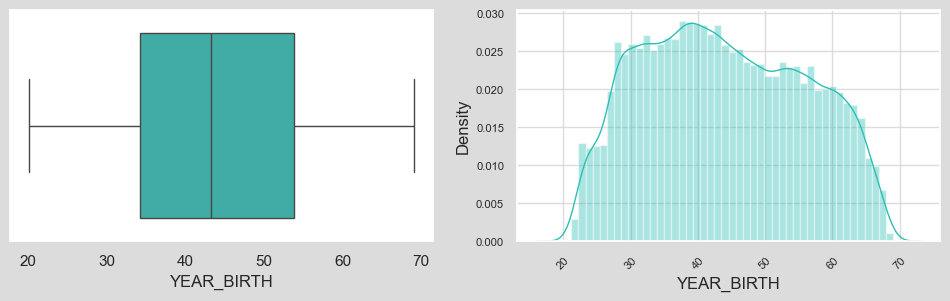

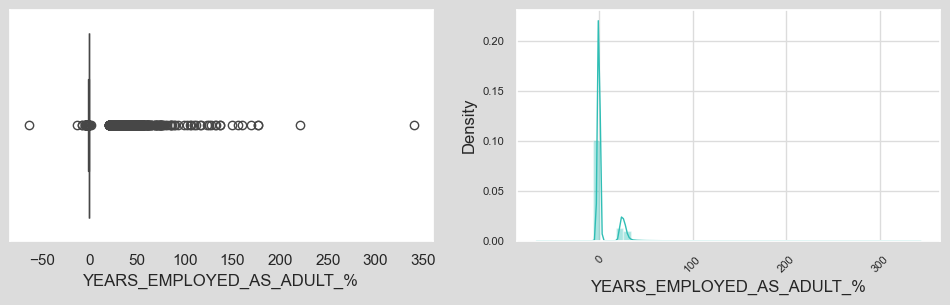

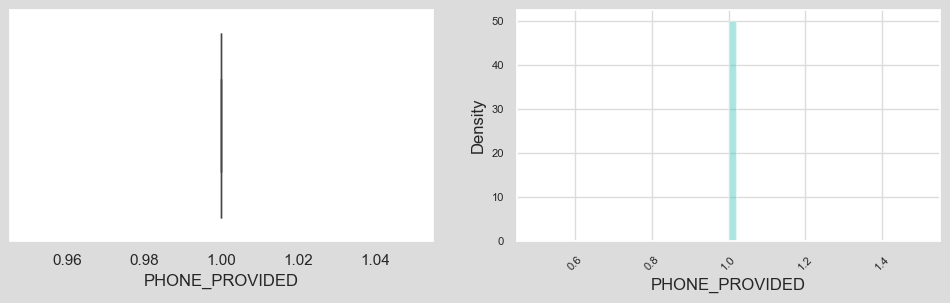

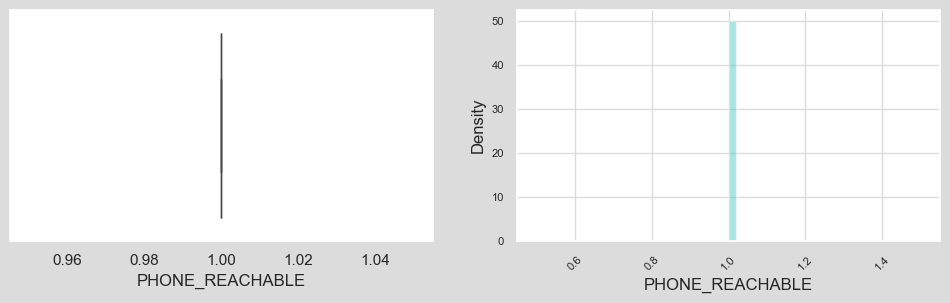

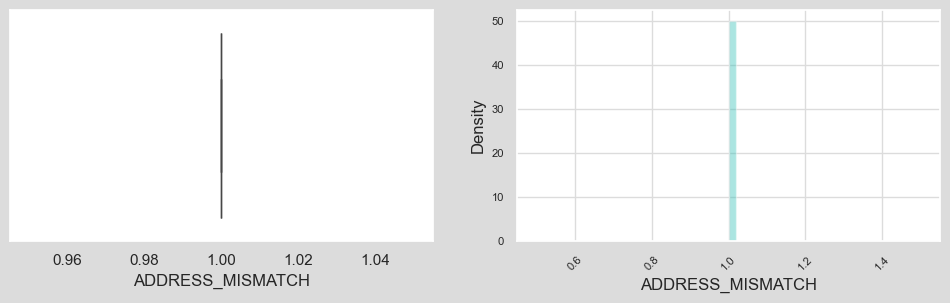

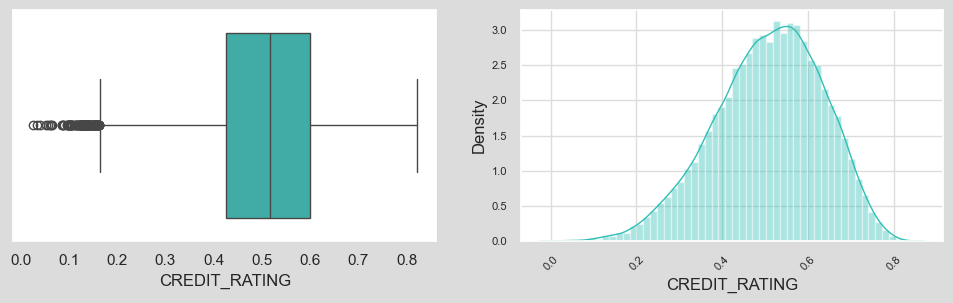

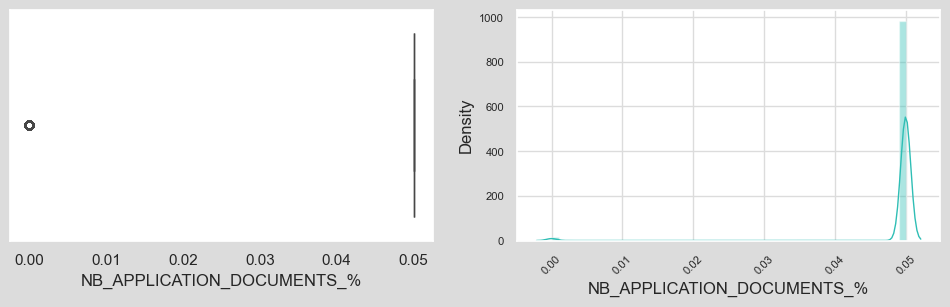

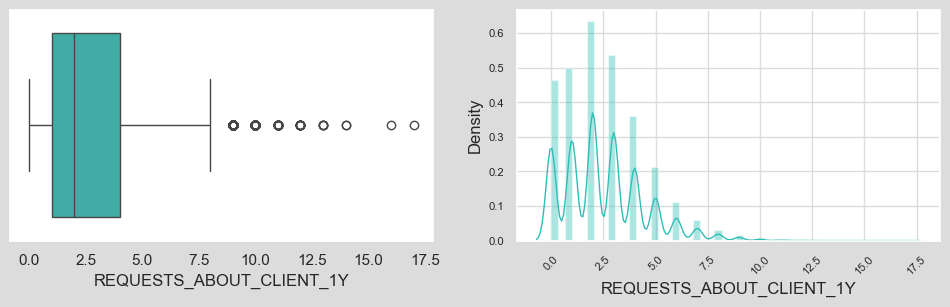

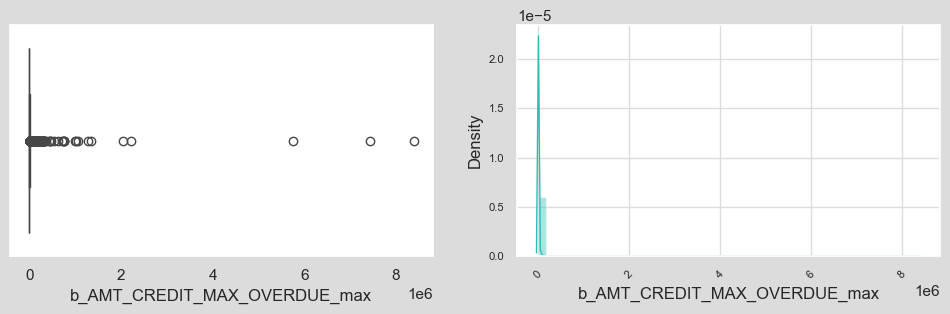

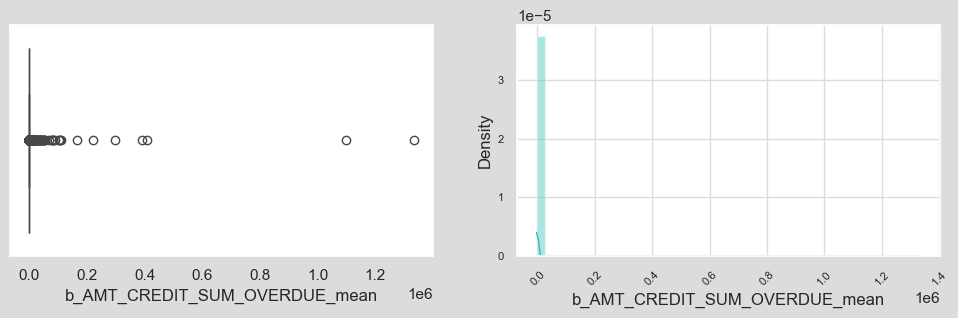

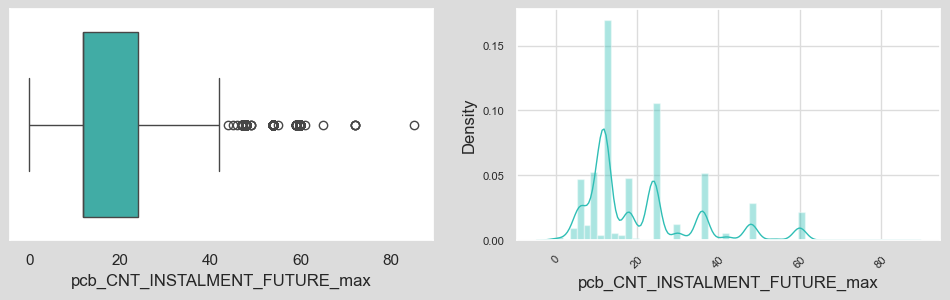

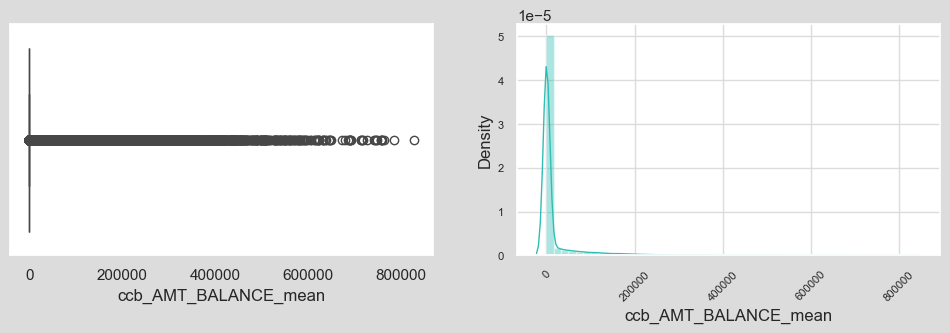

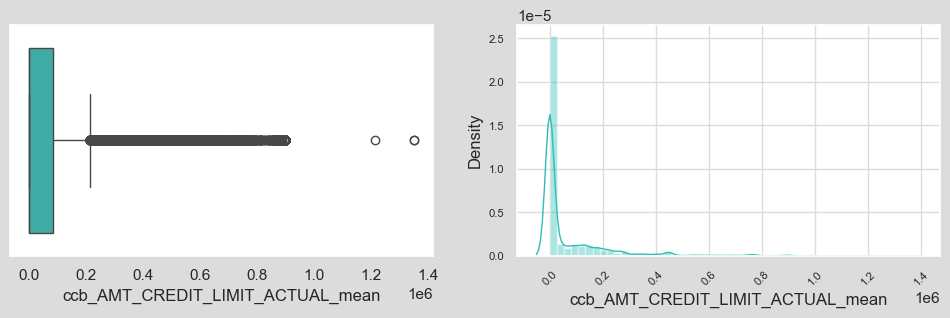

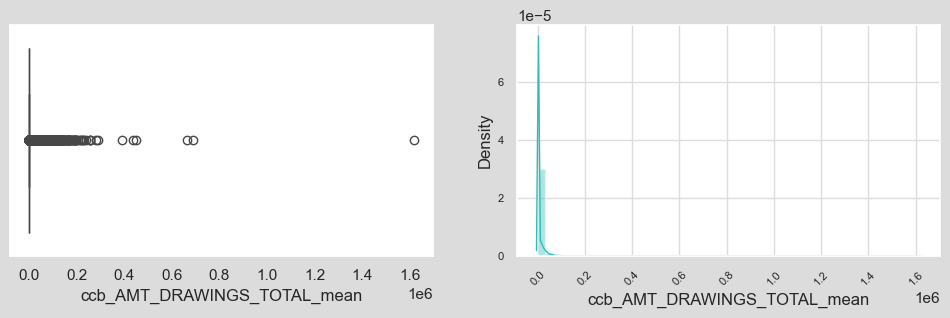

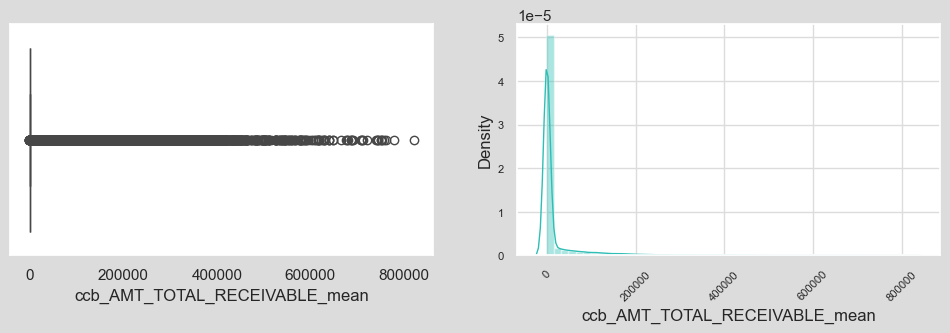

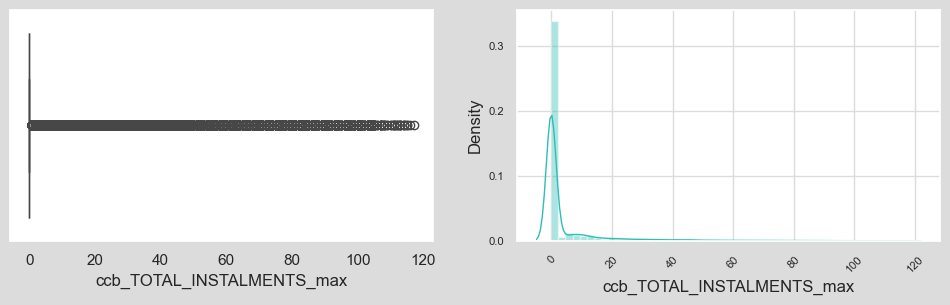

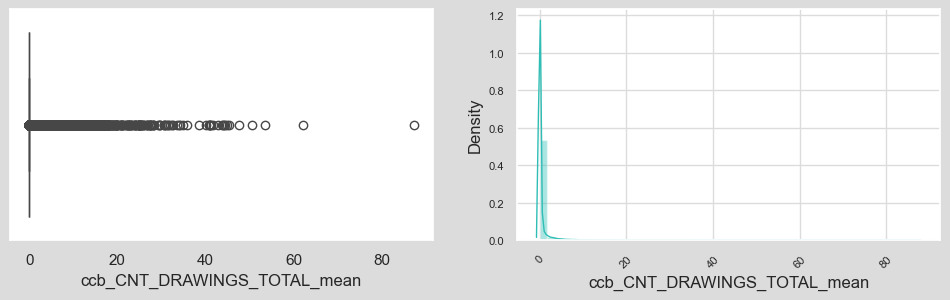

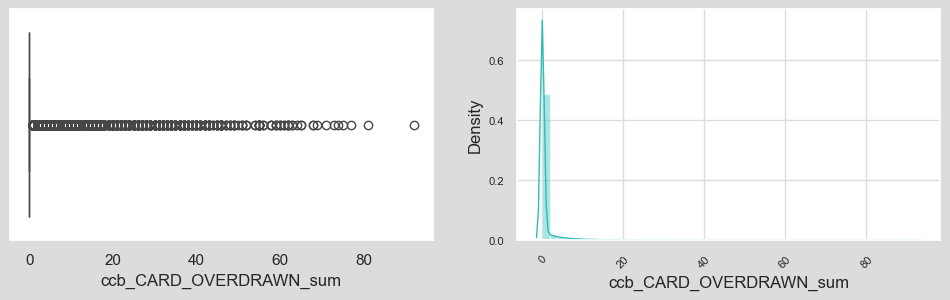

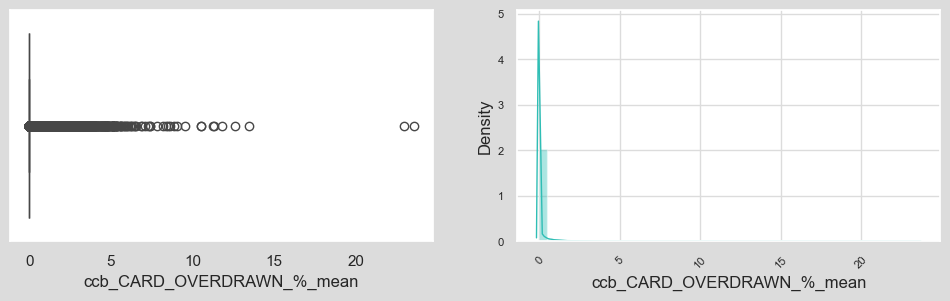

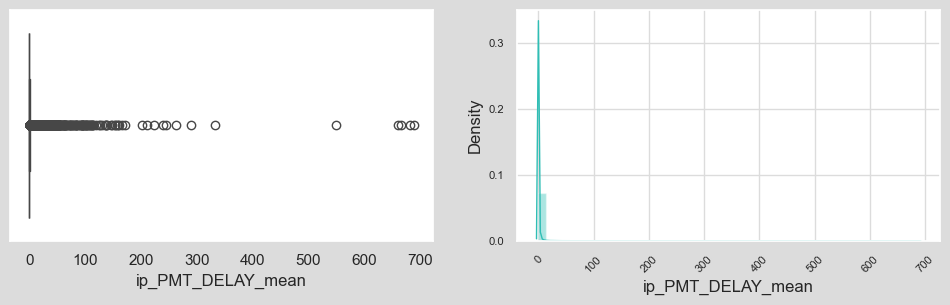

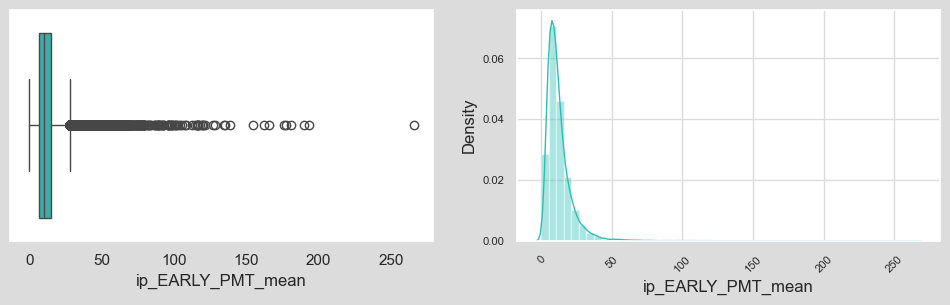

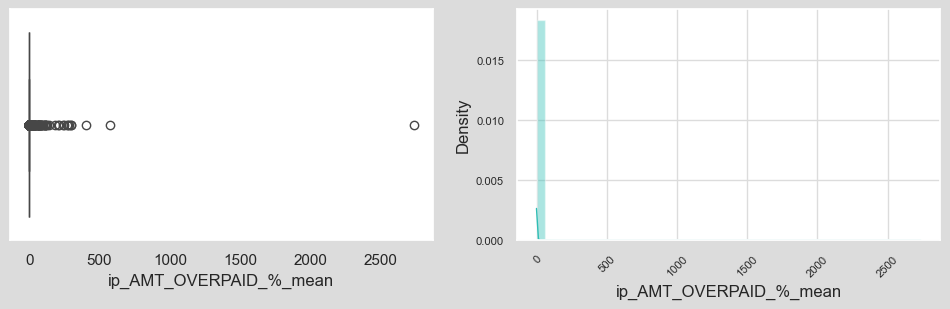

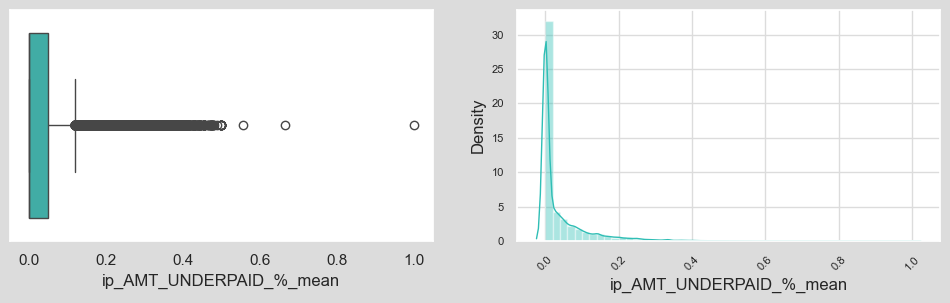

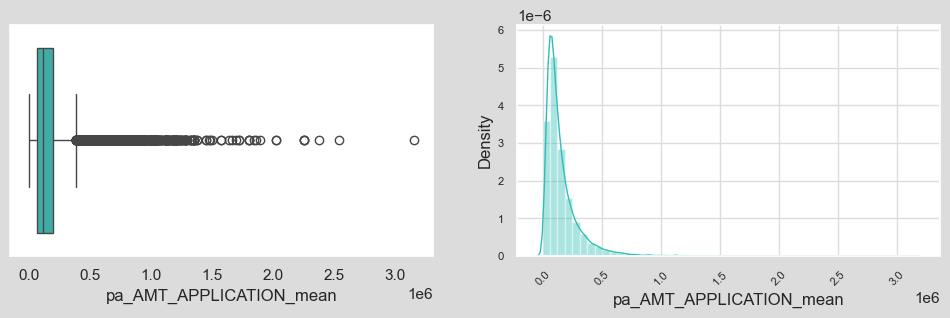

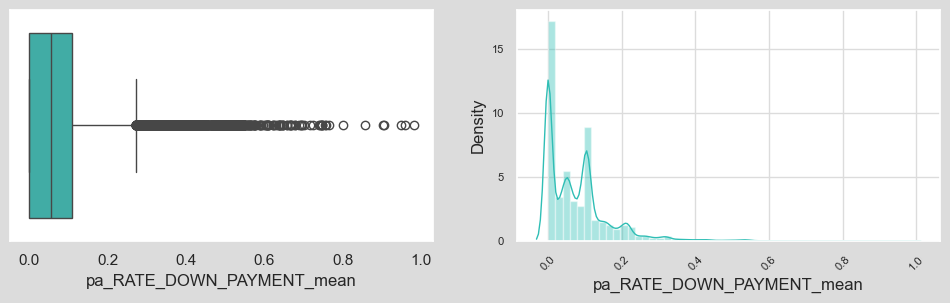

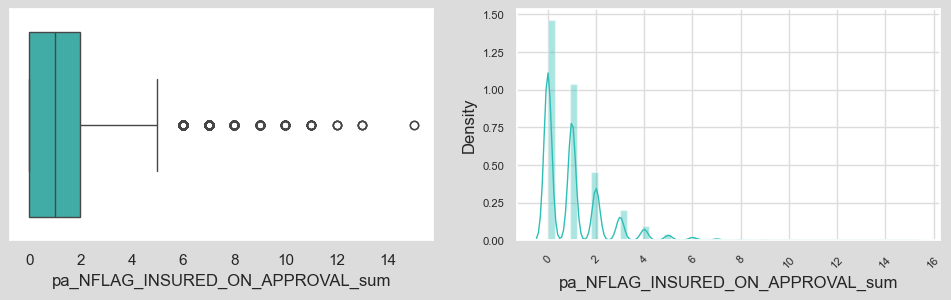

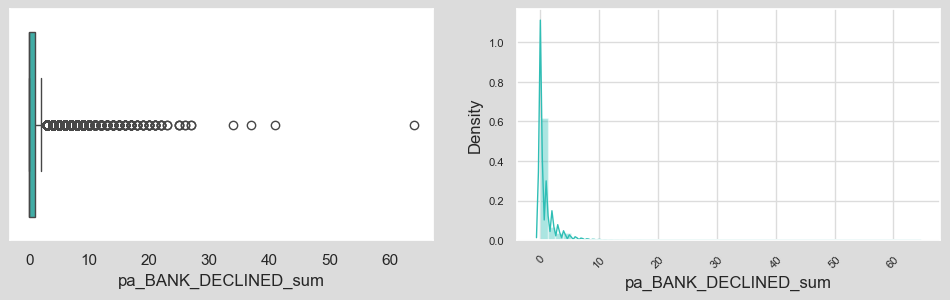

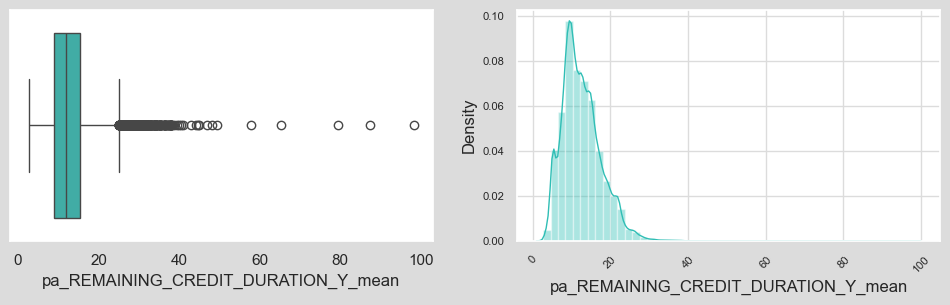

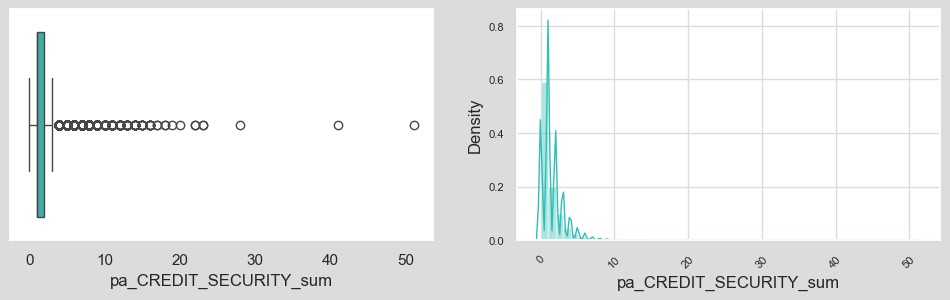

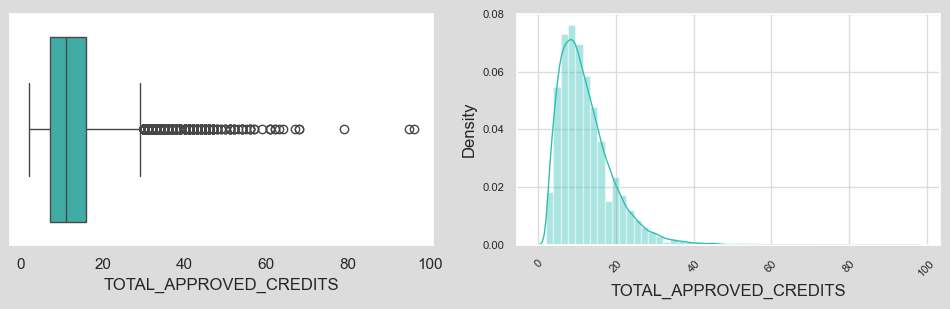

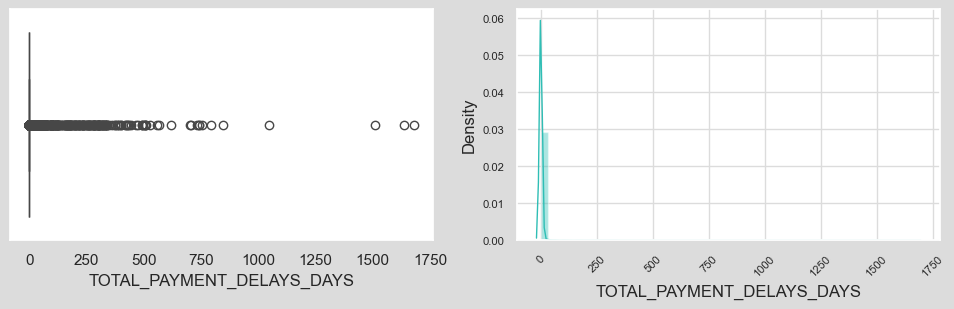

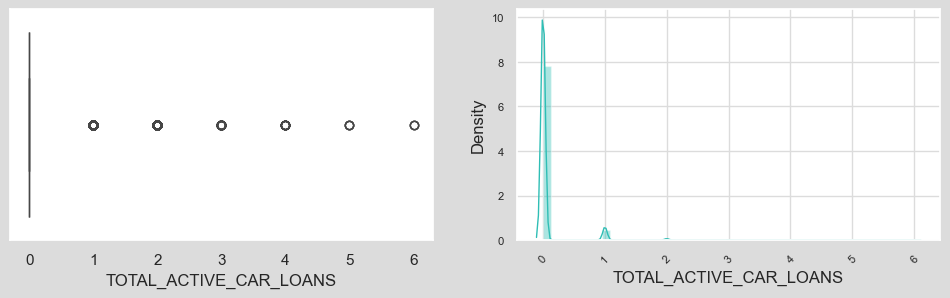

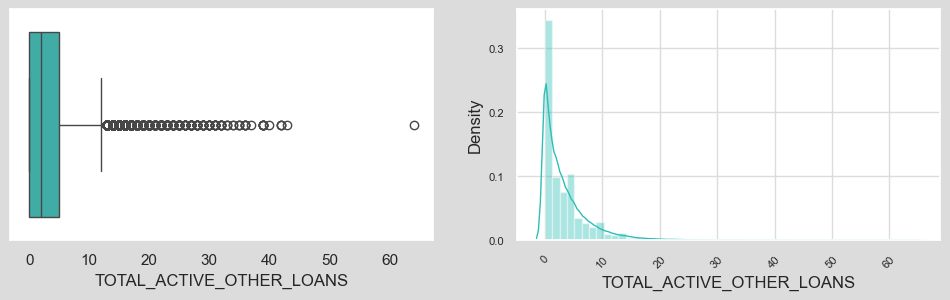

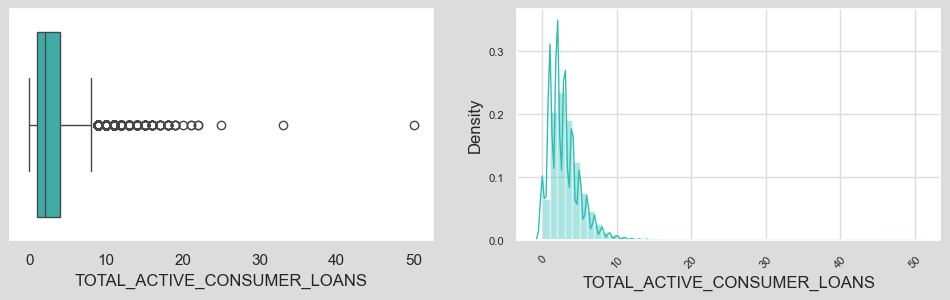

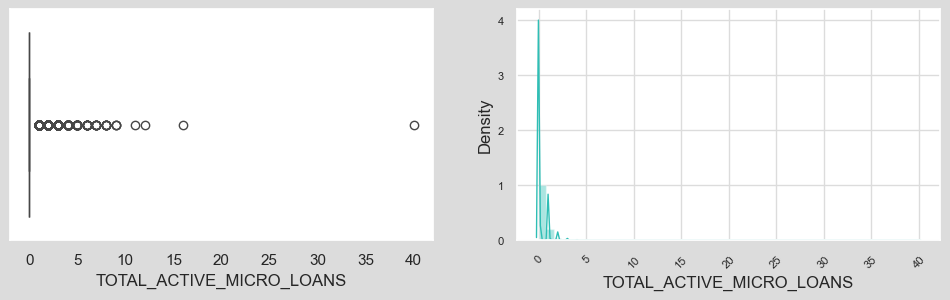

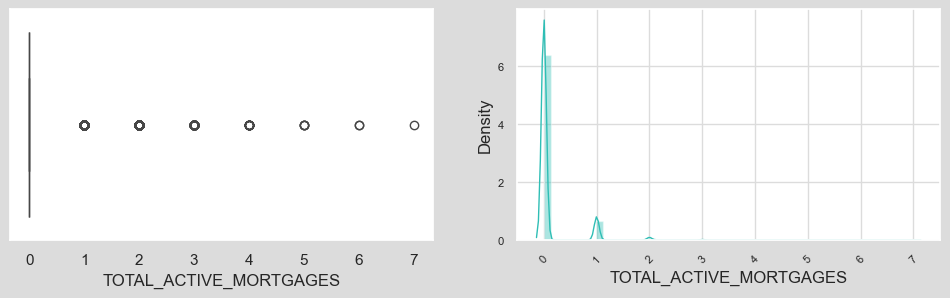

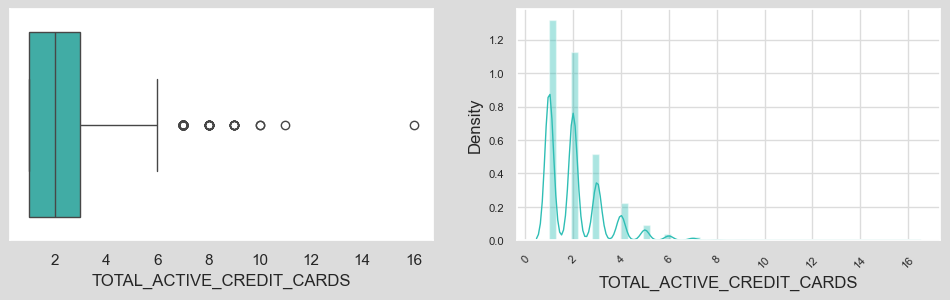

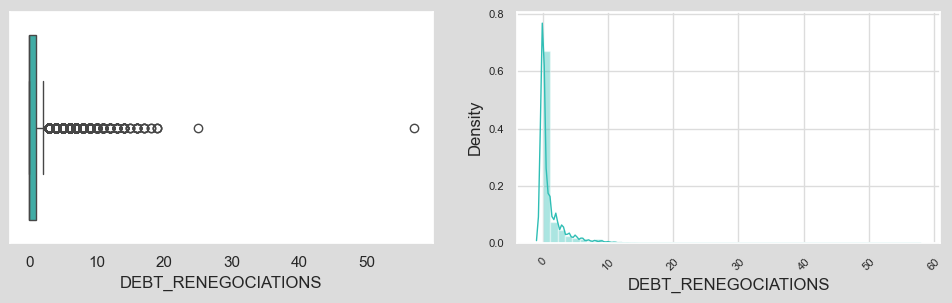

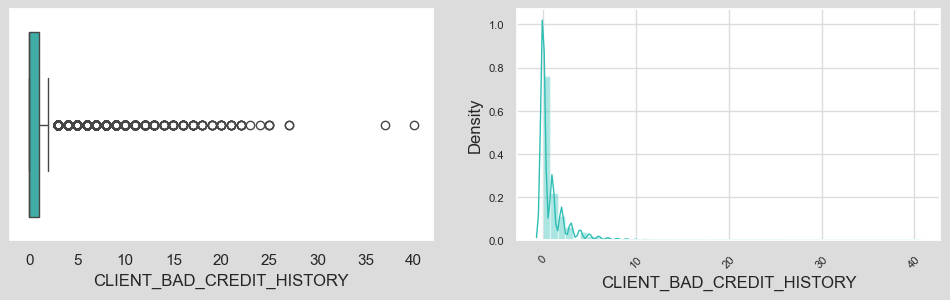

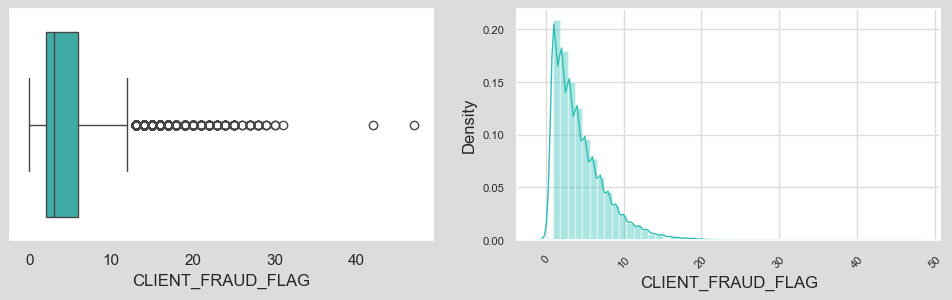

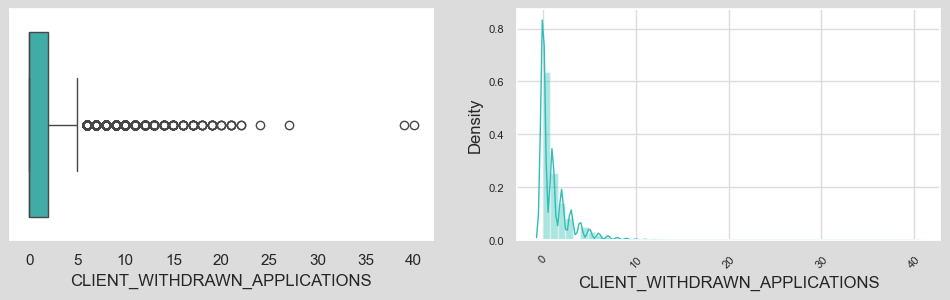

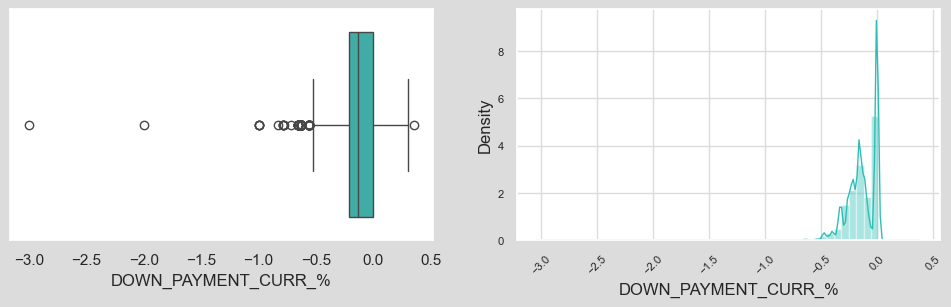

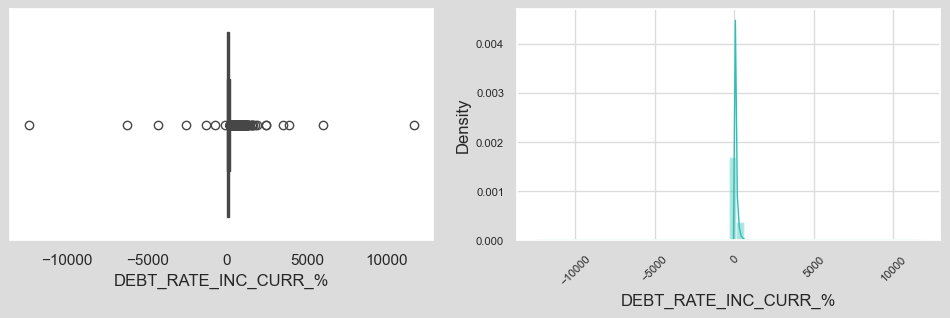

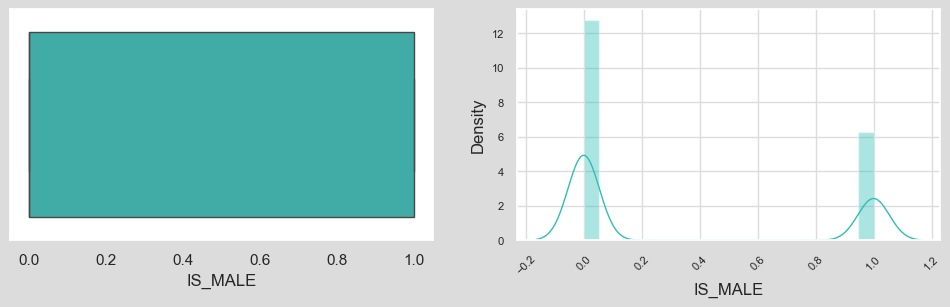

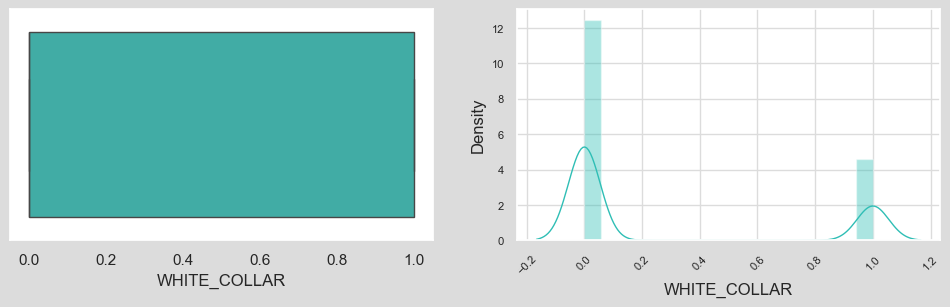

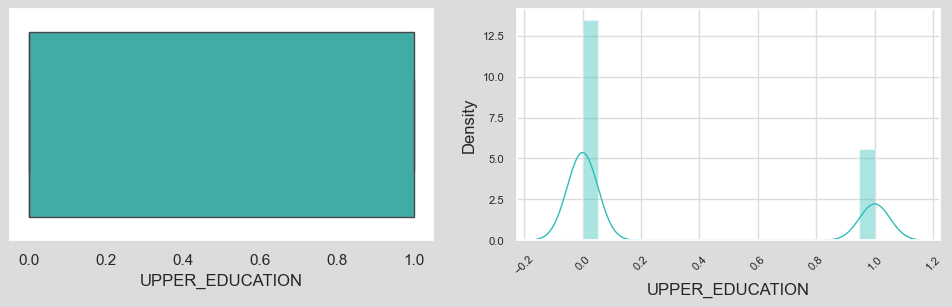

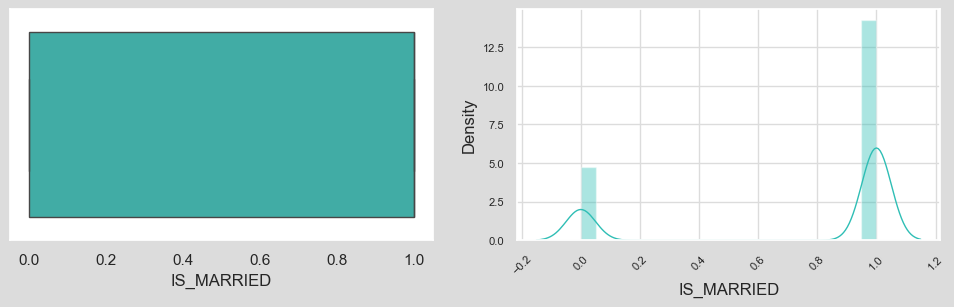

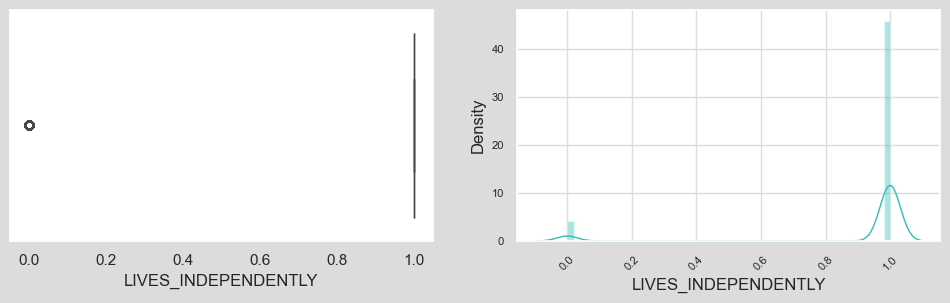

In [53]:
# box_and_hist_plots function is defined in functions.py
fig_num = 1        
for col in test_data.select_dtypes(include=[np.number]).columns:
    box_and_hist_plots(test_data, col, fig_num, leaf)
    fig_num = fig_num + 1

In [54]:
# replace outliers with NaNs where values are obviously aberrations not just atypical
test_data.loc[(test_data['YEARS_EMPLOYED_AS_ADULT_%'] > 1), 'YEARS_EMPLOYED_AS_ADULT_%'] = np.nan
test_data.loc[(test_data['pa_REMAINING_CREDIT_DURATION_Y_mean'] > (70 - test_data['YEAR_BIRTH'])), 'pa_REMAINING_CREDIT_DURATION_Y_mean'] = np.nan 
test_data.loc[(test_data['DEBT_RATE_INC_CURR_%'] < 0), 'DEBT_RATE_INC_CURR_%'] = np.nan
test_data.loc[((-test_data['DAYS_REGISTRATION'] / 365) > (test_data['YEAR_BIRTH'] - 21)), 'DAYS_REGISTRATION'] = np.nan

### 1.2.3 - Imputations

In [55]:
# use iterative imputer to fill NaNs
imputer_test = IterativeImputer(missing_values=np.nan, initial_strategy='median', imputation_order='ascending', skip_complete=True,  verbose=1, random_state=rs)

In [56]:
X_7 = test_data.select_dtypes(include='number')
imputed_7 = imputer_test.fit_transform(X_7)
test_data_ii = pd.DataFrame(imputed_7, columns=X_7.columns).reset_index(drop=True)
X_8 = test_data.select_dtypes(exclude='number').reset_index(drop=True)
test_data_imputed = X_8.join(test_data_ii)
print(test_data_imputed.shape)
print(test_data_imputed.isna().sum().sum(), 'nulls in result dataframe.')
test_data_imputed.sample(5)

[IterativeImputer] Completing matrix with shape (48744, 64)
[IterativeImputer] Change: 621430.9188667601, scaled tolerance: 8381.349 
[IterativeImputer] Change: 248235.62670219544, scaled tolerance: 8381.349 
[IterativeImputer] Change: 56840.84049087858, scaled tolerance: 8381.349 
[IterativeImputer] Change: 134677.72805682448, scaled tolerance: 8381.349 
[IterativeImputer] Change: 69205.07113938159, scaled tolerance: 8381.349 
[IterativeImputer] Change: 37360.815005099714, scaled tolerance: 8381.349 
[IterativeImputer] Change: 22605.48792417477, scaled tolerance: 8381.349 
[IterativeImputer] Change: 16639.02220506925, scaled tolerance: 8381.349 
[IterativeImputer] Change: 14988.34224919959, scaled tolerance: 8381.349 
[IterativeImputer] Change: 13264.585941376772, scaled tolerance: 8381.349 
(48744, 67)
0 nulls in result dataframe.


,NAME_CONTRACT_TYPE,INCOME_TYPE,EMPLOYMENT_SECTOR,FLAG_OWN_CAR,FLAG_OWN_REALTY,AMT_CREDIT,REGION_POPULATION_RELATIVE,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_EMAIL,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,DISPOSABLE_INCOME,DISPOSABLE_INCOME_per_capita,YEAR_BIRTH,YEARS_EMPLOYED_AS_ADULT_%,PHONE_PROVIDED,PHONE_REACHABLE,ADDRESS_MISMATCH,CREDIT_RATING,NB_APPLICATION_DOCUMENTS_%,REQUESTS_ABOUT_CLIENT_1Y,b_AMT_CREDIT_MAX_OVERDUE_max,b_AMT_CREDIT_SUM_OVERDUE_mean,pcb_CNT_INSTALMENT_FUTURE_max,ccb_AMT_BALANCE_mean,ccb_AMT_CREDIT_LIMIT_ACTUAL_mean,ccb_AMT_DRAWINGS_TOTAL_mean,ccb_AMT_TOTAL_RECEIVABLE_mean,ccb_TOTAL_INSTALMENTS_max,ccb_CNT_DRAWINGS_TOTAL_mean,ccb_CARD_OVERDRAWN_sum,ccb_CARD_OVERDRAWN_%_mean,ip_PMT_DELAY_mean,ip_EARLY_PMT_mean,ip_AMT_OVERPAID_%_mean,ip_AMT_UNDERPAID_%_mean,pa_AMT_APPLICATION_mean,pa_RATE_DOWN_PAYMENT_mean,pa_NFLAG_INSURED_ON_APPROVAL_sum,pa_BANK_DECLINED_sum,pa_REMAINING_CREDIT_DURATION_Y_mean,pa_CREDIT_SECURITY_sum,TOTAL_APPROVED_CREDITS,TOTAL_PAYMENT_DELAYS_DAYS,TOTAL_ACTIVE_CAR_LOANS,TOTAL_ACTIVE_OTHER_LOANS,TOTAL_ACTIVE_CONSUMER_LOANS,TOTAL_ACTIVE_MICRO_LOANS,TOTAL_ACTIVE_MORTGAGES,TOTAL_ACTIVE_CREDIT_CARDS,DEBT_RENEGOCIATIONS,CLIENT_BAD_CREDIT_HISTORY,CLIENT_FRAUD_FLAG,CLIENT_WITHDRAWN_APPLICATIONS,DOWN_PAYMENT_CURR_%,DEBT_RATE_INC_CURR_%,IS_MALE,WHITE_COLLAR,UPPER_EDUCATION,IS_MARRIED,LIVES_INDEPENDENTLY
11300,Cash loans,benefits,other,1.0,0.0,601470.0,0.035792,-3577.0,-3696.0,0.0,2.0,2.0,2.0,0.0,2.0,0.0,-135.0,79740.0,39870.00,55.180822,0.071427,1.0,1.0,1.0,0.604288,0.05,6.0,3826.442348,0.0,24.0,0.0,45000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.051948,10.298701,0.000000,0.0,177950.250000,0.146421,3.0,2.0,11.799321,4.0,16.0,0.000000,0.0,10.0,4.0,0.0,0.0,1.000000,0.000000,2.0,12.0,4.0,-0.336600,174.542246,0.0,0.222926,0.0,1.0,1.0
659,Cash loans,benefits,other,0.0,1.0,781920.0,0.002042,-2144.0,-5004.0,0.0,3.0,3.0,0.0,0.0,0.0,0.0,-971.0,124240.5,62120.25,62.756164,0.271955,1.0,1.0,1.0,0.545846,0.05,2.0,0.000000,0.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,23.200000,0.000000,0.0,147150.000000,0.108909,0.0,0.0,9.928607,1.0,15.0,4.486839,0.0,0.0,2.0,1.0,0.0,2.114669,-0.260027,0.0,1.0,0.0,-0.158400,17.701542,0.0,0.363074,0.0,1.0,1.0
34453,Cash loans,fixed_salary,tertiary,0.0,0.0,431280.0,0.010966,-4783.0,-4783.0,1.0,2.0,2.0,0.0,0.0,0.0,0.0,-1634.0,90351.0,45175.50,40.726027,-0.273889,1.0,1.0,1.0,0.553084,0.05,4.0,0.000000,0.0,24.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,97.904762,0.000000,0.0,46114.875000,0.000000,0.0,0.0,14.216666,1.0,6.0,2.405776,0.0,2.0,2.0,0.0,0.0,1.221261,-1.787569,0.0,4.0,2.0,-0.198000,29.538083,0.0,0.000000,0.0,1.0,1.0
35458,Cash loans,commission,tertiary,1.0,1.0,512995.5,0.011657,-5400.0,-2685.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,222822.0,111411.00,59.126027,-0.019187,1.0,1.0,1.0,0.553738,0.05,3.0,0.000000,0.0,12.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.045455,9.272727,0.000000,0.0,565809.428571,0.050954,0.0,1.0,14.093475,2.0,16.0,1.390147,0.0,3.0,8.0,0.0,0.0,2.231454,0.036322,1.0,6.0,2.0,-0.128703,8.923910,1.0,1.000000,1.0,1.0,1.0
47250,Cash loans,fixed_salary,tertiary,0.0,1.0,1024740.0,0.003122,-2802.0,-4201.0,0.0,3.0,3.0,1.0,0.0,1.0,0.0,-847.0,113953.5,113953.50,56.613699,-0.104854,1.0,1.0,1.0,0.566473,0.05,5.0,0.000000,0.0,36.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,24.135135,0.489524,0.0,421805.454545,0.000000,1.0,3.0,18.604117,2.0,10.0,1.719515,0.0,9.0,3.0,0.0,0.0,0.987289,-0.355524,3.0,8.0,5.0,-0.138600,293.186147,0.0,0.360307,0.0,0.0,1.0


In [57]:
# typecasting
test_data_imputed[['IS_MALE','FLAG_OWN_CAR','FLAG_OWN_REALTY','DAYS_REGISTRATION','DAYS_ID_PUBLISH','FLAG_EMAIL','REGION_RATING_CLIENT','REGION_RATING_CLIENT_W_CITY',
'OBS_30_CNT_SOCIAL_CIRCLE','DEF_30_CNT_SOCIAL_CIRCLE','OBS_60_CNT_SOCIAL_CIRCLE','DEF_60_CNT_SOCIAL_CIRCLE','DAYS_LAST_PHONE_CHANGE', 'YEAR_BIRTH',
                 'WHITE_COLLAR','UPPER_EDUCATION',
'IS_MARRIED','LIVES_INDEPENDENTLY','PHONE_PROVIDED','PHONE_REACHABLE','ADDRESS_MISMATCH','REQUESTS_ABOUT_CLIENT_1Y','pcb_CNT_INSTALMENT_FUTURE_max',
'ccb_TOTAL_INSTALMENTS_max','pa_NFLAG_INSURED_ON_APPROVAL_sum','pa_BANK_DECLINED_sum','pa_CREDIT_SECURITY_sum','TOTAL_APPROVED_CREDITS','TOTAL_ACTIVE_CAR_LOANS',
'TOTAL_ACTIVE_OTHER_LOANS','TOTAL_ACTIVE_CONSUMER_LOANS','TOTAL_ACTIVE_MICRO_LOANS','TOTAL_ACTIVE_MORTGAGES','TOTAL_ACTIVE_CREDIT_CARDS','DEBT_RENEGOCIATIONS',
'CLIENT_BAD_CREDIT_HISTORY','CLIENT_FRAUD_FLAG','CLIENT_WITHDRAWN_APPLICATIONS']] = test_data_imputed[['IS_MALE','FLAG_OWN_CAR','FLAG_OWN_REALTY','DAYS_REGISTRATION',
'DAYS_ID_PUBLISH','FLAG_EMAIL','REGION_RATING_CLIENT','REGION_RATING_CLIENT_W_CITY','OBS_30_CNT_SOCIAL_CIRCLE','DEF_30_CNT_SOCIAL_CIRCLE','OBS_60_CNT_SOCIAL_CIRCLE',
'DEF_60_CNT_SOCIAL_CIRCLE','DAYS_LAST_PHONE_CHANGE', 'YEAR_BIRTH', 'WHITE_COLLAR','UPPER_EDUCATION','IS_MARRIED','LIVES_INDEPENDENTLY','PHONE_PROVIDED','PHONE_REACHABLE',
'ADDRESS_MISMATCH','REQUESTS_ABOUT_CLIENT_1Y','pcb_CNT_INSTALMENT_FUTURE_max','ccb_TOTAL_INSTALMENTS_max','pa_NFLAG_INSURED_ON_APPROVAL_sum',
'pa_BANK_DECLINED_sum','pa_CREDIT_SECURITY_sum','TOTAL_APPROVED_CREDITS','TOTAL_ACTIVE_CAR_LOANS','TOTAL_ACTIVE_OTHER_LOANS','TOTAL_ACTIVE_CONSUMER_LOANS',
'TOTAL_ACTIVE_MICRO_LOANS','TOTAL_ACTIVE_MORTGAGES','TOTAL_ACTIVE_CREDIT_CARDS','DEBT_RENEGOCIATIONS','CLIENT_BAD_CREDIT_HISTORY','CLIENT_FRAUD_FLAG',
'CLIENT_WITHDRAWN_APPLICATIONS']].astype('int32')

In [58]:
test_data_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48744 entries, 0 to 48743
Data columns (total 67 columns):
 #   Column                               Non-Null Count  Dtype   
---  ------                               --------------  -----   
 0   NAME_CONTRACT_TYPE                   48744 non-null  category
 1   INCOME_TYPE                          48744 non-null  category
 2   EMPLOYMENT_SECTOR                    48744 non-null  category
 3   FLAG_OWN_CAR                         48744 non-null  int32   
 4   FLAG_OWN_REALTY                      48744 non-null  int32   
 5   AMT_CREDIT                           48744 non-null  float64 
 6   REGION_POPULATION_RELATIVE           48744 non-null  float64 
 7   DAYS_REGISTRATION                    48744 non-null  int32   
 8   DAYS_ID_PUBLISH                      48744 non-null  int32   
 9   FLAG_EMAIL                           48744 non-null  int32   
 10  REGION_RATING_CLIENT                 48744 non-null  int32   
 11  REGION_RATING_C

### 1.2.4 - Remove highly correlated features

In [59]:
test_data_imputed = test_data_imputed.drop(labels=cols_to_drop, axis=1)

In [60]:
print(test_data_imputed.shape)

(48744, 56)


In [23]:
test_data_imputed.to_csv('test_data_final.csv')